# Lab 2 — Đặc trưng tiếng nói và nhận dạng bằng DTW

**Học phần:** CSE457 — Xử lý âm thanh và tiếng nói  
**Sinh viên:** Nguyễn Thị Nam Phương — **MSSV:** 2351260682 — **Lớp:** 65TTNT

**Mục tiêu:** nhận dạng từ đơn bằng MFCC và DTW tự cài đặt; trả về nhãn dự đoán cùng khoảng cách DTW.

## Phase 1 — Chuẩn bị môi trường và cấu hình

Chạy các ô thiết lập theo thứ tự bằng **Restart Kernel → Run All**. Chọn kernel **Lab 2 (Python 3.11)**, tương ứng `.venv-lab2/Scripts/python.exe`. Các phần A–G bên dưới là khung để triển khai ở các phase tiếp theo, chưa có kết quả thực nghiệm.

Trong terminal tại thư mục dự án, nếu cần cài môi trường:
```powershell
.\.venv-lab2\Scripts\python.exe -m pip install -r requirements.txt
```

DTW trong phần E phải tự cài đặt. MFCC và Δ có thể dùng thư viện. Không dùng ASR trực tuyến hoặc mô hình end-to-end.

In [1]:
import sys
import platform
from pathlib import Path
from importlib.metadata import version

import numpy as np
import scipy
from scipy.signal import lfilter
import matplotlib
import matplotlib.pyplot as plt
import librosa
import soundfile as sf
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from IPython.display import Audio, Markdown, display

packages = ["numpy", "scipy", "matplotlib", "librosa", "soundfile", "scikit-learn", "ipykernel"]
rows = "\n".join(f"| {name} | {version(name)} |" for name in packages)
display(Markdown(f"**Python:** {platform.python_version()}  \n**Executable:** `{sys.executable}`\n\n| Thư viện | Phiên bản |\n|---|---|\n{rows}"))
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "font.size": 11})

**Python:** 3.11.9  
**Executable:** `D:\TLU\Lab01_2351260682_NguyenThiNamPhuong\.venv-lab2\Scripts\python.exe`

| Thư viện | Phiên bản |
|---|---|
| numpy | 2.4.6 |
| scipy | 1.17.1 |
| matplotlib | 3.11.2 |
| librosa | 0.11.0 |
| soundfile | 0.14.0 |
| scikit-learn | 1.7.2 |
| ipykernel | 7.3.0 |

### Cấu hình chung

Mọi template và test phải sử dụng cùng cấu hình. Ở các thí nghiệm E1–E2, chỉ thay đổi yếu tố đang khảo sát và ghi lại cấu hình tương ứng.

`TOP_DB=35` là tham khảo cho baseline trim thư viện. Endpoint tự cài ở phần C dùng hai ngưỡng tương đối 18/30 dB, ngưỡng nền và `MARGIN_MS=80`; cấu hình chi tiết được báo cáo tại phần C. CMN được bật theo baseline. Thứ tự pipeline sẽ là đọc/chuẩn hóa → endpoint → tiền nhấn → MFCC → CMN → DTW.

In [2]:
FS = 16_000
FRAME_MS = 25
HOP_MS = 10
WIN = round(FS * FRAME_MS / 1000)
HOP = round(FS * HOP_MS / 1000)
WINDOW = "hamming"
ALPHA = 0.97
NFFT = 512
N_MELS = 24
N_MFCC = 13
CENTER = False
USE_CMN = True
TOP_DB = 35
MARGIN_MS = 80
EPS = 1e-9
LOCAL_DISTANCE = "euclidean"
DTW_NORMALIZATION = "total_cost / path_length"
WAV_SUBTYPE = "PCM_16"

LABELS = ["khong", "mot", "hai", "ba", "bon"]
LABEL_NAMES = dict(zip(LABELS, ["không", "một", "hai", "ba", "bốn"]))
MIN_RECORDINGS_PER_LABEL = 5
N_TEMPLATES_PER_LABEL = 3

parameters = {
    "Sampling rate (Hz)": FS,
    "Frame (ms / mẫu)": f"{FRAME_MS} / {WIN}",
    "Hop (ms / mẫu)": f"{HOP_MS} / {HOP}",
    "Window": WINDOW,
    "Pre-emphasis alpha": ALPHA,
    "NFFT": NFFT,
    "Mel filters": N_MELS,
    "MFCC / frame": N_MFCC,
    "Center": CENTER,
    "CMN": USE_CMN,
    "Endpoint top_db (ban đầu)": TOP_DB,
    "Endpoint margin (ms, ban đầu)": MARGIN_MS,
    "Local distance": LOCAL_DISTANCE,
    "DTW normalization": DTW_NORMALIZATION,
}
rows = "\n".join(f"| {name} | {value} |" for name, value in parameters.items())
display(Markdown(f"| Tham số | Giá trị |\n|---|---|\n{rows}"))

| Tham số | Giá trị |
|---|---|
| Sampling rate (Hz) | 16000 |
| Frame (ms / mẫu) | 25 / 400 |
| Hop (ms / mẫu) | 10 / 160 |
| Window | hamming |
| Pre-emphasis alpha | 0.97 |
| NFFT | 512 |
| Mel filters | 24 |
| MFCC / frame | 13 |
| Center | False |
| CMN | True |
| Endpoint top_db (ban đầu) | 35 |
| Endpoint margin (ms, ban đầu) | 80 |
| Local distance | euclidean |
| DTW normalization | total_cost / path_length |

### Đường dẫn và cấu trúc dữ liệu

Notebook được đặt trong thư mục `lab2/` của repo. Hàm dưới đây tìm gốc từ thư mục làm việc hiện tại hoặc thư mục cha, tránh ghi cứng đường dẫn máy cá nhân. Hình Lab 2 lưu trong `figures/`.

Tên bản ghi dự kiến: `dataset/khong/khong_01.wav` ... `khong_05.wav`, tương tự cho các nhãn còn lại. Các thư mục ban đầu rỗng; cần thu âm thật ở Phase 2.

In [3]:
def find_project_root():
    current = Path.cwd().resolve()
    for candidate in (current, current / "lab2", *current.parents):
        if (candidate / "Lab2_2351260682.ipynb").is_file():
            return candidate
    raise FileNotFoundError("Hãy mở notebook hoặc chạy kernel từ thư mục dự án Lab 2.")

PROJECT_ROOT = find_project_root()
DATASET_DIR = PROJECT_ROOT / "dataset"
TRIMMED_DIR = PROJECT_ROOT / "trimmed"
FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_PATH = PROJECT_ROOT / "results.csv"

for directory in (DATASET_DIR, TRIMMED_DIR, FIGURES_DIR, PROJECT_ROOT / "outputs", PROJECT_ROOT / "reports"):
    directory.mkdir(parents=True, exist_ok=True)
for label in LABELS:
    (DATASET_DIR / label).mkdir(exist_ok=True)
    (TRIMMED_DIR / label).mkdir(exist_ok=True)

print("Gốc dự án:", PROJECT_ROOT)
for label in LABELS:
    count = len(list((DATASET_DIR / label).glob("*.wav")))
    print(f"{label:6s} → {LABEL_NAMES[label]:5s}: {count} file WAV")
print("Thư mục hình:", FIGURES_DIR)
print("File kết quả sẽ tạo ở Phase 8:", RESULTS_PATH)

Gốc dự án: D:\TLU\Lab01_2351260682_NguyenThiNamPhuong\lab2
khong  → không: 5 file WAV
mot    → một  : 5 file WAV
hai    → hai  : 5 file WAV
ba     → ba   : 5 file WAV
bon    → bốn  : 5 file WAV
Thư mục hình: D:\TLU\Lab01_2351260682_NguyenThiNamPhuong\lab2\figures
File kết quả sẽ tạo ở Phase 8: D:\TLU\Lab01_2351260682_NguyenThiNamPhuong\lab2\results.csv


In [4]:
assert WIN == 400 and HOP == 160
assert 0 < HOP <= WIN <= NFFT
assert 0 <= ALPHA < 1
assert 0 < N_MFCC <= N_MELS
assert len(LABELS) == len(set(LABELS)) == 5
assert all((DATASET_DIR / label).is_dir() for label in LABELS)
assert all((TRIMMED_DIR / label).is_dir() for label in LABELS)
assert FIGURES_DIR.is_dir()
print("Phase 1: import thư viện, cấu hình và thư mục đã được kiểm tra thành công.")
print("Tiếp tục phần A để kiểm tra dữ liệu ghi âm và split train/test.")

Phase 1: import thư viện, cấu hình và thư mục đã được kiểm tra thành công.
Tiếp tục phần A để kiểm tra dữ liệu ghi âm và split train/test.


## A. Thu dữ liệu và kiểm tra chất lượng — Phase 2

Thu 5 từ **không, một, hai, ba, bốn**, mỗi từ ít nhất **5 lần nói độc lập**. Mỗi file chỉ có một từ, WAV PCM mono 16 kHz, giữ silence khoảng 0,2–0,5 giây đầu/cuối. Giữ vị trí micro và âm lượng tương đối ổn định.

### A1. Thu âm và lưu dữ liệu

Trong terminal PowerShell tại thư mục dự án, chạy server thu âm:
```powershell
.\.venv-lab2\Scripts\python.exe -m http.server 8765 --bind 127.0.0.1
```
Mở Chrome/Edge tại **http://localhost:8765/tools/record_lab2.html**, chọn thư mục **dataset** của dự án, bấm thu, nói từ đang hiển thị, dừng, nghe lại và lưu. Trang tạo file PCM 16-bit mono 16 kHz; không ghi đè file đã có. Ctrl+C trong terminal để dừng server.

Nếu đã có bản ghi riêng, đặt vào thư mục nhãn tương ứng. Đặt tên `khong_01.wav` ... `khong_05.wav`, tương tự cho từ khác. Có thể chuyển đổi bản WAV bằng `convert_recording` dưới đây, giữ file gốc riêng.

File của Lab 1 chưa phải bộ bản ghi từ đơn cho bài này. Không dùng bản sao của cùng một utterance làm các lần thu khác nhau.

In [5]:
import csv
import importlib

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import lab2_data
importlib.reload(lab2_data)
from lab2_data import audit_dataset, dataset_issues, lock_split, write_csv, convert_recording, prepare_mp3_dataset

AUDIT_PATH = PROJECT_ROOT / "outputs/dataset_audit.csv"
SPLIT_PATH = PROJECT_ROOT / "data_split.csv"

# Chỉ gọi khi cần đổi định dạng; file đích phải chưa tồn tại.
# convert_recording(PROJECT_ROOT / "raw" / "khong_01.wav",
#                   DATASET_DIR / "khong" / "khong_01.wav")

def show_table(rows, columns):
    def cell(value):
        return str(value).replace("|", "/").replace("\n", " ")
    header = "| " + " | ".join(columns) + " |"
    divider = "| " + " | ".join("---" for _ in columns) + " |"
    body = ["| " + " | ".join(cell(row.get(key, "")) for key in columns) + " |" for row in rows]
    display(Markdown("\n".join([header, divider, *body])))

### Chuẩn hóa bộ MP3 đã thu

Các bản ghi thực tế được lưu dạng `khong.mp3`, `khong(1).mp3` ... `khong(4).mp3`, tương tự cho các nhãn khác. Ánh xạ thành `khong_01.wav` ... `khong_05.wav` theo số lần ghi.

Hàm chuyển đổi giữ MP3 gốc, không tăng gain và không cắt silence. Bảng `outputs/audio_conversion.csv` lưu nguồn, đích, định dạng và SHA-256. Khi chạy lại, kiểm tra hash và dùng lại WAV đã chuyển; báo lỗi khi nguồn/đích thay đổi, không ghi đè âm thanh.

In [6]:
CONVERSION_ROWS = prepare_mp3_dataset(DATASET_DIR, PROJECT_ROOT / "outputs/audio_conversion.csv")
if CONVERSION_ROWS:
    show_table(CONVERSION_ROWS, ["source", "destination", "source_sample_rate",
                                 "source_channels", "target_sample_rate", "target_subtype"])
    print(f"Đã chuẩn bị/kiểm tra {len(CONVERSION_ROWS)} WAV từ nguồn MP3.")
else:
    print("Không có MP3 theo quy ước tên; sử dụng các WAV hiện có trong dataset.")

| source | destination | source_sample_rate | source_channels | target_sample_rate | target_subtype |
| --- | --- | --- | --- | --- | --- |
| ba/ba.mp3 | ba/ba_01.wav | 48000 | 1 | 16000 | PCM_16 |
| ba/ba(1).mp3 | ba/ba_02.wav | 48000 | 1 | 16000 | PCM_16 |
| ba/ba(2).mp3 | ba/ba_03.wav | 48000 | 1 | 16000 | PCM_16 |
| ba/ba(3).mp3 | ba/ba_04.wav | 48000 | 1 | 16000 | PCM_16 |
| ba/ba(4).mp3 | ba/ba_05.wav | 48000 | 1 | 16000 | PCM_16 |
| bon/bon.mp3 | bon/bon_01.wav | 48000 | 1 | 16000 | PCM_16 |
| bon/bon(1).mp3 | bon/bon_02.wav | 48000 | 1 | 16000 | PCM_16 |
| bon/bon(2).mp3 | bon/bon_03.wav | 48000 | 1 | 16000 | PCM_16 |
| bon/bon(3).mp3 | bon/bon_04.wav | 48000 | 1 | 16000 | PCM_16 |
| bon/bon(4).mp3 | bon/bon_05.wav | 48000 | 1 | 16000 | PCM_16 |
| hai/hai.mp3 | hai/hai_01.wav | 48000 | 1 | 16000 | PCM_16 |
| hai/hai(1).mp3 | hai/hai_02.wav | 48000 | 1 | 16000 | PCM_16 |
| hai/hai(2).mp3 | hai/hai_03.wav | 48000 | 1 | 16000 | PCM_16 |
| hai/hai(3).mp3 | hai/hai_04.wav | 48000 | 1 | 16000 | PCM_16 |
| hai/hai(4).mp3 | hai/hai_05.wav | 48000 | 1 | 16000 | PCM_16 |
| khong/khong.mp3 | khong/khong_01.wav | 48000 | 1 | 16000 | PCM_16 |
| khong/khong(1).mp3 | khong/khong_02.wav | 48000 | 1 | 16000 | PCM_16 |
| khong/khong(2).mp3 | khong/khong_03.wav | 48000 | 1 | 16000 | PCM_16 |
| khong/khong(3).mp3 | khong/khong_04.wav | 48000 | 1 | 16000 | PCM_16 |
| khong/khong(4).mp3 | khong/khong_05.wav | 48000 | 1 | 16000 | PCM_16 |
| mot/mot.mp3 | mot/mot_01.wav | 48000 | 1 | 16000 | PCM_16 |
| mot/mot(1).mp3 | mot/mot_02.wav | 48000 | 1 | 16000 | PCM_16 |
| mot/mot(2).mp3 | mot/mot_03.wav | 48000 | 1 | 16000 | PCM_16 |
| mot/mot(3).mp3 | mot/mot_04.wav | 48000 | 1 | 16000 | PCM_16 |
| mot/mot(4).mp3 | mot/mot_05.wav | 48000 | 1 | 16000 | PCM_16 |

Đã chuẩn bị/kiểm tra 25 WAV từ nguồn MP3.


### A2. Thống kê và kiểm tra chất lượng

Đọc file thật trong dataset, kiểm tra sampling rate, kênh, subtype PCM, thời lượng, peak, RMS và phần trăm mẫu có biên độ ≥0,999. Mẫu gần full-scale là dấu hiệu cần kiểm tra, chưa đủ để khẳng định clipping.

Khoảng yên đầu/cuối được **ước lượng sơ bộ** theo RMS khung 10 ms và ngưỡng 5% RMS lớn nhất. Nhiễu nền/phụ âm nhỏ có thể làm ước lượng sai; cần nghe lại. Đây chưa phải thuật toán endpoint của Phase 4.

Hash nội dung âm thanh sau giải mã giúp phát hiện file sao chép, kể cả khác header.

In [7]:
AUDIT_ROWS = audit_dataset(DATASET_DIR)
PHASE2_ISSUES = dataset_issues(AUDIT_ROWS, MIN_RECORDINGS_PER_LABEL)
summary = []
for label in LABELS:
    rows = [r for r in AUDIT_ROWS if r["label"] == label]
    summary.append({"Nhãn": LABEL_NAMES[label], "Số WAV": len(rows),
                    "Tối thiểu": MIN_RECORDINGS_PER_LABEL,
                    "Còn thiếu": max(0, MIN_RECORDINGS_PER_LABEL - len(rows)),
                    "Đúng định dạng": sum(bool(r["format_ok"]) for r in rows)})
show_table(summary, ["Nhãn", "Số WAV", "Tối thiểu", "Còn thiếu", "Đúng định dạng"])

if AUDIT_ROWS:
    write_csv(AUDIT_PATH, AUDIT_ROWS, lab2_data.FIELDS)
    show_table(AUDIT_ROWS, ["file", "sample_rate", "channels", "subtype", "duration_s",
                            "peak", "rms", "clipping_percent", "leading_quiet_s",
                            "trailing_quiet_s", "warnings", "error"])
    print("Đã xuất:", AUDIT_PATH)
else:
    print("Chưa có bản ghi từ đơn. Hãy thu 25 file rồi chạy lại phần A.")

if PHASE2_ISSUES:
    display(Markdown("**Chưa đủ điều kiện chốt split:**\n\n" + "\n".join("- " + issue for issue in PHASE2_ISSUES)))
else:
    print("Đủ số lượng và định dạng; nghe lại các file có cảnh báo trước khi sử dụng.")

| Nhãn | Số WAV | Tối thiểu | Còn thiếu | Đúng định dạng |
| --- | --- | --- | --- | --- |
| không | 5 | 5 | 0 | 5 |
| một | 5 | 5 | 0 | 5 |
| hai | 5 | 5 | 0 | 5 |
| ba | 5 | 5 | 0 | 5 |
| bốn | 5 | 5 | 0 | 5 |

| file | sample_rate | channels | subtype | duration_s | peak | rms | clipping_percent | leading_quiet_s | trailing_quiet_s | warnings | error |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| khong/khong_01.wav | 16000 | 1 | PCM_16 | 4.248 | 0.109406 | 0.006669 | 0.0 | 0.33 | 0.128 | Khoảng yên đầu/cuối ngắn; nghe lại |  |
| khong/khong_02.wav | 16000 | 1 | PCM_16 | 3.696 | 0.030762 | 0.002906 | 0.0 | 0.34 | 0.196 | Âm lượng nhỏ; nghe lại; Khoảng yên đầu/cuối ngắn; nghe lại |  |
| khong/khong_03.wav | 16000 | 1 | PCM_16 | 1.896 | 0.016632 | 0.002068 | 0.0 | 0.33 | 0.146 | Âm lượng nhỏ; nghe lại; Khoảng yên đầu/cuối ngắn; nghe lại |  |
| khong/khong_04.wav | 16000 | 1 | PCM_16 | 2.208 | 0.046326 | 0.003703 | 0.0 | 1.27 | 0.138 | Âm lượng nhỏ; nghe lại; Khoảng yên đầu/cuối ngắn; nghe lại; Khoảng yên đầu/cuối dài hơn khuyến nghị |  |
| khong/khong_05.wav | 16000 | 1 | PCM_16 | 3.432 | 0.03656 | 0.003111 | 0.0 | 1.9 | 0.162 | Âm lượng nhỏ; nghe lại; Khoảng yên đầu/cuối ngắn; nghe lại; Khoảng yên đầu/cuối dài hơn khuyến nghị |  |
| mot/mot_01.wav | 16000 | 1 | PCM_16 | 2.208 | 0.031372 | 0.004349 | 0.0 | 0.98 | 0.148 | Âm lượng nhỏ; nghe lại; Khoảng yên đầu/cuối ngắn; nghe lại; Khoảng yên đầu/cuối dài hơn khuyến nghị |  |
| mot/mot_02.wav | 16000 | 1 | PCM_16 | 2.16 | 0.028534 | 0.004107 | 0.0 | 0.8 | 0.19 | Âm lượng nhỏ; nghe lại; Khoảng yên đầu/cuối ngắn; nghe lại; Khoảng yên đầu/cuối dài hơn khuyến nghị |  |
| mot/mot_03.wav | 16000 | 1 | PCM_16 | 2.088 | 0.036499 | 0.004378 | 0.0 | 1.22 | 0.168 | Âm lượng nhỏ; nghe lại; Khoảng yên đầu/cuối ngắn; nghe lại; Khoảng yên đầu/cuối dài hơn khuyến nghị |  |
| mot/mot_04.wav | 16000 | 1 | PCM_16 | 2.76 | 0.036682 | 0.004636 | 0.0 | 1.63 | 0.18 | Âm lượng nhỏ; nghe lại; Khoảng yên đầu/cuối ngắn; nghe lại; Khoảng yên đầu/cuối dài hơn khuyến nghị |  |
| mot/mot_05.wav | 16000 | 1 | PCM_16 | 2.328 | 0.040375 | 0.00349 | 0.0 | 0.89 | 0.148 | Âm lượng nhỏ; nghe lại; Khoảng yên đầu/cuối ngắn; nghe lại; Khoảng yên đầu/cuối dài hơn khuyến nghị |  |
| hai/hai_01.wav | 16000 | 1 | PCM_16 | 2.088 | 0.012695 | 0.002615 | 0.0 | 0.72 | 0.098 | Âm lượng nhỏ; nghe lại; Khoảng yên đầu/cuối ngắn; nghe lại; Khoảng yên đầu/cuối dài hơn khuyến nghị |  |
| hai/hai_02.wav | 16000 | 1 | PCM_16 | 2.496 | 0.023132 | 0.001839 | 0.0 | 1.66 | 0.146 | Âm lượng nhỏ; nghe lại; Khoảng yên đầu/cuối ngắn; nghe lại; Khoảng yên đầu/cuối dài hơn khuyến nghị |  |
| hai/hai_03.wav | 16000 | 1 | PCM_16 | 1.824 | 0.013092 | 0.001595 | 0.0 | 0.69 | 0.164 | Âm lượng nhỏ; nghe lại; Khoảng yên đầu/cuối ngắn; nghe lại; Khoảng yên đầu/cuối dài hơn khuyến nghị |  |
| hai/hai_04.wav | 16000 | 1 | PCM_16 | 2.256 | 0.020386 | 0.00213 | 0.0 | 1.12 | 0.126 | Âm lượng nhỏ; nghe lại; Khoảng yên đầu/cuối ngắn; nghe lại; Khoảng yên đầu/cuối dài hơn khuyến nghị |  |
| hai/hai_05.wav | 16000 | 1 | PCM_16 | 3.792 | 0.028625 | 0.002267 | 0.0 | 0.93 | 0.022 | Âm lượng nhỏ; nghe lại; Khoảng yên đầu/cuối ngắn; nghe lại; Khoảng yên đầu/cuối dài hơn khuyến nghị |  |
| ba/ba_01.wav | 16000 | 1 | PCM_16 | 1.992 | 0.022797 | 0.003153 | 0.0 | 0.42 | 0.142 | Âm lượng nhỏ; nghe lại; Khoảng yên đầu/cuối ngắn; nghe lại |  |
| ba/ba_02.wav | 16000 | 1 | PCM_16 | 2.64 | 0.032166 | 0.003855 | 0.0 | 0.89 | 0.16 | Âm lượng nhỏ; nghe lại; Khoảng yên đầu/cuối ngắn; nghe lại; Khoảng yên đầu/cuối dài hơn khuyến nghị |  |
| ba/ba_03.wav | 16000 | 1 | PCM_16 | 3.36 | 0.056274 | 0.003942 | 0.0 | 1.99 | 0.17 | Âm lượng nhỏ; nghe lại; Khoảng yên đầu/cuối ngắn; nghe lại; Khoảng yên đầu/cuối dài hơn khuyến nghị |  |
| ba/ba_04.wav | 16000 | 1 | PCM_16 | 3.648 | 0.036926 | 0.006267 | 0.0 | 0.39 | 0.138 | Khoảng yên đầu/cuối ngắn; nghe lại |  |
| ba/ba_05.wav | 16000 | 1 | PCM_16 | 2.28 | 0.024017 | 0.002603 | 0.0 | 0.97 | 0.1 | Âm lượng nhỏ; nghe lại; Khoảng yên đầu/cuối ngắn; nghe lại; Khoảng yên đầu/cuối dài hơn khuyến nghị |  |
| bon/bon_01.wav | 16000 | 1 | PCM_16 | 1.704 | 0.01947 | 0.002942 | 0.0 | 0.55 | 0.144 | Âm lượng nhỏ; nghe lại; Khoảng yên đầu/cuối ngắn; nghe lại; Khoảng yên đầu/cuối dài hơn khuyến nghị |  |
| bon/bon_02.wav | 16000 | 1 | PCM_16 | 2.76 | 0.017456 | 0.002156 | 0.0 | 0.78 | 0.2 | Âm lượng nhỏ; nghe lại; Khoảng yên đầu/cuối dài hơn khuyến nghị |  |
| bon/bon_03.wav | 16000 | 1 | PCM_16 | 1.656 | 0.029816 | 0.003447 | 0.0 | 0.72 | 0.146 | Âm lượng nhỏ; nghe lại; Khoảng yên đầu/cuối ngắn; nghe lại; Khoảng yên đầu/cuối dài hơn khuyến nghị |  |
| bon/bon_04.wav | 16000 | 1 | PCM_16 | 2.16 | 0.045532 | 0.00503 | 0.0 | 1.1 | 0.13 | Khoảng yên đầu/cuối ngắn; nghe lại; Khoảng yên đầu/cuối dài hơn khuyến nghị |  |
| bon/bon_05.wav | 16000 | 1 | PCM_16 | 2.04 | 0.024536 | 0.002932 | 0.0 | 0.71 | 0.12 | Âm lượng nhỏ; nghe lại; Khoảng yên đầu/cuối ngắn; nghe lại; Khoảng yên đầu/cuối dài hơn khuyến nghị |  |

Đã xuất: D:\TLU\Lab01_2351260682_NguyenThiNamPhuong\lab2\outputs\dataset_audit.csv
Đủ số lượng và định dạng; nghe lại các file có cảnh báo trước khi sử dụng.


### A3. Chia train/test trước khi chọn template

Sau khi dữ liệu đạt kiểm tra, lấy **3 file đầu theo tên ở mỗi nhãn** làm training/template, các file còn lại làm test (với 5 file/từ: 15 train + 10 test). Split được lưu vào `data_split.csv` và đọc lại khi chạy lần sau.

Nếu file/dữ liệu hoặc cấu hình split thay đổi, hàm báo lỗi để bạn kiểm tra thay vì tự đổi tập test. Muốn chốt lại: lưu bản manifest cũ, xem xét thay đổi dữ liệu rồi chủ động xóa `data_split.csv` và chạy lại. Cảnh báo chất lượng cần kiểm tra bằng nghe/waveform; nhãn nói đúng và mỗi file chỉ một từ do người thu xác nhận.

In [8]:
TRAIN_FILES, TEST_FILES, SPLIT_ROWS = [], [], []
if PHASE2_ISSUES:
    print("Chưa tạo split hoặc template vì dữ liệu chưa đủ điều kiện.")
else:
    SPLIT_ROWS = lock_split(AUDIT_ROWS, SPLIT_PATH, N_TEMPLATES_PER_LABEL,
                           MIN_RECORDINGS_PER_LABEL)
    TRAIN_FILES = [DATASET_DIR / r["file"] for r in SPLIT_ROWS if r["split"] == "train"]
    TEST_FILES = [DATASET_DIR / r["file"] for r in SPLIT_ROWS if r["split"] == "test"]
    assert set(TRAIN_FILES).isdisjoint(TEST_FILES)
    show_table(SPLIT_ROWS, ["file", "label", "split"])
    print(f"Split cố định: {len(TRAIN_FILES)} train, {len(TEST_FILES)} test.")
    print("Manifest:", SPLIT_PATH)

| file | label | split |
| --- | --- | --- |
| khong/khong_01.wav | khong | train |
| khong/khong_02.wav | khong | train |
| khong/khong_03.wav | khong | train |
| khong/khong_04.wav | khong | test |
| khong/khong_05.wav | khong | test |
| mot/mot_01.wav | mot | train |
| mot/mot_02.wav | mot | train |
| mot/mot_03.wav | mot | train |
| mot/mot_04.wav | mot | test |
| mot/mot_05.wav | mot | test |
| hai/hai_01.wav | hai | train |
| hai/hai_02.wav | hai | train |
| hai/hai_03.wav | hai | train |
| hai/hai_04.wav | hai | test |
| hai/hai_05.wav | hai | test |
| ba/ba_01.wav | ba | train |
| ba/ba_02.wav | ba | train |
| ba/ba_03.wav | ba | train |
| ba/ba_04.wav | ba | test |
| ba/ba_05.wav | ba | test |
| bon/bon_01.wav | bon | train |
| bon/bon_02.wav | bon | train |
| bon/bon_03.wav | bon | train |
| bon/bon_04.wav | bon | test |
| bon/bon_05.wav | bon | test |

Split cố định: 15 train, 10 test.
Manifest: D:\TLU\Lab01_2351260682_NguyenThiNamPhuong\lab2\data_split.csv


### A4. Waveform ít nhất 3 từ

Chọn một file đọc được từ mỗi nhãn, tối đa 5 nhãn. Đồ thị dùng tín hiệu gốc, chưa trim/chưa chuẩn hóa peak để quan sát mức biên độ và silence. Mẫu gần full-scale được đánh dấu đỏ. Lưu hình `figures/phase2_waveforms.png` khi có ít nhất 3 nhãn.

Trục biên độ được đặt theo peak của từng file để nhìn rõ tín hiệu nhỏ; không thay đổi mẫu âm thanh. Các subplot có thể khác thang biên độ.

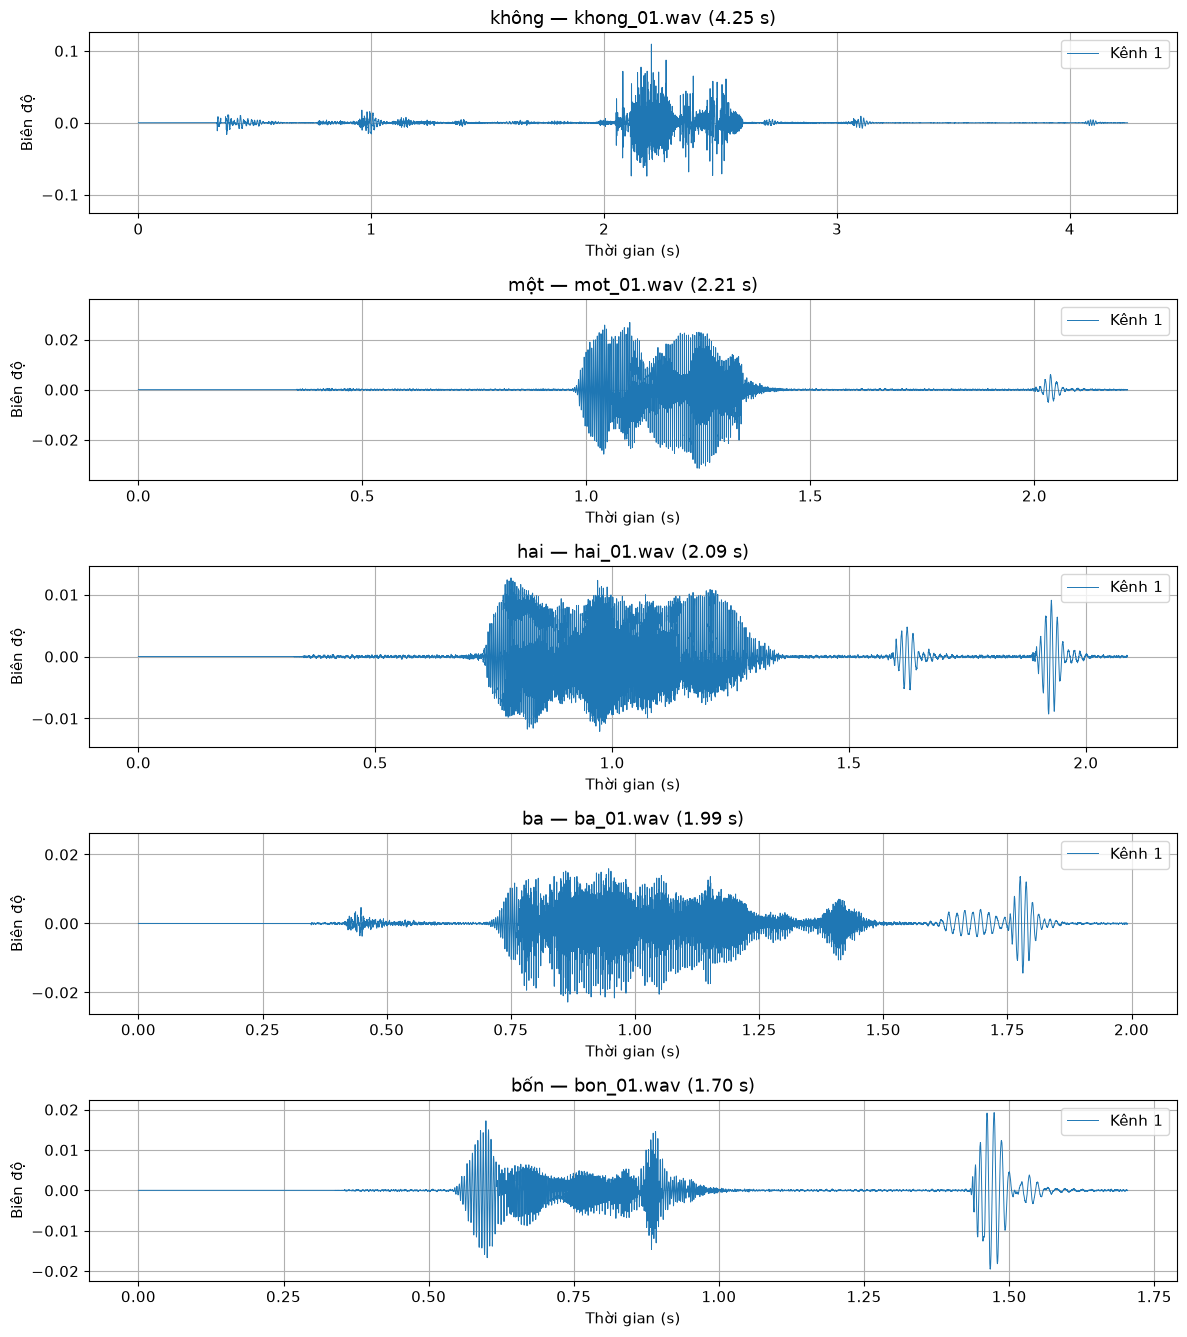

In [9]:
WAVEFORM_FILES = []
for label in LABELS:
    examples = [r for r in AUDIT_ROWS if r["label"] == label and not r["error"]]
    if examples:
        WAVEFORM_FILES.append((label, DATASET_DIR / examples[0]["file"]))

if len(WAVEFORM_FILES) < 3:
    print(f"Chưa vẽ: mới có {len(WAVEFORM_FILES)} nhãn đọc được; cần ít nhất 3 từ.")
else:
    fig, axes = plt.subplots(len(WAVEFORM_FILES), 1,
                             figsize=(12, 2.7 * len(WAVEFORM_FILES)), squeeze=False)
    for ax, (label, path) in zip(axes[:, 0], WAVEFORM_FILES):
        y, sr = sf.read(path, always_2d=True)
        times = np.arange(len(y)) / sr
        for channel in range(y.shape[1]):
            ax.plot(times, y[:, channel], linewidth=0.7, label=f"Kênh {channel + 1}")
        clipped = np.any(np.abs(y) >= 0.999, axis=1)
        if np.any(clipped):
            ax.scatter(times[clipped], y[clipped, 0], s=8, color="red", label="Gần full-scale")
        limit = max(float(np.max(np.abs(y))) * 1.15, 0.001)
        ax.set(title=f"{LABEL_NAMES[label]} — {path.name} ({len(y) / sr:.2f} s)",
               xlabel="Thời gian (s)", ylabel="Biên độ", ylim=(-limit, limit))
        ax.legend(loc="upper right")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "phase2_waveforms.png", dpi=180)
    plt.show()
    plt.close(fig)

def listen_recording(relative_path):
    path = (DATASET_DIR / relative_path).resolve()
    if not path.is_relative_to(DATASET_DIR.resolve()):
        raise ValueError("Chọn file trong dataset")
    display(Audio(filename=str(path)))

# Bỏ dấu # sau khi có bản ghi để nghe và kiểm tra đúng một từ.
# listen_recording("khong/khong_01.wav")

### A5. Nhận xét kỹ thuật và điều kiện hoàn thành

Sau khi thu âm, ghi nhận xét từ bảng/đồ thị thực tế:

- Số lượng từng nhãn, số train/test, thông tin người nói/micro và điều kiện thu.
- File có clipping/âm lượng nhỏ/silence chưa đạt; cách xử lý hoặc thu lại.
- Đánh giá khoảng yên đầu/cuối bằng waveform và nghe lại.
- Xác nhận mỗi file nói đúng một từ; các lần nói độc lập; không trùng train/test.

**Phase 2 chỉ hoàn thành khi:** đủ ≥5 bản ghi/từ cho cả 5 từ, đúng định dạng, split đã chốt, waveform ≥3 từ và có nhận xét sau khi nghe. Không coi trạng thái chưa có dữ liệu là kết quả thực nghiệm.

**Nhận xét từ bộ dữ liệu hiện tại:** bản gốc gồm 25 MP3 mono 48 kHz, mỗi nhãn 5 lần. Chuyển đổi sang WAV PCM 16-bit mono 16 kHz bằng resampling có lọc, giữ nguyên thời lượng và không tăng gain/cắt silence. Chuyển MP3 thành WAV đáp ứng định dạng đầu vào, nhưng không khôi phục thông tin đã mất do nén MP3. Giữ MP3 gốc để truy xuất nguồn dữ liệu.

Các mức peak nhỏ, không phát hiện mẫu gần full-scale; nhiều bản ghi có RMS nhỏ. Khoảng yên đầu dài và đuôi ngắn được cảnh báo từ heuristic RMS; chưa kết luận mất âm hoặc sai nhãn khi chưa nghe. Phase 3 sẽ phân tích energy/ZCR, Phase 4 mới thực hiện cắt silence với margin. Kiểm tra nghe thủ công bằng `listen_recording` trước khi xác nhận dữ liệu cuối cùng.

**Quan sát waveform:** một số file minh họa có xung rời sau vùng tiếng nói chính, rõ ở hai_01.wav và bon_01.wav. Có thể là âm ngoài từ hoặc thao tác khi kết thúc ghi; cần nghe để xác định. Không dùng ngưỡng biên độ đơn lẻ để khẳng định toàn bộ xung này là tiếng nói.

In [10]:
if AUDIT_ROWS and SPLIT_ROWS:
    durations = [r["duration_s"] for r in AUDIT_ROWS]
    low_volume = sum(r["rms"] < 0.005 for r in AUDIT_ROWS)
    near_clip = sum(r["clipping_percent"] > 0 for r in AUDIT_ROWS)
    short_quiet = sum(r["leading_quiet_s"] < 0.2 or r["trailing_quiet_s"] < 0.2 for r in AUDIT_ROWS)
    long_quiet = sum(r["leading_quiet_s"] > 0.5 or r["trailing_quiet_s"] > 0.5 for r in AUDIT_ROWS)
    PHASE2_SUMMARY = f"""### Kết quả kiểm tra Phase 2

- Đủ {len(AUDIT_ROWS)} WAV: 5 nhãn × 5 bản ghi; tất cả PCM mono 16 kHz.
- Split đã chốt: {len(TRAIN_FILES)} train/template, {len(TEST_FILES)} test; không trùng đường dẫn hoặc nội dung âm thanh.
- Thời lượng: {min(durations):.3f}–{max(durations):.3f} s, trung bình {np.mean(durations):.3f} s.
- {near_clip} file có mẫu gần full-scale (ngưỡng |x| ≥ 0,999).
- {low_volume} file RMS < 0,005: cần nghe lại mức âm lượng; chưa tăng gain ở Phase 2.
- Ước lượng RMS: {short_quiet} file có khoảng yên đầu/cuối < 0,2 s; {long_quiet} file có khoảng yên đầu/cuối > 0,5 s. Có thể trùng cả hai nhóm. Đây là cảnh báo sơ bộ, không khẳng định mất âm.
- Đã lưu waveform của {len(WAVEFORM_FILES)} từ.
- Cần người thu nghe lại để xác nhận nhãn và chỉ một từ/file; phân tích biên speech chi tiết ở Phase 3–4.
"""
    display(Markdown(PHASE2_SUMMARY))
    (PROJECT_ROOT / "reports/Phase2_Data_Report.md").write_text(
        "# Báo cáo dữ liệu Lab 2\n\n" + PHASE2_SUMMARY +
        "\nNguồn: 25 MP3 mono 48 kHz. Giữ nguyên MP3; chuyển PCM_16 mono 16 kHz, không cắt silence hoặc tăng gain. "
        "Đổi định dạng không khôi phục thông tin đã mất do nén MP3. "
        "Chi tiết trong outputs/audio_conversion.csv, outputs/dataset_audit.csv và data_split.csv.\n", encoding="utf-8")
else:
    print("Chưa đủ dữ liệu để xuất báo cáo kết quả Phase 2.")

### Kết quả kiểm tra Phase 2

- Đủ 25 WAV: 5 nhãn × 5 bản ghi; tất cả PCM mono 16 kHz.
- Split đã chốt: 15 train/template, 10 test; không trùng đường dẫn hoặc nội dung âm thanh.
- Thời lượng: 1.656–4.248 s, trung bình 2.549 s.
- 0 file có mẫu gần full-scale (ngưỡng |x| ≥ 0,999).
- 22 file RMS < 0,005: cần nghe lại mức âm lượng; chưa tăng gain ở Phase 2.
- Ước lượng RMS: 24 file có khoảng yên đầu/cuối < 0,2 s; 20 file có khoảng yên đầu/cuối > 0,5 s. Có thể trùng cả hai nhóm. Đây là cảnh báo sơ bộ, không khẳng định mất âm.
- Đã lưu waveform của 5 từ.
- Cần người thu nghe lại để xác nhận nhãn và chỉ một từ/file; phân tích biên speech chi tiết ở Phase 3–4.


## B. Đặc trưng miền thời gian — Phase 3

Phân tích toàn bộ 25 WAV đã chuẩn hóa ở Phase 2. Chưa trim, tiền nhấn hoặc chuẩn hóa peak, để quan sát năng lượng và tiếng nền gốc. Minh họa chi tiết bằng file training đầu tiên của mỗi nhãn: không, một, hai, ba, bốn.

### B1. Framing và công thức

Với $F_s=16000$ Hz, $L=400$ mẫu (25 ms), $R=160$ mẫu (10 ms), hai frame chồng lấn 240 mẫu (15 ms). Chỉ lấy frame đầy đủ, không zero-pad đuôi; ghi rõ số mẫu đuôi bị bỏ. Thời gian vẽ đặc trưng là tâm frame $(rR+(L-1)/2)/F_s$.

Frame gốc $u_r[n]=x[rR+n]$; frame Hamming $x_r[n]=u_r[n]w[n]$:

$$w[n]=0.54-0.46\cos\left(\frac{2\pi n}{L-1}\right)$$

$$E_r=\sum_{n=0}^{L-1}x_r[n]^2,\quad RMS_r=\sqrt{E_r/L},\quad M_r=\sum_{n=0}^{L-1}|x_r[n]|$$

$$E_r(\mathrm{dB})=10\log_{10}(E_r+\varepsilon),\quad\varepsilon=10^{-9}$$

Đây là log-energy của tổng bình phương biên độ số, **không phải SPL hoặc dBFS**. Với frame bằng 0, sàn epsilon là −90 dB. RMS ở đây tính trên frame Hamming, khác RMS toàn file ở Phase 2.

ZCR dùng frame **chữ nhật**, quy ước $\mathrm{sgn}(u)=1$ nếu $u\ge0$, ngược lại −1:

$$Z_r=\frac{1}{2L}\sum_{n=1}^{L-1}|\mathrm{sgn}(u_r[n])-\mathrm{sgn}(u_r[n-1])|$$

Mỗi lần đổi dấu đóng góp $1/L$ (crossing/sample), mẫu bằng 0 được xem là không âm. Cửa sổ Hamming có giá trị dương nên không đổi dấu, nhưng phép ZCR vẫn triển khai trực tiếp trên frame gốc. Các công thức được tự tính bằng NumPy, không gọi API feature energy/ZCR.

In [11]:
import lab2_time_features
importlib.reload(lab2_time_features)
from lab2_time_features import (frame_signal, time_features,
                                normalized_autocorrelation, pitch_candidate,
                                illustrative_frames)

if not SPLIT_ROWS:
    raise ValueError("Hoàn thành kiểm tra dữ liệu và split ở phần A trước khi chạy Phase 3.")

TIME_ANALYSIS = {}
FRAME_ROWS, TIME_SUMMARY_ROWS = [], []
for item in SPLIT_ROWS:
    path = DATASET_DIR / item["file"]
    y, sr = sf.read(path, dtype="float64")
    if sr != FS or y.ndim != 1:
        raise ValueError(f"File chưa phải mono {FS} Hz: {path}")
    features = time_features(y, sr, WIN, HOP, EPS)
    TIME_ANALYSIS[item["file"]] = {"y": y, "sr": sr, "features": features}
    TIME_SUMMARY_ROWS.append({
        "file": item["file"], "label": item["label"], "split": item["split"],
        "duration_s": round(len(y) / sr, 4), "n_frames": len(features["frames"]),
        "dropped_tail_samples": int(features["dropped_tail_samples"]),
        "max_energy": float(features["energy"].max()),
        "max_frame_rms": float(features["rms"].max()),
        "mean_zcr": float(features["zcr"].mean()),
        "max_zcr": float(features["zcr"].max()),
    })
    for i, start_sample in enumerate(features["starts"]):
        FRAME_ROWS.append({"file": item["file"], "label": item["label"], "split": item["split"],
                           "frame_index": i, "start_sample": int(start_sample),
                           "time_s": float(features["times"][i]),
                           **{key: float(features[key][i]) for key in
                              ["energy", "log_energy_db", "rms", "magnitude", "zcr"]}})

write_csv(PROJECT_ROOT / "outputs/phase3_frame_features.csv", FRAME_ROWS, list(FRAME_ROWS[0]))
write_csv(PROJECT_ROOT / "outputs/phase3_summary.csv", TIME_SUMMARY_ROWS, list(TIME_SUMMARY_ROWS[0]))
show_table(TIME_SUMMARY_ROWS, ["file", "split", "n_frames", "dropped_tail_samples",
                              "max_frame_rms", "mean_zcr", "max_zcr"])
print(f"Đã phân tích {len(TIME_ANALYSIS)} WAV, {len(FRAME_ROWS)} frame.")

| file | split | n_frames | dropped_tail_samples | max_frame_rms | mean_zcr | max_zcr |
| --- | --- | --- | --- | --- | --- | --- |
| khong/khong_01.wav | train | 423 | 48 | 0.019512105630429728 | 0.1115839243498818 | 0.5775 |
| khong/khong_02.wav | train | 368 | 16 | 0.008933209479193648 | 0.11480298913043478 | 0.2825 |
| khong/khong_03.wav | train | 188 | 16 | 0.006890975791449321 | 0.10304521276595746 | 0.3375 |
| khong/khong_04.wav | test | 219 | 48 | 0.013205548887277993 | 0.10930365296803653 | 0.365 |
| khong/khong_05.wav | test | 341 | 112 | 0.009077159418296007 | 0.06370234604105571 | 0.485 |
| mot/mot_01.wav | train | 219 | 48 | 0.010438302353420434 | 0.10600456621004568 | 0.2325 |
| mot/mot_02.wav | train | 214 | 80 | 0.008419235105830019 | 0.0775 | 0.21 |
| mot/mot_03.wav | train | 207 | 48 | 0.01332211380021882 | 0.10285024154589373 | 0.2575 |
| mot/mot_04.wav | test | 274 | 80 | 0.012656341062349785 | 0.12456204379562043 | 0.33 |
| mot/mot_05.wav | test | 231 | 48 | 0.010799779133027872 | 0.1070995670995671 | 0.27 |
| hai/hai_01.wav | train | 207 | 48 | 0.004181442570525633 | 0.09903381642512077 | 0.315 |
| hai/hai_02.wav | train | 248 | 16 | 0.005285614644363392 | 0.12402217741935484 | 0.24 |
| hai/hai_03.wav | train | 180 | 144 | 0.003416384651610796 | 0.1062222222222222 | 0.265 |
| hai/hai_04.wav | test | 224 | 16 | 0.007205596816639536 | 0.13234375 | 0.5275 |
| hai/hai_05.wav | test | 377 | 112 | 0.005947825024756883 | 0.12330901856763925 | 0.2925 |
| ba/ba_01.wav | train | 197 | 112 | 0.006007011208323902 | 0.11168781725888326 | 0.3275 |
| ba/ba_02.wav | train | 262 | 80 | 0.009050042726053134 | 0.11623091603053436 | 0.265 |
| ba/ba_03.wav | train | 334 | 80 | 0.01472011608415536 | 0.1372305389221557 | 0.3525 |
| ba/ba_04.wav | test | 363 | 48 | 0.008295259627981092 | 0.11343663911845729 | 0.305 |
| ba/ba_05.wav | test | 226 | 80 | 0.008222362943742463 | 0.10015486725663716 | 0.335 |
| bon/bon_01.wav | train | 168 | 144 | 0.00855375942876431 | 0.08474702380952381 | 0.3075 |
| bon/bon_02.wav | train | 274 | 80 | 0.003787125876535363 | 0.09911496350364964 | 0.325 |
| bon/bon_03.wav | train | 164 | 16 | 0.007864825522291468 | 0.08429878048780487 | 0.2275 |
| bon/bon_04.wav | test | 214 | 80 | 0.015811374231739353 | 0.0841355140186916 | 0.235 |
| bon/bon_05.wav | test | 202 | 80 | 0.010201554974753056 | 0.08018564356435642 | 0.3625 |

Đã phân tích 25 WAV, 6324 frame.


### B2. Waveform và đặc trưng theo cùng trục thời gian

Mỗi hình có 5 hàng: waveform, log-energy, RMS, magnitude, ZCR. Trục thời gian được dùng chung. Mức biên độ được giữ nguyên; energy/RMS/magnitude nhấn mạnh vùng tiếng nói, còn ZCR mô tả tốc độ đổi dấu.

Lưu 5 hình `phase3_time_features_<label>.png`. Đồ thị energy có sàn epsilon, không có ngưỡng cắt speech ở Phase 3.

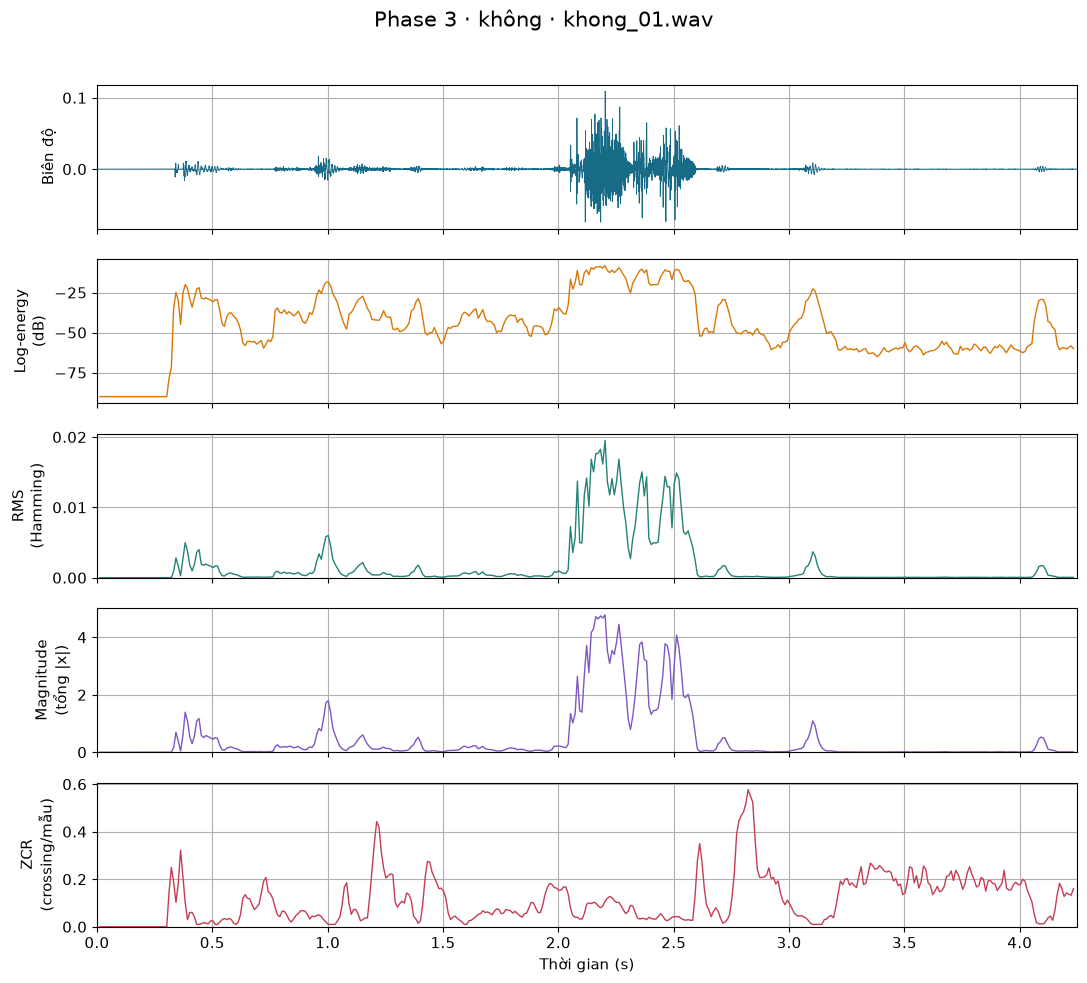

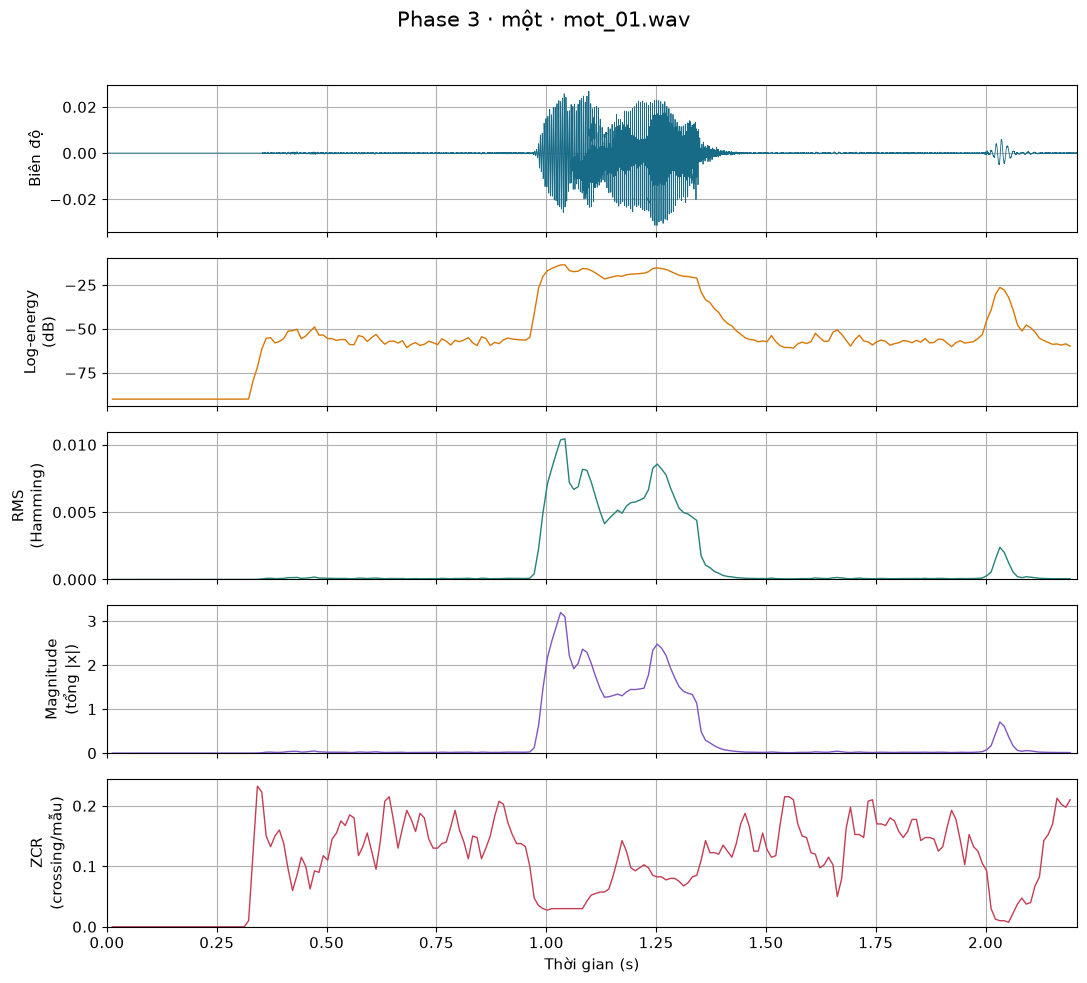

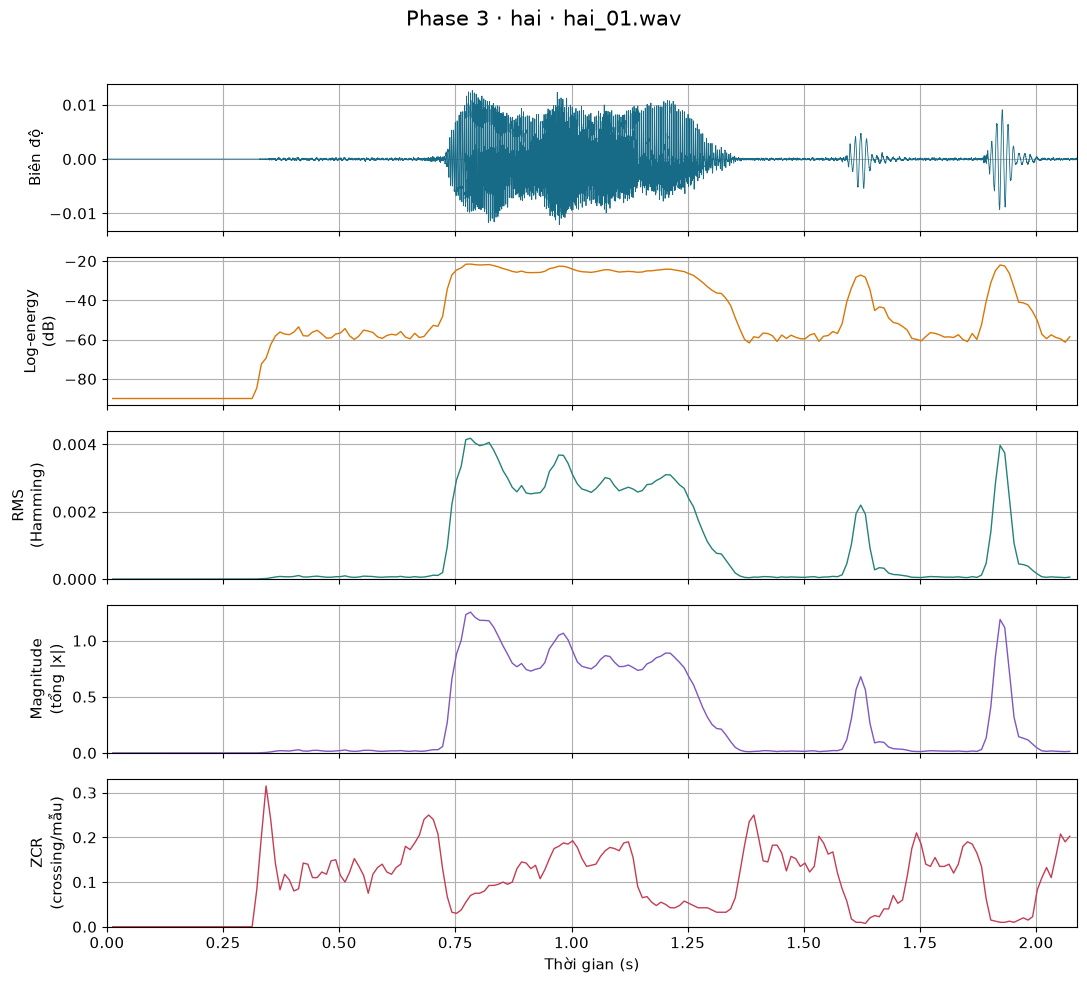

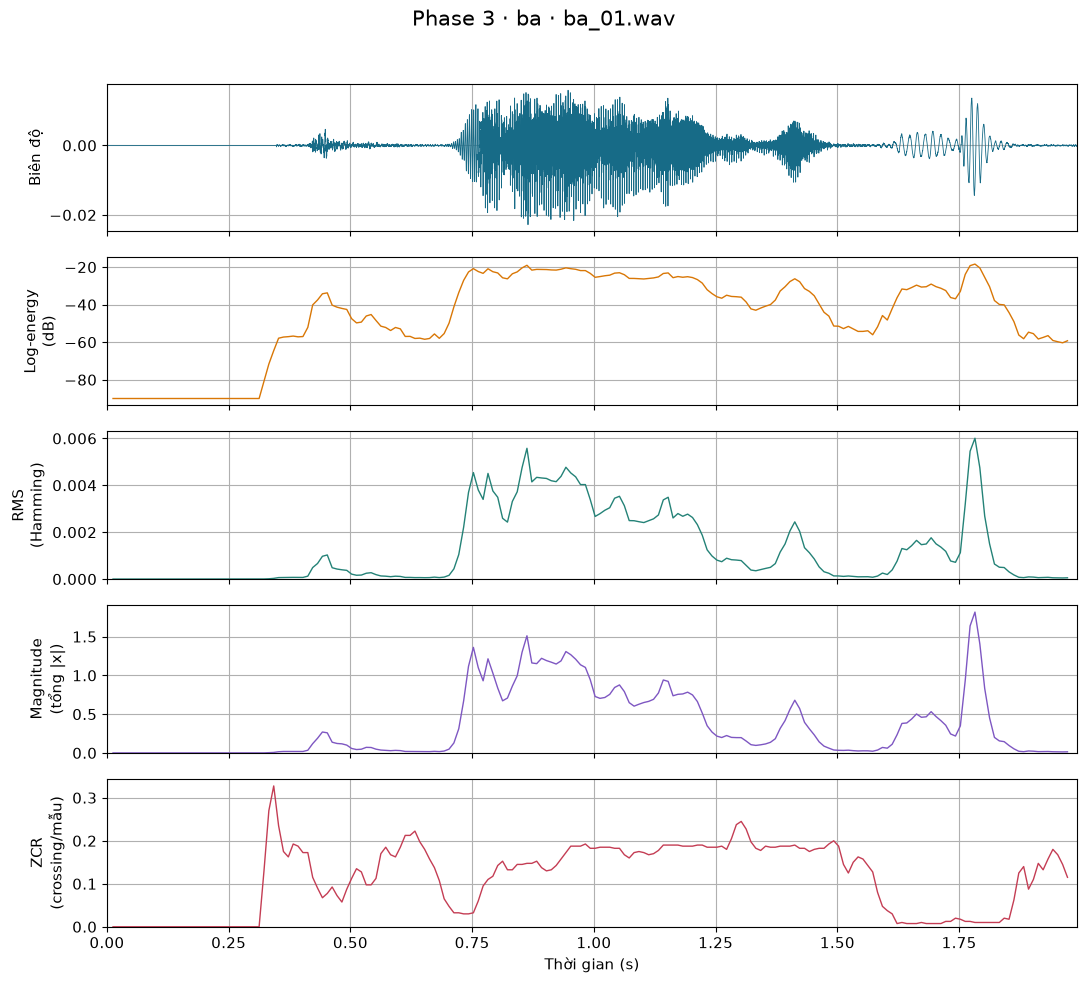

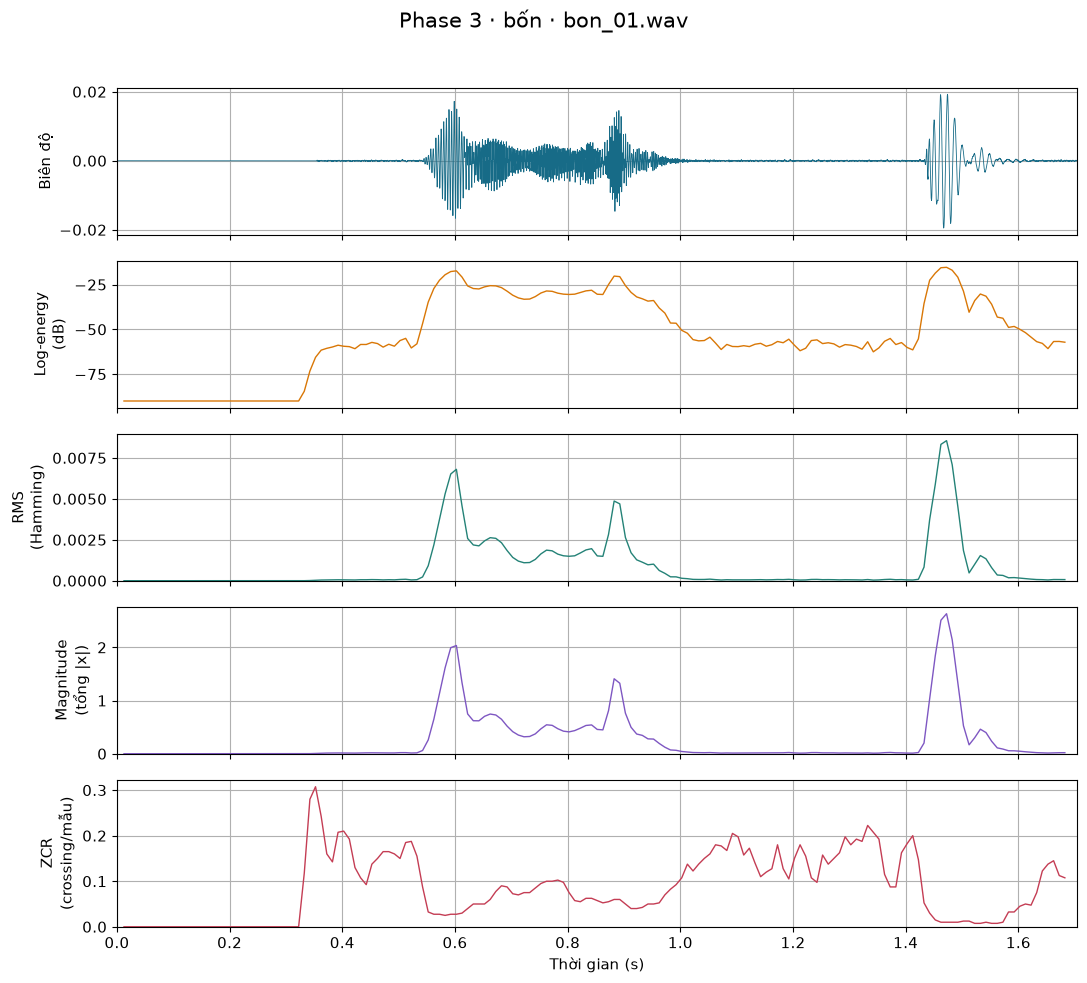

In [12]:
PHASE3_EXAMPLES = [(label, f"{label}/{label}_01.wav") for label in LABELS]
for label, relative in PHASE3_EXAMPLES:
    entry = TIME_ANALYSIS[relative]
    y, sr, f = entry["y"], entry["sr"], entry["features"]
    fig, axes = plt.subplots(5, 1, figsize=(11, 10), sharex=True)
    fig.suptitle(f"Phase 3 · {LABEL_NAMES[label]} · {Path(relative).name}", fontsize=15)
    axes[0].plot(np.arange(len(y)) / sr, y, linewidth=0.6, color="#176b87")
    axes[0].set_ylabel("Biên độ")
    for ax, key, title, color in zip(axes[1:],
            ["log_energy_db", "rms", "magnitude", "zcr"],
            ["Log-energy\n(dB)", "RMS\n(Hamming)", "Magnitude\n(tổng |x|)", "ZCR\n(crossing/mẫu)"],
            ["#d97706", "#248277", "#7e57c2", "#c43d54"]):
        ax.plot(f["times"], f[key], linewidth=1, color=color)
        ax.set_ylabel(title)
        if key != "log_energy_db":
            ax.set_ylim(bottom=0)
    axes[-1].set_xlabel("Thời gian (s)")
    axes[-1].set_xlim(0, len(y) / sr)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    fig.savefig(FIGURES_DIR / f"phase3_time_features_{label}.png", dpi=160, bbox_inches="tight", pad_inches=0.2)
    plt.show()
    plt.close(fig)

### B3. Autocorrelation và minh họa tính tuần hoàn

Để khảo sát periodicity, trừ mean frame rồi nhân Hamming và tính autocorrelation một phía:

$$R[k]=\sum_{n=0}^{L-1-k}v[n]v[n+k],\quad\rho[k]=R[k]/R[0]$$

Với frame bằng 0, trả về correlation bằng 0. Tìm đỉnh cục bộ trong miền $70\le F_0\le400$ Hz (lag 40–228 mẫu), bỏ lag 0; chỉ hiển thị $F_0=F_s/k$ khi đỉnh có $\rho\ge0.3$. Dải pitch và ngưỡng là lựa chọn minh họa, chưa phải pitch tracker đã kiểm chứng; cửa sổ 25 ms có thể không đủ cho pitch thấp và có thể xảy ra lỗi octave.

Chọn frame hữu thanh ứng viên từ vùng năng lượng cao liên tục dài nhất, dựa vào correlation. Ví dụ nền lấy frame năng lượng nhỏ ngoài vùng đó. Frame ZCR cao/ít tuần hoàn trong vùng lân cận onset được ghi là **ứng viên vô thanh/nhiễu**, chưa gán nhãn ngữ âm chắc chắn. Không dùng các lựa chọn này làm endpoint hoặc nhãn thật.

Đặc biệt, frame ZCR cao vẫn có thể hữu thanh khi chứa nhiều hài; nền bằng 0 cũng có ZCR bằng 0. Cần phối hợp energy, ZCR, periodicity và nghe.

| file | type | time_s | log_energy_db | zcr | acf_peak | f0_candidate_hz |
| --- | --- | --- | --- | --- | --- | --- |
| khong/khong_01.wav | Nền năng lượng thấp | 0.0125 | -90.0 | 0.0 | 0.0 |  |
| khong/khong_01.wav | Hữu thanh ứng viên | 2.2225 | -12.575 | 0.1275 | 0.7874 | 253.97 |
| khong/khong_01.wav | ZCR cao (chưa xác nhận vô thanh) | 2.5925 | -25.911 | 0.13 | 0.7353 | 235.29 |
| khong/khong_01.wav | Vô thanh/nhiễu ứng viên | 2.0325 | -38.393 | 0.1675 | 0.281 |  |
| mot/mot_01.wav | Nền năng lượng thấp | 0.0125 | -90.0 | 0.0 | 0.0 |  |
| mot/mot_01.wav | Hữu thanh ứng viên | 1.0525 | -16.839 | 0.03 | 0.8611 | 262.3 |
| mot/mot_01.wav | ZCR cao (chưa xác nhận vô thanh) | 1.1725 | -20.14 | 0.1425 | 0.8178 | 222.22 |
| hai/hai_01.wav | Nền năng lượng thấp | 0.0125 | -90.0 | 0.0 | 0.0 |  |
| hai/hai_01.wav | Hữu thanh ứng viên | 0.7625 | -23.484 | 0.0375 | 0.8587 | 246.15 |
| hai/hai_01.wav | ZCR cao (chưa xác nhận vô thanh) | 1.0025 | -24.177 | 0.1925 | 0.8151 | 250.0 |
| hai/hai_01.wav | Vô thanh/nhiễu ứng viên | 0.6925 | -55.419 | 0.25 | 0.2271 |  |
| ba/ba_01.wav | Nền năng lượng thấp | 0.0125 | -90.0 | 0.0 | 0.0 |  |
| ba/ba_01.wav | Hữu thanh ứng viên | 0.7425 | -22.62 | 0.03 | 0.8243 | 235.29 |
| ba/ba_01.wav | ZCR cao (chưa xác nhận vô thanh) | 0.9825 | -21.872 | 0.1925 | 0.7701 | 213.33 |
| ba/ba_01.wav | Vô thanh/nhiễu ứng viên | 0.5725 | -52.174 | 0.185 | 0.1389 |  |
| bon/bon_01.wav | Nền năng lượng thấp | 0.0125 | -90.0 | 0.0 | 0.0 |  |
| bon/bon_01.wav | Hữu thanh ứng viên | 0.5925 | -17.699 | 0.0275 | 0.8245 | 219.18 |
| bon/bon_01.wav | ZCR cao (chưa xác nhận vô thanh) | 0.7825 | -29.772 | 0.1025 | 0.7904 | 205.13 |

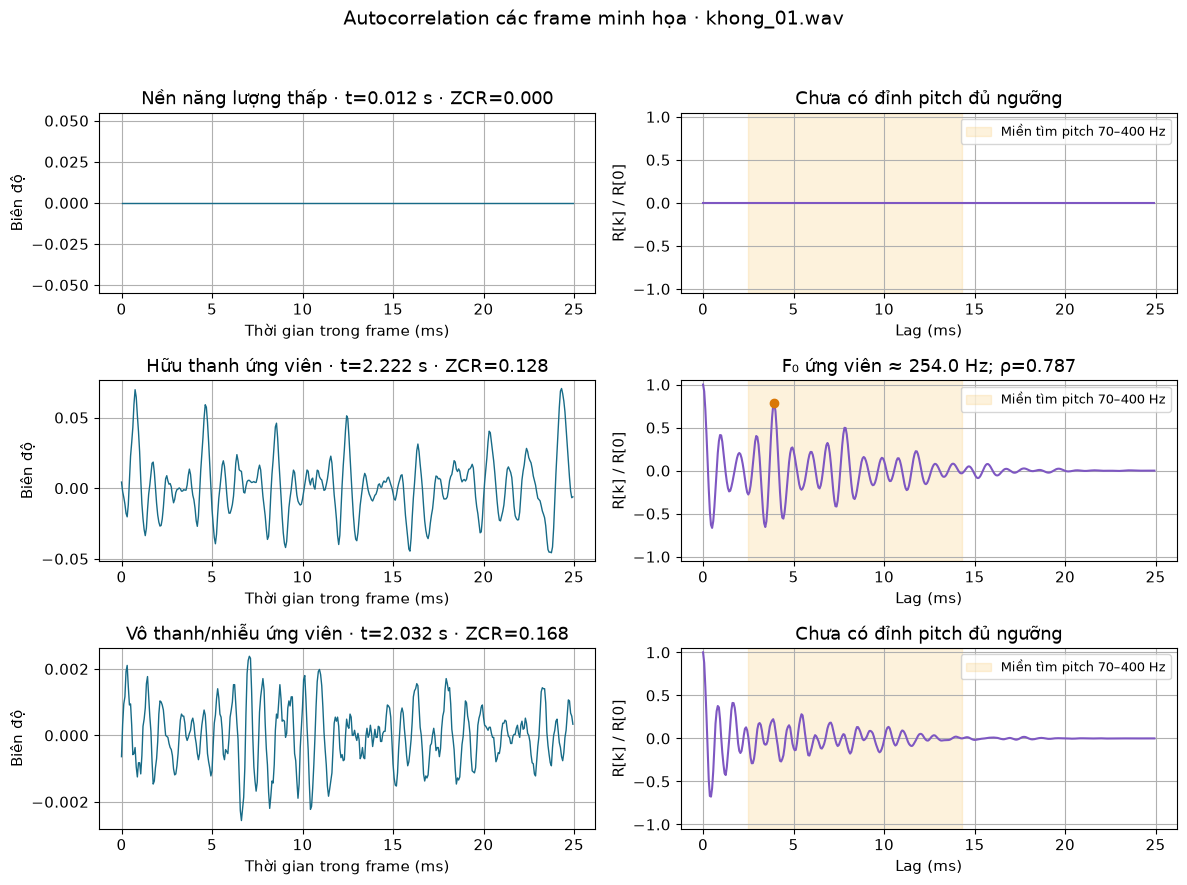

In [13]:
FRAME_EXAMPLES = {}
ILLUSTRATION_ROWS = []
for label, relative in PHASE3_EXAMPLES:
    entry = TIME_ANALYSIS[relative]
    f = entry["features"]
    selected = illustrative_frames(f, FS)
    FRAME_EXAMPLES[relative] = selected
    choices = [
        ("background", "Nền năng lượng thấp"),
        ("voiced_candidate", "Hữu thanh ứng viên"),
        ("high_zcr_candidate", "ZCR cao (chưa xác nhận vô thanh)"),
        ("unvoiced_candidate", "Vô thanh/nhiễu ứng viên"),
    ]
    for key, description in choices:
        i = selected[key]
        if i is None:
            continue
        pitch = pitch_candidate(f["frames"][i], FS)
        ILLUSTRATION_ROWS.append({
            "file": relative, "type": description, "frame_index": i,
            "time_s": round(float(f["times"][i]), 4),
            "log_energy_db": round(float(f["log_energy_db"][i]), 3),
            "zcr": round(float(f["zcr"][i]), 4),
            "acf_peak": round(pitch["correlation"], 4),
            "f0_candidate_hz": round(pitch["f0_hz"], 2) if pitch["f0_hz"] else "",
        })
show_table(ILLUSTRATION_ROWS, ["file", "type", "time_s", "log_energy_db", "zcr", "acf_peak", "f0_candidate_hz"])
write_csv(PROJECT_ROOT / "outputs/phase3_frame_examples.csv", ILLUSTRATION_ROWS, list(ILLUSTRATION_ROWS[0]))

relative = "khong/khong_01.wav"
f = TIME_ANALYSIS[relative]["features"]
selected = FRAME_EXAMPLES[relative]
panels = [("background", "Nền năng lượng thấp"),
          ("voiced_candidate", "Hữu thanh ứng viên"),
          ("unvoiced_candidate", "Vô thanh/nhiễu ứng viên")]
panels = [(key, title) for key, title in panels if selected[key] is not None]
fig, axes = plt.subplots(len(panels), 2, figsize=(12, 3 * len(panels)), squeeze=False)
for row, (key, title) in enumerate(panels):
    i = selected[key]
    frame = f["frames"][i]
    result = pitch_candidate(frame, FS)
    axes[row, 0].plot(np.arange(WIN) / FS * 1000, frame, color="#176b87", linewidth=1)
    axes[row, 0].set(title=f"{title} · t={f['times'][i]:.3f} s · ZCR={f['zcr'][i]:.3f}",
                     xlabel="Thời gian trong frame (ms)", ylabel="Biên độ")
    axes[row, 1].plot(np.arange(WIN) / FS * 1000, result["acf"], color="#7e57c2")
    axes[row, 1].axvspan(1000 / 400, 1000 / 70, color="#f4b942", alpha=0.18,
                        label="Miền tìm pitch 70–400 Hz")
    if result["lag"] is not None:
        lag_ms = result["lag"] / FS * 1000
        axes[row, 1].scatter([lag_ms], [result["acf"][result["lag"]]], color="#d97706", zorder=3)
        axes[row, 1].set_title(f"F₀ ứng viên ≈ {result['f0_hz']:.1f} Hz; ρ={result['correlation']:.3f}")
    else:
        axes[row, 1].set_title("Chưa có đỉnh pitch đủ ngưỡng")
    axes[row, 1].set(xlabel="Lag (ms)", ylabel="R[k] / R[0]", ylim=(-1.05, 1.05))
    axes[row, 1].legend(loc="upper right", fontsize=9)
fig.suptitle("Autocorrelation các frame minh họa · khong_01.wav", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(FIGURES_DIR / "phase3_autocorrelation.png", dpi=160, bbox_inches="tight", pad_inches=0.2)
plt.show()
plt.close(fig)

### B4. Nhận xét kỹ thuật

- Silence/nền thấp: energy, RMS và magnitude gần 0. ZCR có thể bằng 0 khi tín hiệu bằng 0 hoặc cao hơn nếu có nhiễu; không xác định voiced chỉ từ ZCR nhỏ.
- Vùng tiếng nói chính: energy/RMS/magnitude tăng rõ. Hữu thanh thường có cấu trúc tuần hoàn và đỉnh autocorrelation sau lag 0.
- Frame vô thanh/nhiễu ứng viên: năng lượng thường nhỏ hơn vùng voiced và ZCR có thể cao hơn; cần nghe để phân biệt phụ âm vô thanh với nhiễu/thao tác ghi.
- Xung rời cuối bản ghi cũng tạo đỉnh energy; endpoint không nên giữ toàn bộ chỉ vì vượt ngưỡng.
- Energy bình phương biên độ nên nhấn mạnh peak, magnitude dùng trị tuyệt đối có dải biến thiên nhỏ hơn. Với L cố định, RMS = sqrt(E/L), không cung cấp thông tin độc lập với energy.
- Tổng energy các frame chồng lấn không phải tổng energy toàn file vì mẫu bị đếm nhiều lần và có Hamming.

Các số liệu cụ thể bên dưới được sinh từ 5 file minh họa và lưu vào báo cáo Phase 3.

In [14]:
voiced_rows = [r for r in ILLUSTRATION_ROWS if r["type"] == "Hữu thanh ứng viên"]
pitch_values = [r["f0_candidate_hz"] for r in voiced_rows if r["f0_candidate_hz"] != ""]
lines = ["# Phase 3 — Phân tích đặc trưng miền thời gian", "",
         f"Đã phân tích {len(TIME_ANALYSIS)} WAV, tổng {len(FRAME_ROWS)} frame đầy đủ.",
         "Cấu hình: 16 kHz; frame 400 mẫu (25 ms); hop 160 mẫu (10 ms); Hamming cho energy/RMS/magnitude, frame gốc cho ZCR; epsilon=1e-9.",
         "", "## Quan sát từ dữ liệu thật", ""]
for relative, selected in FRAME_EXAMPLES.items():
    f = TIME_ANALYSIS[relative]["features"]
    a, b = selected["main_indices"][[0, -1]]
    voiced = selected["voiced_candidate"]
    result = selected["voiced_pitch"]
    f0_text = f"{result['f0_hz']:.1f} Hz" if result["f0_hz"] else "chưa đủ ngưỡng"
    lines.append(f"- {relative}: {len(f['frames'])} frame; vùng năng lượng liên tục chính khoảng "
                 f"{f['times'][a]:.3f}–{f['times'][b]:.3f} s (ước lượng minh họa, chưa trim). "
                 f"Frame hữu thanh ứng viên t={f['times'][voiced]:.3f} s, "
                 f"ZCR={f['zcr'][voiced]:.3f}, F₀ ứng viên {f0_text}, ρ={result['correlation']:.3f}.")
lines += ["", "## Diễn giải và giới hạn", "",
          "Energy/RMS/magnitude tăng ở vùng tiếng nói; nền bằng 0 đạt sàn log-energy -90 dB. "
          "Các ví dụ hữu thanh có đỉnh autocorrelation rõ, nhưng không phải nhãn ngữ âm đã xác nhận bằng nghe. "
          "Frame ZCR cao vẫn có thể tuần hoàn: không dùng riêng ZCR để khẳng định unvoiced.",
          "Các xung rời cuối bản ghi (đặc biệt hai_01/bon_01) cũng tạo peak energy; cần phân biệt với tiếng nói khi làm endpoint ở Phase 4.",
          "RMS frame Hamming khác RMS toàn file. Log-energy không phải SPL/dBFS. "
          "Pitch là minh họa từ frame 25 ms, có thể sai octave hoặc thiếu chu kỳ ở pitch thấp; không dùng làm feature bắt buộc cho DTW.",
          "", "## Sản phẩm", "",
          "- outputs/phase3_frame_features.csv: từng frame của 25 WAV.",
          "- outputs/phase3_summary.csv: thống kê từng file.",
          "- outputs/phase3_frame_examples.csv: frame nền/hữu thanh/ZCR cao/vô thanh hoặc nhiễu ứng viên.",
          "- figures/phase3_time_features_<label>.png: 5 hình waveform + log-energy + RMS + magnitude + ZCR.",
          "- figures/phase3_autocorrelation.png: minh họa periodicity và pitch."]
PHASE3_REPORT = "\n".join(lines) + "\n"
(PROJECT_ROOT / "reports/Phase3_Time_Features_Report.md").write_text(PHASE3_REPORT, encoding="utf-8")
display(Markdown(PHASE3_REPORT))
print("Phase 3: đã xuất bảng đặc trưng, 6 hình và báo cáo nhận xét.")

# Phase 3 — Phân tích đặc trưng miền thời gian

Đã phân tích 25 WAV, tổng 6324 frame đầy đủ.
Cấu hình: 16 kHz; frame 400 mẫu (25 ms); hop 160 mẫu (10 ms); Hamming cho energy/RMS/magnitude, frame gốc cho ZCR; epsilon=1e-9.

## Quan sát từ dữ liệu thật

- khong/khong_01.wav: 423 frame; vùng năng lượng liên tục chính khoảng 2.052–2.592 s (ước lượng minh họa, chưa trim). Frame hữu thanh ứng viên t=2.222 s, ZCR=0.128, F₀ ứng viên 254.0 Hz, ρ=0.787.
- mot/mot_01.wav: 219 frame; vùng năng lượng liên tục chính khoảng 0.982–1.352 s (ước lượng minh họa, chưa trim). Frame hữu thanh ứng viên t=1.052 s, ZCR=0.030, F₀ ứng viên 262.3 Hz, ρ=0.861.
- hai/hai_01.wav: 207 frame; vùng năng lượng liên tục chính khoảng 0.732–1.332 s (ước lượng minh họa, chưa trim). Frame hữu thanh ứng viên t=0.762 s, ZCR=0.037, F₀ ứng viên 246.2 Hz, ρ=0.859.
- ba/ba_01.wav: 197 frame; vùng năng lượng liên tục chính khoảng 0.722–1.252 s (ước lượng minh họa, chưa trim). Frame hữu thanh ứng viên t=0.742 s, ZCR=0.030, F₀ ứng viên 235.3 Hz, ρ=0.824.
- bon/bon_01.wav: 168 frame; vùng năng lượng liên tục chính khoảng 0.562–0.932 s (ước lượng minh họa, chưa trim). Frame hữu thanh ứng viên t=0.592 s, ZCR=0.028, F₀ ứng viên 219.2 Hz, ρ=0.824.

## Diễn giải và giới hạn

Energy/RMS/magnitude tăng ở vùng tiếng nói; nền bằng 0 đạt sàn log-energy -90 dB. Các ví dụ hữu thanh có đỉnh autocorrelation rõ, nhưng không phải nhãn ngữ âm đã xác nhận bằng nghe. Frame ZCR cao vẫn có thể tuần hoàn: không dùng riêng ZCR để khẳng định unvoiced.
Các xung rời cuối bản ghi (đặc biệt hai_01/bon_01) cũng tạo peak energy; cần phân biệt với tiếng nói khi làm endpoint ở Phase 4.
RMS frame Hamming khác RMS toàn file. Log-energy không phải SPL/dBFS. Pitch là minh họa từ frame 25 ms, có thể sai octave hoặc thiếu chu kỳ ở pitch thấp; không dùng làm feature bắt buộc cho DTW.

## Sản phẩm

- outputs/phase3_frame_features.csv: từng frame của 25 WAV.
- outputs/phase3_summary.csv: thống kê từng file.
- outputs/phase3_frame_examples.csv: frame nền/hữu thanh/ZCR cao/vô thanh hoặc nhiễu ứng viên.
- figures/phase3_time_features_<label>.png: 5 hình waveform + log-energy + RMS + magnitude + ZCR.
- figures/phase3_autocorrelation.png: minh họa periodicity và pitch.


Phase 3: đã xuất bảng đặc trưng, 6 hình và báo cáo nhận xét.


## C. Endpoint detection — Phase 4

### C1. Thuật toán và cấu hình

Tự xác định biên từ log-energy Hamming đã học ở Phase 3; không chỉ gọi hàm trim thư viện. Giả thiết: mỗi WAV có **một từ tách rời**. Cùng cấu hình được áp dụng cho train/test; chưa dùng accuracy test để chọn tham số.

1. Tính energy/ZCR với frame 25 ms, hop 10 ms. Lọc trung vị log-energy qua 5 frame để giảm ảnh hưởng xung ngắn.
2. Ước lượng nền bằng median log-energy ở 200 ms đầu/cuối, bỏ frame bằng 0 số. Nếu không có frame khác 0, dùng sàn epsilon −90 dB.
3. Ngưỡng cao $T_H=\max(E_{peak}-18, E_{noise}+12)$; ngưỡng thấp $T_L=\max(E_{peak}-30, E_{noise}+6)$ (dB). Nếu nền đầu/cuối chứa âm quá mạnh khiến $T_H\ge E_{peak}-3$, dùng ngưỡng tương đối theo peak và phát cảnh báo. Bảo đảm $T_L<T_H$.
4. Nối khoảng đứt ≤40 ms; giữ vùng vượt ngưỡng cao dài ít nhất 120 ms; chọn vùng liên tục dài nhất, hòa thì chọn tổng energy lớn hơn. Đây là heuristic của bài, không phải VAD chuẩn hay quy tắc ngữ âm.
5. Mở rộng biên tối đa 150 ms mỗi phía bằng ngưỡng thấp. ZCR ≥0,10 hỗ trợ frame yếu nếu vẫn đạt energy ≥max($T_L-5$, $E_{noise}+3$); ZCR cao đơn lẻ không mở rộng biên.
6. Cộng **margin 80 ms** mỗi phía; giới hạn trong `[0, len(y)]`. Điểm cuối sample là exclusive; frame cuối là inclusive.
7. Nếu chỉ có nền hoặc xung quá ngắn, báo lỗi, không xuất một vùng speech giả. Vùng năng lượng khác ngoài vùng chính được ghi cảnh báo để nghe xác nhận.

`TOP_DB=35` trong baseline thư viện không được dùng làm ngưỡng của thuật toán hai mức này. Không tăng gain, không tiền nhấn và không thay đổi mẫu bên trong đoạn đã chọn. Đầu ra là WAV mono PCM_16 16 kHz trong `trimmed/<label>/`.

Chọn đoạn dài nhất có thể bỏ nhầm tiếng nói nếu file chứa nhiều từ hoặc phụ âm tách xa; cần kiểm tra waveform và nghe, đặc biệt khi xuất hiện cảnh báo.

In [15]:
import hashlib
import json
import lab2_endpoint
importlib.reload(lab2_endpoint)
from lab2_endpoint import detect_endpoint, trim_endpoint

ENDPOINT_CONFIG = {
    "frame_length": WIN, "hop_length": HOP,
    "high_top_db": 18, "low_top_db": 30,
    "noise_high_db": 12, "noise_low_db": 6,
    "min_speech_ms": 120, "gap_ms": 40,
    "extend_ms": 150, "margin_ms": MARGIN_MS,
    "zcr_threshold": 0.10, "use_zcr": True, "eps": EPS,
}
show_table([{"Tham số": key, "Giá trị": value} for key, value in ENDPOINT_CONFIG.items()],
           ["Tham số", "Giá trị"])
(PROJECT_ROOT / "endpoint_config.json").write_text(
    json.dumps({"sample_rate": FS, **ENDPOINT_CONFIG}, indent=2, ensure_ascii=False), encoding="utf-8")

| Tham số | Giá trị |
| --- | --- |
| frame_length | 400 |
| hop_length | 160 |
| high_top_db | 18 |
| low_top_db | 30 |
| noise_high_db | 12 |
| noise_low_db | 6 |
| min_speech_ms | 120 |
| gap_ms | 40 |
| extend_ms | 150 |
| margin_ms | 80 |
| zcr_threshold | 0.1 |
| use_zcr | True |
| eps | 1e-09 |

293

### C2. Trim và xuất WAV cho toàn bộ dữ liệu

Nguồn là các WAV đã chốt trong manifest Phase 2; split giữ nguyên. Báo cáo ngưỡng thực tế của từng file vì mức peak/nền khác nhau. Đọc lại WAV sau khi ghi để kiểm tra sampling rate, subtype, thời lượng và từng sample khớp lát cắt nguồn.

Hàm tự báo lỗi khi không tìm được vùng; nếu bất kỳ file nào lỗi, notebook yêu cầu kiểm tra trước khi đi tiếp.

In [16]:
ENDPOINT_RESULTS, TRIM_ROWS, TRIM_ERRORS = {}, [], []
for item in SPLIT_ROWS:
    relative = item["file"]
    entry = TIME_ANALYSIS[relative]
    y, sr = entry["y"], entry["sr"]
    try:
        trimmed, info = trim_endpoint(y, sr, **ENDPOINT_CONFIG)
        destination = TRIMMED_DIR / relative
        destination.parent.mkdir(parents=True, exist_ok=True)
        sf.write(destination, trimmed, sr, subtype=WAV_SUBTYPE)
        check, check_sr = sf.read(destination, dtype="float64")
        assert check_sr == FS and sf.info(destination).subtype == WAV_SUBTYPE
        assert np.array_equal(check, trimmed), f"Sample mismatch: {relative}"
        ENDPOINT_RESULTS[relative] = {"trimmed": trimmed, "info": info}
        original_s, trimmed_s = len(y) / sr, len(trimmed) / sr
        TRIM_ROWS.append({
            "file": relative, "label": item["label"], "split": item["split"],
            "before_s": round(original_s, 4), "after_s": round(trimmed_s, 4),
            "removed_s": round(original_s - trimmed_s, 4),
            "removed_percent": round((1 - trimmed_s / original_s) * 100, 2),
            "start_sample": info["start_sample"], "end_sample_exclusive": info["end_sample"],
            "start_frame": info["start_frame"], "end_frame_inclusive": info["end_frame"],
            "start_s": info["start_sample"] / sr, "end_s": info["end_sample"] / sr,
            "noise_db": round(info["noise_db"], 3),
            "high_threshold_db": round(info["high_threshold_db"], 3),
            "low_threshold_db": round(info["low_threshold_db"], 3),
            "margin_ms": MARGIN_MS, "warnings": "; ".join(info["warnings"]),
            "source_audio_hash": item["audio_hash"],
            "trimmed_sha256": hashlib.sha256(destination.read_bytes()).hexdigest(),
        })
    except (ValueError, AssertionError) as exc:
        TRIM_ERRORS.append({"file": relative, "error": str(exc)})

if TRIM_ROWS:
    write_csv(PROJECT_ROOT / "outputs/phase4_trim_results.csv", TRIM_ROWS, list(TRIM_ROWS[0]))
    show_table(TRIM_ROWS, ["file", "split", "before_s", "after_s", "removed_percent",
                           "start_s", "end_s", "warnings"])
if TRIM_ERRORS:
    show_table(TRIM_ERRORS, ["file", "error"])
    raise ValueError("Có file chưa trim được; kiểm tra và sửa trước khi tiếp tục.")
print(f"Đã xuất và kiểm tra sample của {len(TRIM_ROWS)} WAV trong trimmed/.")

| file | split | before_s | after_s | removed_percent | start_s | end_s | warnings |
| --- | --- | --- | --- | --- | --- | --- | --- |
| khong/khong_01.wav | train | 4.248 | 0.815 | 80.81 | 1.88 | 2.695 |  |
| khong/khong_02.wav | train | 3.696 | 0.895 | 75.78 | 0.68 | 1.575 |  |
| khong/khong_03.wav | train | 1.896 | 0.875 | 53.85 | 0.24 | 1.115 |  |
| khong/khong_04.wav | test | 2.208 | 0.425 | 80.75 | 1.18 | 1.605 |  |
| khong/khong_05.wav | test | 3.432 | 0.695 | 79.75 | 1.81 | 2.505 |  |
| mot/mot_01.wav | train | 2.208 | 0.625 | 71.69 | 0.88 | 1.505 |  |
| mot/mot_02.wav | train | 2.16 | 0.895 | 58.56 | 0.71 | 1.605 |  |
| mot/mot_03.wav | train | 2.088 | 0.455 | 78.21 | 1.13 | 1.585 |  |
| mot/mot_04.wav | test | 2.76 | 0.745 | 73.01 | 1.54 | 2.285 |  |
| mot/mot_05.wav | test | 2.328 | 0.475 | 79.6 | 0.8 | 1.275 |  |
| hai/hai_01.wav | train | 2.088 | 0.775 | 62.88 | 0.64 | 1.415 |  |
| hai/hai_02.wav | train | 2.496 | 0.665 | 73.36 | 1.49 | 2.155 |  |
| hai/hai_03.wav | train | 1.824 | 0.475 | 73.96 | 0.6 | 1.075 |  |
| hai/hai_04.wav | test | 2.256 | 0.675 | 70.08 | 1.03 | 1.705 | Có vùng năng lượng khác ngoài vùng chính; cần nghe để xác nhận không phải tiếng nói |
| hai/hai_05.wav | test | 3.792 | 0.625 | 83.52 | 1.54 | 2.165 | Nền đầu/cuối có thể chứa âm mạnh; dùng ngưỡng tương đối theo peak; Có vùng năng lượng khác ngoài vùng chính; cần nghe để xác nhận không phải tiếng nói |
| ba/ba_01.wav | train | 1.992 | 0.925 | 53.56 | 0.62 | 1.545 | Có vùng năng lượng khác ngoài vùng chính; cần nghe để xác nhận không phải tiếng nói |
| ba/ba_02.wav | train | 2.64 | 0.935 | 64.58 | 0.79 | 1.725 | Có vùng năng lượng khác ngoài vùng chính; cần nghe để xác nhận không phải tiếng nói |
| ba/ba_03.wav | train | 3.36 | 0.725 | 78.42 | 1.9 | 2.625 |  |
| ba/ba_04.wav | test | 3.648 | 1.775 | 51.34 | 0.88 | 2.655 |  |
| ba/ba_05.wav | test | 2.28 | 0.555 | 75.66 | 0.89 | 1.445 |  |
| bon/bon_01.wav | train | 1.704 | 0.605 | 64.5 | 0.46 | 1.065 | Có vùng năng lượng khác ngoài vùng chính; cần nghe để xác nhận không phải tiếng nói |
| bon/bon_02.wav | train | 2.76 | 1.305 | 52.72 | 0.69 | 1.995 |  |
| bon/bon_03.wav | train | 1.656 | 0.465 | 71.92 | 0.63 | 1.095 |  |
| bon/bon_04.wav | test | 2.16 | 0.585 | 72.92 | 1.01 | 1.595 | Có vùng năng lượng khác ngoài vùng chính; cần nghe để xác nhận không phải tiếng nói |
| bon/bon_05.wav | test | 2.04 | 0.535 | 73.77 | 0.62 | 1.155 | Có vùng năng lượng khác ngoài vùng chính; cần nghe để xác nhận không phải tiếng nói |

Đã xuất và kiểm tra sample của 25 WAV trong trimmed/.


### C3. Hình kiểm tra biên trước/sau

Minh họa cả 5 từ bằng file `_01.wav`. Vùng xanh là khoảng giữ lại, đường đứt là start/end sau margin. Log-energy có ngưỡng cao/thấp và mức nền. Đồ thị cuối đặt đoạn đã trim ở thời gian cục bộ bắt đầu từ 0.

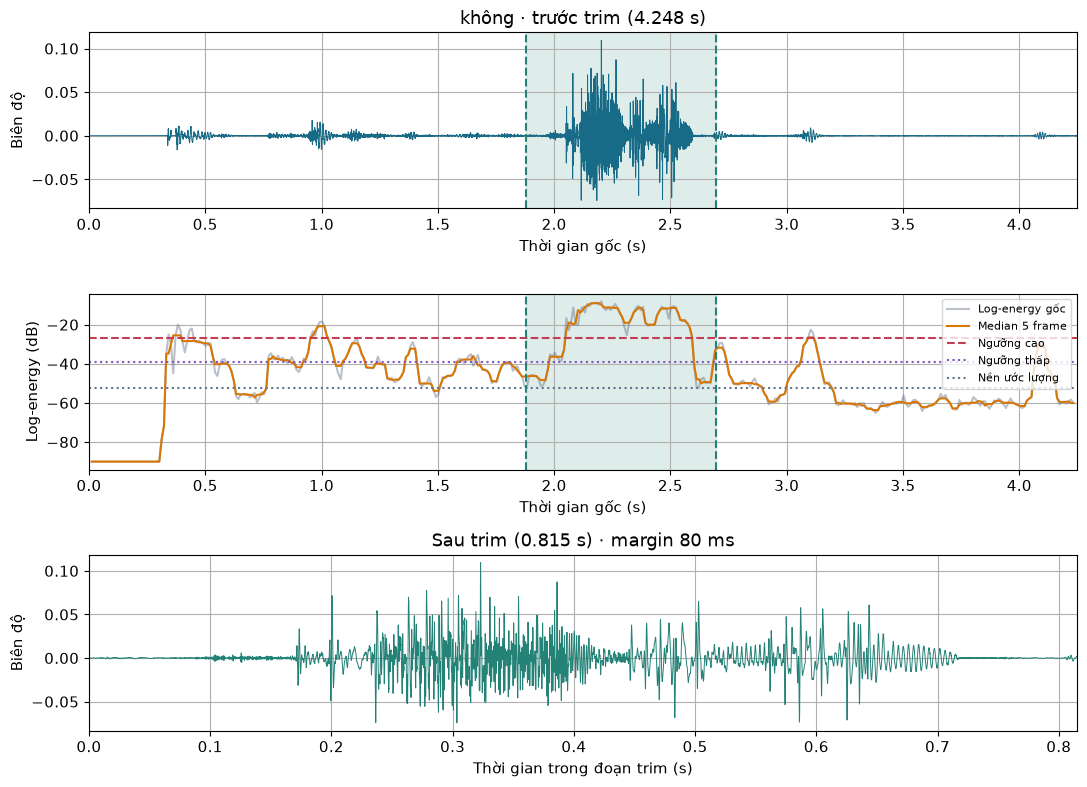

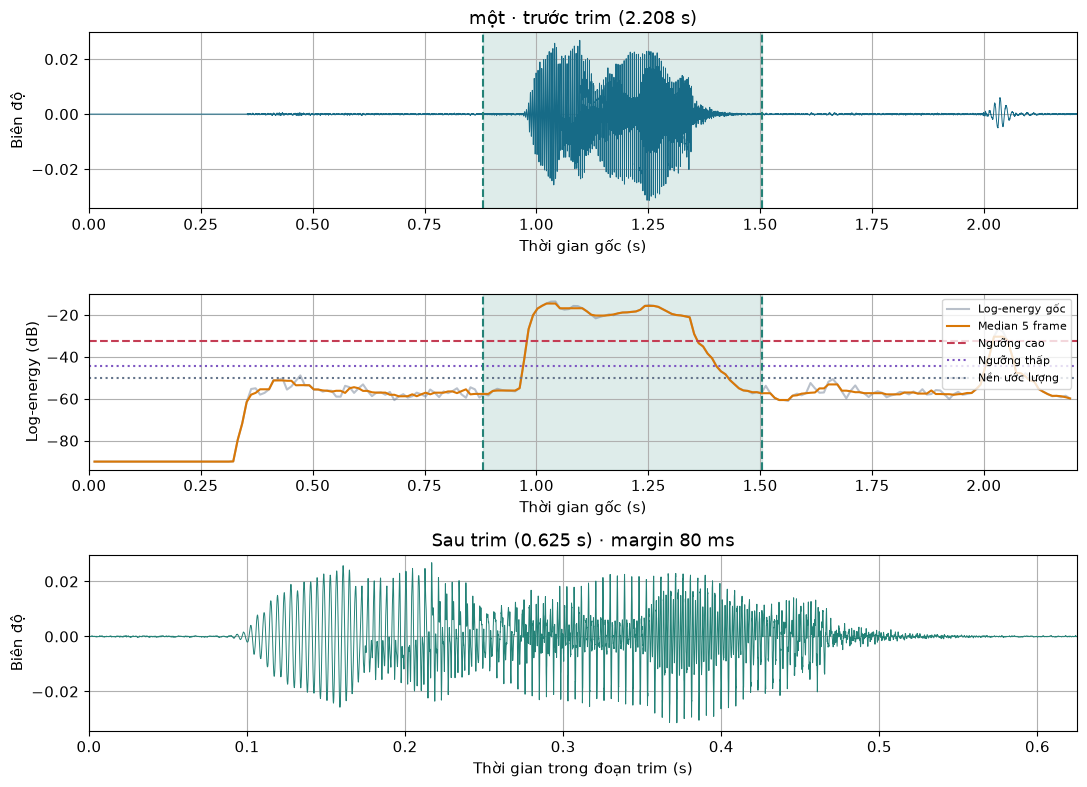

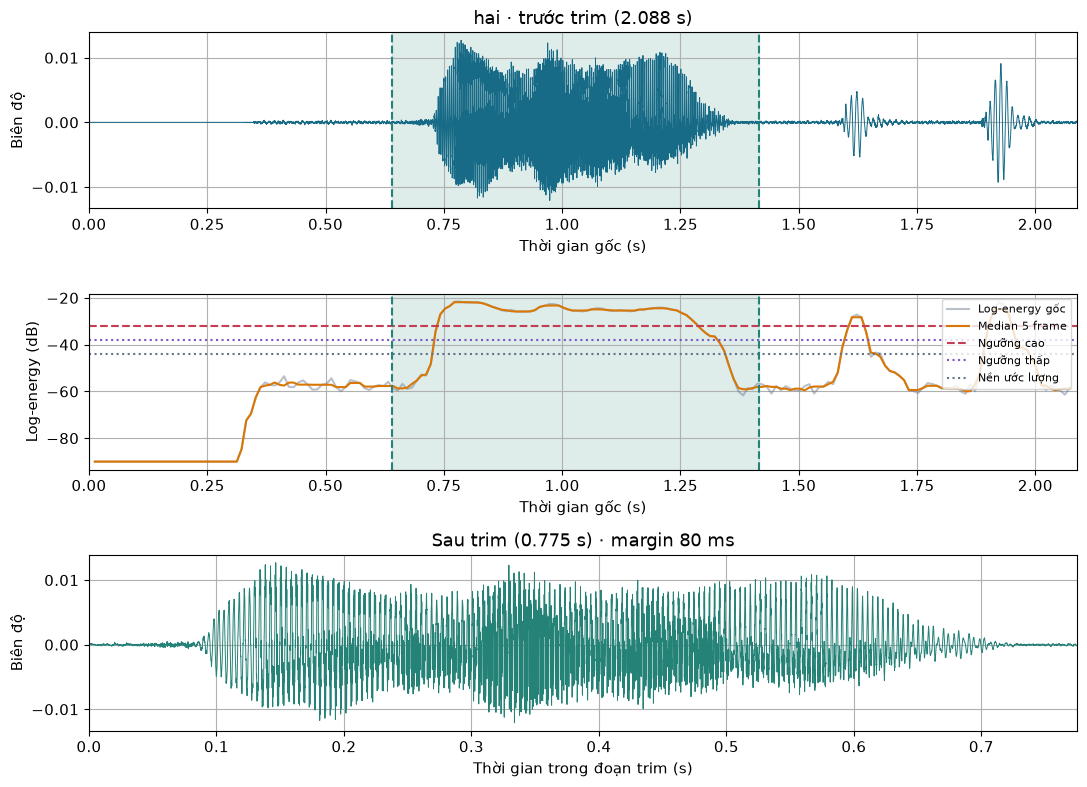

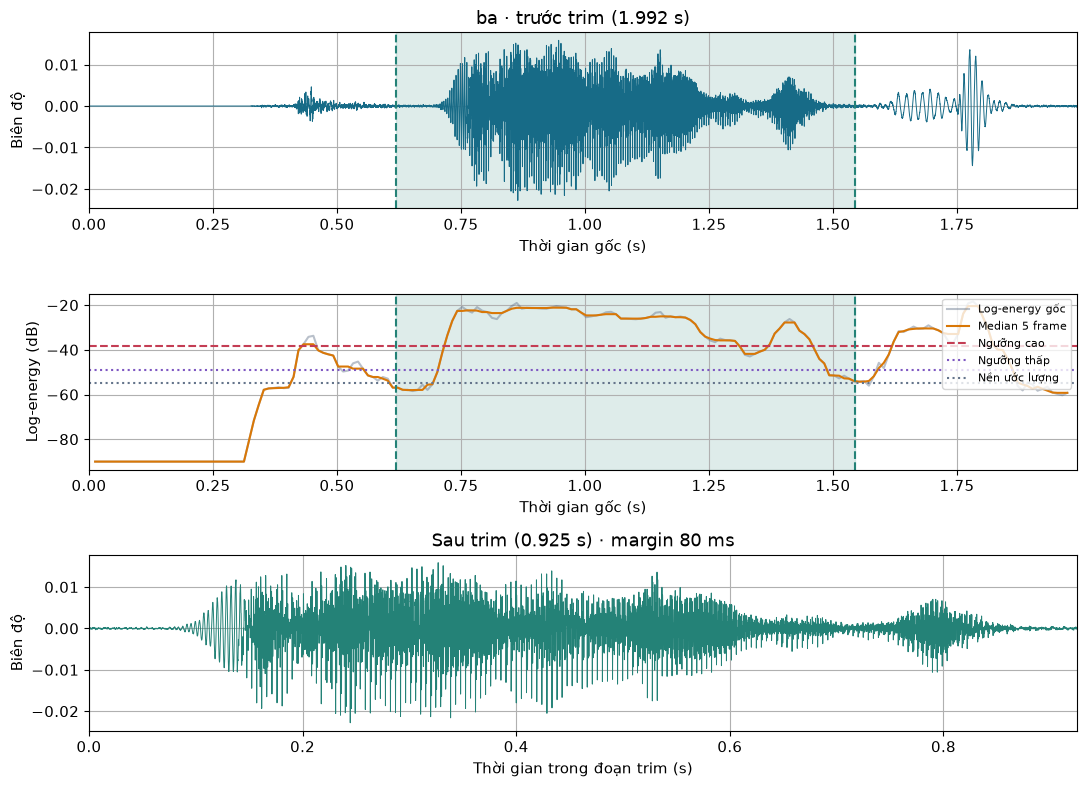

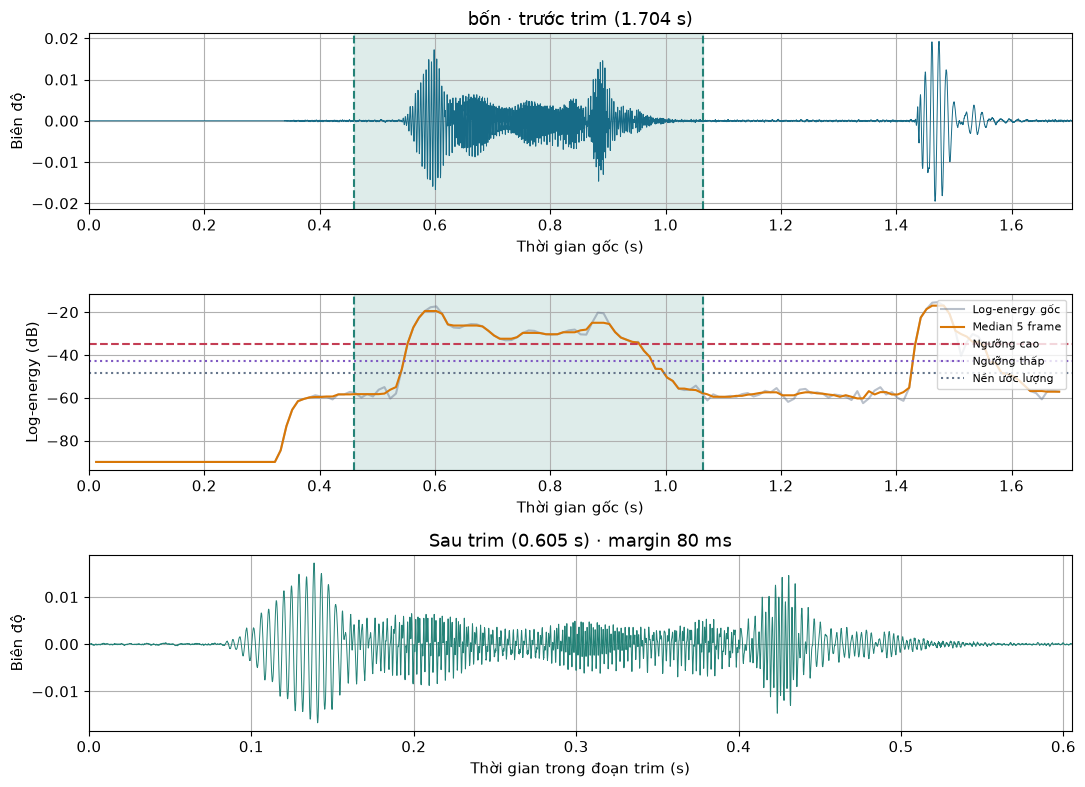

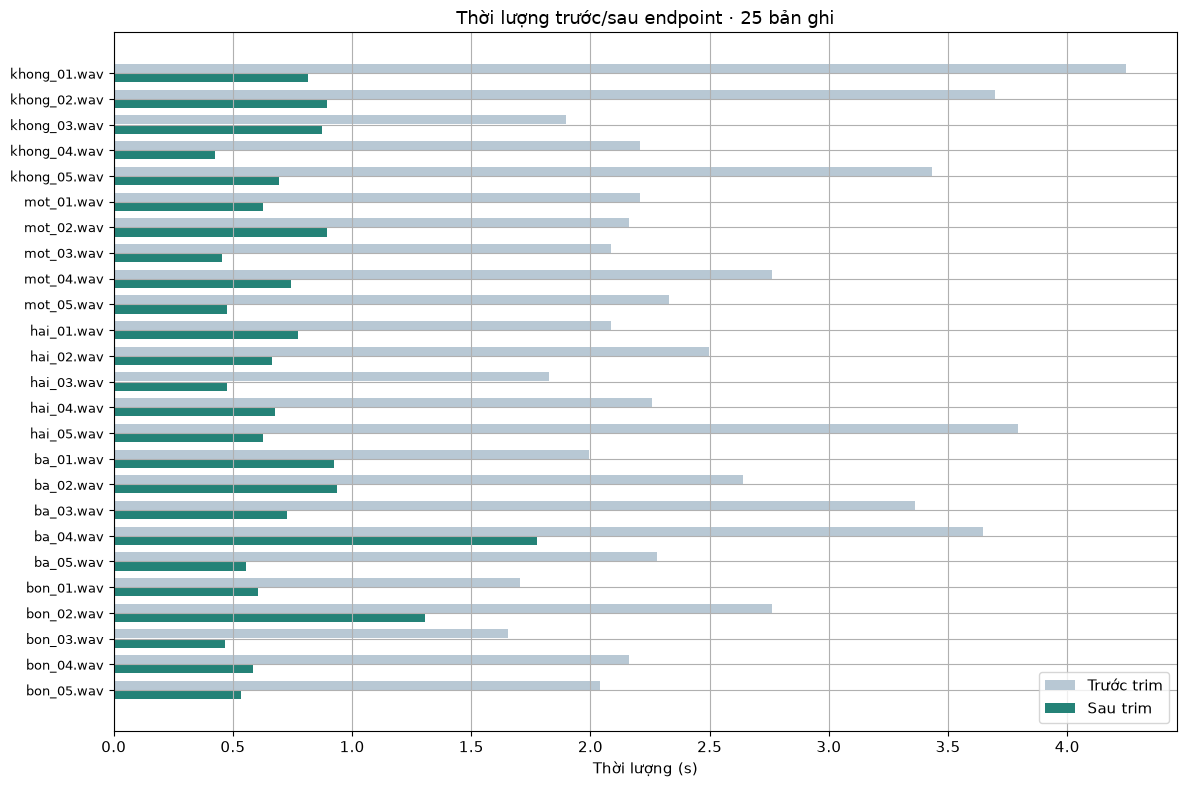

In [17]:
for label, relative in PHASE3_EXAMPLES:
    entry = TIME_ANALYSIS[relative]
    y, sr = entry["y"], entry["sr"]
    result = ENDPOINT_RESULTS[relative]
    info, cropped = result["info"], result["trimmed"]
    f = info["features"]
    start_s, end_s = info["start_sample"] / sr, info["end_sample"] / sr
    fig, axes = plt.subplots(3, 1, figsize=(11, 8))
    axes[0].plot(np.arange(len(y)) / sr, y, linewidth=0.7, color="#176b87")
    axes[0].set(title=f"{LABEL_NAMES[label]} · trước trim ({len(y)/sr:.3f} s)",
                xlabel="Thời gian gốc (s)", ylabel="Biên độ", xlim=(0, len(y)/sr))
    axes[1].plot(f["times"], f["log_energy_db"], alpha=0.45, color="#64748b", label="Log-energy gốc")
    axes[1].plot(f["times"], info["smoothed_log_energy_db"], color="#d97706", label="Median 5 frame")
    axes[1].axhline(info["high_threshold_db"], color="#c43d54", linestyle="--", label="Ngưỡng cao")
    axes[1].axhline(info["low_threshold_db"], color="#7e57c2", linestyle=":", label="Ngưỡng thấp")
    axes[1].axhline(info["noise_db"], color="#64748b", linestyle=":", label="Nền ước lượng")
    axes[1].set(xlabel="Thời gian gốc (s)", ylabel="Log-energy (dB)", xlim=(0, len(y)/sr))
    for ax in axes[:2]:
        ax.axvspan(start_s, end_s, color="#248277", alpha=0.15)
        ax.axvline(start_s, color="#248277", linestyle="--")
        ax.axvline(end_s, color="#248277", linestyle="--")
    axes[1].legend(fontsize=8, loc="upper right")
    axes[2].plot(np.arange(len(cropped)) / sr, cropped, linewidth=0.7, color="#248277")
    axes[2].set(title=f"Sau trim ({len(cropped)/sr:.3f} s) · margin {MARGIN_MS} ms",
                xlabel="Thời gian trong đoạn trim (s)", ylabel="Biên độ", xlim=(0, len(cropped)/sr))
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"phase4_endpoint_{label}.png", dpi=160,
                bbox_inches="tight", pad_inches=0.2)
    plt.show()
    plt.close(fig)

fig, ax = plt.subplots(figsize=(12, 8))
positions = np.arange(len(TRIM_ROWS))
ax.barh(positions - 0.18, [r["before_s"] for r in TRIM_ROWS], height=0.35, label="Trước trim", color="#b8c8d4")
ax.barh(positions + 0.18, [r["after_s"] for r in TRIM_ROWS], height=0.35, label="Sau trim", color="#248277")
ax.set_yticks(positions, [Path(r["file"]).name for r in TRIM_ROWS], fontsize=9)
ax.invert_yaxis()
ax.set(xlabel="Thời lượng (s)", title="Thời lượng trước/sau endpoint · 25 bản ghi")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase4_duration_comparison.png", dpi=160, bbox_inches="tight", pad_inches=0.2)
plt.show()
plt.close(fig)

### C4. Phụ âm năng lượng thấp và thử margin

Kiểm tra `khong_01.wav`: frame vô thanh/nhiễu ứng viên ở onset đã được chọn trong Phase 3. Chỉ kiểm tra xem toàn bộ frame ứng viên còn được giữ, **không khẳng định nhãn phụ âm đã được nghe/xác nhận**.

So sánh margin 0/50/80/120 ms trên cùng file training, giữ các tham số khác. Margin 80 ms tạo vùng đệm để bảo vệ biên; margin lớn hơn có thể giữ thêm nền/xung. Không chọn margin bằng accuracy tập test.

| file | margin_ms | start_s | end_s | after_s | onset_frame_time_s | full_onset_frame_kept |
| --- | --- | --- | --- | --- | --- | --- |
| khong/khong_01.wav | 0 | 1.96 | 2.615 | 0.655 | 2.03246875 | True |
| khong/khong_01.wav | 50 | 1.91 | 2.665 | 0.755 | 2.03246875 | True |
| khong/khong_01.wav | 80 | 1.88 | 2.695 | 0.815 | 2.03246875 | True |
| khong/khong_01.wav | 120 | 1.84 | 2.735 | 0.895 | 2.03246875 | True |

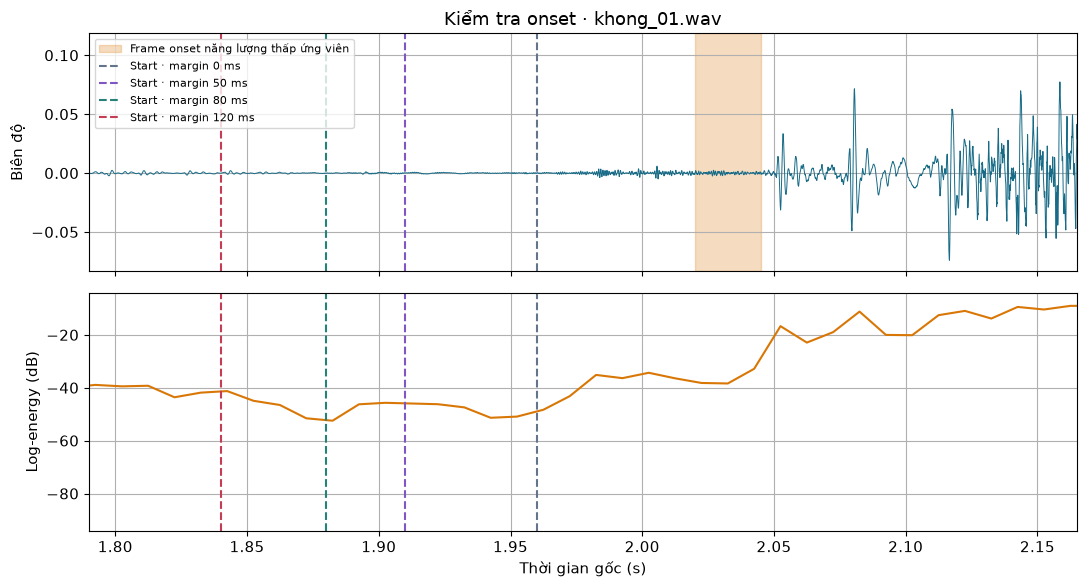

In [18]:
relative = "khong/khong_01.wav"
entry = TIME_ANALYSIS[relative]
y, sr = entry["y"], entry["sr"]
candidate = FRAME_EXAMPLES[relative]["unvoiced_candidate"]
if candidate is None:
    raise ValueError("Chưa tìm được frame onset ứng viên; cần chọn lại ví dụ bằng nghe.")
candidate_start = int(entry["features"]["starts"][candidate])
candidate_end = candidate_start + WIN
MARGIN_ROWS, MARGIN_RESULTS = [], {}
for margin in [0, 50, 80, 120]:
    config = {**ENDPOINT_CONFIG, "margin_ms": margin}
    cropped, info = trim_endpoint(y, sr, **config)
    MARGIN_RESULTS[margin] = info
    MARGIN_ROWS.append({"file": relative, "margin_ms": margin,
                        "start_s": info["start_sample"] / sr,
                        "end_s": info["end_sample"] / sr,
                        "after_s": len(cropped) / sr,
                        "onset_frame_time_s": entry["features"]["times"][candidate],
                        "full_onset_frame_kept": info["start_sample"] <= candidate_start and info["end_sample"] >= candidate_end})
show_table(MARGIN_ROWS, list(MARGIN_ROWS[0]))
write_csv(PROJECT_ROOT / "outputs/phase4_margin_comparison.csv", MARGIN_ROWS, list(MARGIN_ROWS[0]))
assert next(r for r in MARGIN_ROWS if r["margin_ms"] == MARGIN_MS)["full_onset_frame_kept"]

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
times = np.arange(len(y)) / sr
axes[0].plot(times, y, color="#176b87", linewidth=0.7)
axes[0].axvspan(candidate_start / sr, candidate_end / sr, color="#d97706", alpha=0.25,
               label="Frame onset năng lượng thấp ứng viên")
axes[1].plot(entry["features"]["times"], entry["features"]["log_energy_db"], color="#d97706")
for margin, color in zip([0, 50, 80, 120], ["#64748b", "#7e57c2", "#248277", "#c43d54"]):
    t = MARGIN_RESULTS[margin]["start_sample"] / sr
    for ax in axes:
        ax.axvline(t, color=color, linestyle="--", label=f"Start · margin {margin} ms")
axes[0].set(title="Kiểm tra onset · khong_01.wav", ylabel="Biên độ")
axes[1].set(ylabel="Log-energy (dB)", xlabel="Thời gian gốc (s)")
axes[1].set_xlim(max(0, MARGIN_RESULTS[120]["start_sample"] / sr - 0.05), candidate_end / sr + 0.12)
axes[0].legend(fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase4_weak_onset_margin.png", dpi=160, bbox_inches="tight", pad_inches=0.2)
plt.show()
plt.close(fig)

### C5. Nghe so sánh và nhận xét kỹ thuật

Hàm dưới đây phát cả file gốc và file trim. Chưa tự xác nhận bằng nghe. Ưu tiên nghe `khong_01.wav` (âm đầu năng lượng thấp), `hai_01.wav`/`bon_01.wav` (xung cuối) và các file có cảnh báo. Không kết luận “không cắt mất âm” chỉ từ việc xuất WAV thành công.

Nếu nghe thấy mất phụ âm, xem lại ngưỡng/margin hoặc vùng chính; nếu file chứa nhiều từ, cần thu lại từ đơn. Khi thay đổi cấu hình, áp dụng lại cho cả train/test và báo cáo cấu hình mới.

In [19]:
def listen_endpoint_comparison(relative_path):
    if relative_path not in ENDPOINT_RESULTS:
        raise ValueError("Chọn file đã có trong kết quả endpoint")
    display(Markdown(f"**Gốc:** {relative_path}"))
    display(Audio(filename=str(DATASET_DIR / relative_path)))
    display(Markdown(f"**Trim:** margin {MARGIN_MS} ms"))
    display(Audio(filename=str(TRIMMED_DIR / relative_path)))

# Bỏ dấu # để nghe, kiểm tra biên và xác nhận nội dung.
# listen_endpoint_comparison("khong/khong_01.wav")
# listen_endpoint_comparison("hai/hai_01.wav")
# listen_endpoint_comparison("bon/bon_01.wav")

for preview in ["khong/khong_01.wav", "hai/hai_01.wav", "bon/bon_01.wav"]:
    listen_endpoint_comparison(preview)

before = np.array([r["before_s"] for r in TRIM_ROWS])
after = np.array([r["after_s"] for r in TRIM_ROWS])
warnings_count = sum(bool(r["warnings"]) for r in TRIM_ROWS)
weak = next(r for r in MARGIN_ROWS if r["margin_ms"] == MARGIN_MS)
lines = ["# Phase 4 — Endpoint detection", "",
         f"Đã trim và kiểm tra sample của {len(TRIM_ROWS)} WAV; giữ split 15 train + 10 test.",
         f"Tổng thời lượng {before.sum():.3f} → {after.sum():.3f} s; giảm {(1-after.sum()/before.sum())*100:.2f}%.",
         f"Trung bình {before.mean():.3f} → {after.mean():.3f} s/file.",
         "", "## Cấu hình và phương pháp", "",
         "Frame 25 ms, hop 10 ms, Hamming; median log-energy 5 frame; nền median ở 200 ms đầu/cuối (bỏ frame zero số). "
         "Ngưỡng cao=max(peak-18,noise+12), thấp=max(peak-30,noise+6) dB; "
         "nối gap 40 ms, vùng chính ít nhất 120 ms, mở rộng tối đa 150 ms/phía, "
         "ZCR>=0.10 chỉ hỗ trợ khi đủ energy; margin 80 ms/phía. "
         "Có fallback theo peak khi nền đầu/cuối chứa âm mạnh; xem warning từng file.",
         "", "## Kiểm tra và nhận xét", "",
         f"- Có {warnings_count} file cảnh báo, cần nghe để kiểm tra vùng bị loại/fallback.",
         f"- khong_01.wav: frame onset ứng viên t={weak['onset_frame_time_s']:.3f} s "
         f"được giữ trọn với margin 80 ms ({weak['full_onset_frame_kept']}). Đây là kiểm tra vị trí frame, chưa xác nhận ngữ âm bằng nghe.",
         "- Các hình hai_01/bon_01 cho thấy xung cuối rời khỏi vùng tiếng nói chính; trim chọn đoạn liên tục chính thay vì giữ mọi peak.",
         "- Cả margin 0/50/80/120 ms đều giữ frame onset ứng viên; chọn 80 ms để có vùng đệm, chưa chứng minh tối ưu bằng nhãn biên hoặc accuracy.",
         "- Chọn vùng dài nhất là heuristic cho từ đơn, có thể bỏ nhầm phụ âm/vùng speech tách xa; không áp dụng trực tiếp cho nhiều từ.",
         "- Đầu ra là lát cắt nguyên mẫu WAV nguồn, không tăng gain; PCM_16 mono 16 kHz. "
         "Biên sample end exclusive; frame cuối inclusive.",
         "- Chưa xác nhận bằng nghe: cần dùng listen_endpoint_comparison cho các file cảnh báo và onset năng lượng thấp.",
         "", "## Sản phẩm", "",
         "- trimmed/<label>/*.wav: 25 WAV đã trim.",
         "- endpoint_config.json: cấu hình dùng chung cho train/test.",
         "- outputs/phase4_trim_results.csv: biên, thời lượng, ngưỡng, hash và warning.",
         "- outputs/phase4_margin_comparison.csv: margin 0/50/80/120 ms trên khong_01.",
         "- figures/phase4_endpoint_<label>.png: 5 hình kiểm tra biên.",
         "- figures/phase4_duration_comparison.png và phase4_weak_onset_margin.png.",
         "", "## Các file cần ưu tiên nghe", ""]
lines += [f"- {r['file']}: {r['warnings']}" for r in TRIM_ROWS if r["warnings"]]
PHASE4_REPORT = "\n".join(lines) + "\n"
(PROJECT_ROOT / "reports/Phase4_Endpoint_Report.md").write_text(PHASE4_REPORT, encoding="utf-8")
display(Markdown(PHASE4_REPORT))
print("Phase 4: đã xuất 25 WAV trim, bảng kết quả và 7 hình kiểm tra.")

**Gốc:** khong/khong_01.wav

**Trim:** margin 80 ms

**Gốc:** hai/hai_01.wav

**Trim:** margin 80 ms

**Gốc:** bon/bon_01.wav

**Trim:** margin 80 ms

# Phase 4 — Endpoint detection

Đã trim và kiểm tra sample của 25 WAV; giữ split 15 train + 10 test.
Tổng thời lượng 63.720 → 18.525 s; giảm 70.93%.
Trung bình 2.549 → 0.741 s/file.

## Cấu hình và phương pháp

Frame 25 ms, hop 10 ms, Hamming; median log-energy 5 frame; nền median ở 200 ms đầu/cuối (bỏ frame zero số). Ngưỡng cao=max(peak-18,noise+12), thấp=max(peak-30,noise+6) dB; nối gap 40 ms, vùng chính ít nhất 120 ms, mở rộng tối đa 150 ms/phía, ZCR>=0.10 chỉ hỗ trợ khi đủ energy; margin 80 ms/phía. Có fallback theo peak khi nền đầu/cuối chứa âm mạnh; xem warning từng file.

## Kiểm tra và nhận xét

- Có 7 file cảnh báo, cần nghe để kiểm tra vùng bị loại/fallback.
- khong_01.wav: frame onset ứng viên t=2.032 s được giữ trọn với margin 80 ms (True). Đây là kiểm tra vị trí frame, chưa xác nhận ngữ âm bằng nghe.
- Các hình hai_01/bon_01 cho thấy xung cuối rời khỏi vùng tiếng nói chính; trim chọn đoạn liên tục chính thay vì giữ mọi peak.
- Cả margin 0/50/80/120 ms đều giữ frame onset ứng viên; chọn 80 ms để có vùng đệm, chưa chứng minh tối ưu bằng nhãn biên hoặc accuracy.
- Chọn vùng dài nhất là heuristic cho từ đơn, có thể bỏ nhầm phụ âm/vùng speech tách xa; không áp dụng trực tiếp cho nhiều từ.
- Đầu ra là lát cắt nguyên mẫu WAV nguồn, không tăng gain; PCM_16 mono 16 kHz. Biên sample end exclusive; frame cuối inclusive.
- Chưa xác nhận bằng nghe: cần dùng listen_endpoint_comparison cho các file cảnh báo và onset năng lượng thấp.

## Sản phẩm

- trimmed/<label>/*.wav: 25 WAV đã trim.
- endpoint_config.json: cấu hình dùng chung cho train/test.
- outputs/phase4_trim_results.csv: biên, thời lượng, ngưỡng, hash và warning.
- outputs/phase4_margin_comparison.csv: margin 0/50/80/120 ms trên khong_01.
- figures/phase4_endpoint_<label>.png: 5 hình kiểm tra biên.
- figures/phase4_duration_comparison.png và phase4_weak_onset_margin.png.

## Các file cần ưu tiên nghe

- hai/hai_04.wav: Có vùng năng lượng khác ngoài vùng chính; cần nghe để xác nhận không phải tiếng nói
- hai/hai_05.wav: Nền đầu/cuối có thể chứa âm mạnh; dùng ngưỡng tương đối theo peak; Có vùng năng lượng khác ngoài vùng chính; cần nghe để xác nhận không phải tiếng nói
- ba/ba_01.wav: Có vùng năng lượng khác ngoài vùng chính; cần nghe để xác nhận không phải tiếng nói
- ba/ba_02.wav: Có vùng năng lượng khác ngoài vùng chính; cần nghe để xác nhận không phải tiếng nói
- bon/bon_01.wav: Có vùng năng lượng khác ngoài vùng chính; cần nghe để xác nhận không phải tiếng nói
- bon/bon_04.wav: Có vùng năng lượng khác ngoài vùng chính; cần nghe để xác nhận không phải tiếng nói
- bon/bon_05.wav: Có vùng năng lượng khác ngoài vùng chính; cần nghe để xác nhận không phải tiếng nói


Phase 4: đã xuất 25 WAV trim, bảng kết quả và 7 hình kiểm tra.


## D. MFCC — Phase 5

### D1. Pipeline và quy ước

Trích đặc trưng của **25 WAV đã trim**; giữ split 15 train/10 test và cùng tham số cho mọi file. Tiền nhấn $y[n]=x[n]-0.97x[n-1]$, mẫu đầu giữ nguyên. Chia frame **400 mẫu**, hop **160 mẫu**, nhân Hamming đối xứng; zero-pad frame lên **NFFT=512**.

$$P_r[k]=|FFT(x_r)[k]|^2/512$$

24 bộ lọc tam giác có đỉnh bằng 1 trên miền 0–8000 Hz, đặt 26 điểm biên/đỉnh cách đều theo Mel:

$$B(f)=1125\ln(1+f/700),\quad B^{-1}(b)=700(e^{b/1125}-1)$$

$$S_r[m]=\ln\left(\sum_kP_r[k]H_m[k]+10^{-9}\right)$$

DCT-II **orthonormal** của 24 log-energy, giữ 13 hệ số **C0–C12**. Hệ số chuẩn hóa DCT: C0 nhân $1/\sqrt{24}$, các hệ số còn lại nhân $\sqrt{2/24}$ so với tổng cosine; không liftering. CMN trừ mean theo thời gian của từng hệ số **trong chính utterance đó**, không gộp train/test.

**Lựa chọn triển khai:** dùng công thức Mel, log tự nhiên và power/NFFT đúng phần lý thuyết của đề; không sử dụng các mặc định Slaney/log-dB/top_db của MFCC Librosa. Đây là một triển khai MFCC được nêu rõ, vì vậy giá trị số có thể khác baseline gọi Librosa. Khi dùng DTW/thí nghiệm sau phải giữ nguyên lựa chọn này.

Mọi ma trận feature có dạng **(T, 13)**, mỗi hàng là một frame. Chỉ khi vẽ heatmap mới transpose thành (13, T). $T=1+\lfloor(N-400)/160\rfloor$, bỏ frame đuôi không đủ mẫu. NFFT=512 chỉ tăng số điểm FFT, **không đổi frame thành 512 mẫu**. Không dùng centering/padding đầu/cuối tín hiệu.

### Vai trò của các bước

- Tiền nhấn tăng tương đối thành phần biến thiên nhanh/tần số cao.
- Hamming giảm rò rỉ phổ; FFT/power mô tả phổ ngắn hạn.
- Mel phân giải dày hơn ở tần số thấp; khoảng cách Hz rộng dần ở tần số cao.
- Log nén dynamic range, chuyển tỷ lệ năng lượng thành chênh lệch cộng.
- DCT biểu diễn đường bao log-Mel bằng các hệ số cosine, giữ các hệ số bậc thấp làm biểu diễn gọn.
- CMN giảm sai khác mean giữa các utterance; không bảo đảm loại bỏ mọi khác biệt micro/người nói.

In [20]:
import lab2_mfcc
importlib.reload(lab2_mfcc)
from lab2_mfcc import hz_to_mel, mel_to_hz, mel_filterbank, mfcc_details, mfcc_feature

MFCC_CONFIG = {"frame_length": WIN, "hop_length": HOP, "n_fft": NFFT,
               "n_mels": N_MELS, "n_mfcc": N_MFCC, "alpha": ALPHA,
               "use_cmn": USE_CMN, "eps": EPS}
FEATURE_DIR = PROJECT_ROOT / "features" / "mfcc"
FEATURE_DIR.mkdir(parents=True, exist_ok=True)
MFCC_METADATA = {"sample_rate": FS, **MFCC_CONFIG,
                 "window": "symmetric Hamming", "mel_formula": "1125 * ln(1 + f/700)",
                 "mel_filter_norm": "peak triangles; no area normalization",
                 "power": "abs(rfft)^2 / n_fft", "log": "natural log(mel_energy + eps)",
                 "dct": "type 2, orthonormal", "coefficients": "C0-C12",
                 "frame_policy": "full 400-sample frames, then pad FFT to 512",
                 "feature_shape": "T x 13", "cmn": "per utterance, axis=0",
                 "endpoint_config": ENDPOINT_CONFIG,
                 "split_sha256": hashlib.sha256(SPLIT_PATH.read_bytes()).hexdigest()}
(PROJECT_ROOT / "mfcc_config.json").write_text(json.dumps(MFCC_METADATA, indent=2, ensure_ascii=False), encoding="utf-8")
show_table([{"Tham số": key, "Giá trị": value} for key, value in MFCC_CONFIG.items()], ["Tham số", "Giá trị"])

MFCC_FEATURES, MFCC_DETAILS, MFCC_ROWS = {}, {}, []
for item in SPLIT_ROWS:
    relative = item["file"]
    trimmed_path = TRIMMED_DIR / relative
    y, sr = sf.read(trimmed_path, dtype="float64")
    if sr != FS or y.ndim != 1:
        raise ValueError(f"MFCC yêu cầu mono {FS} Hz: {relative}")
    detail = mfcc_details(y, sr, **MFCC_CONFIG)
    feature = detail["mfcc"]
    expected_frames = 1 + (len(y) - WIN) // HOP
    assert feature.shape == (expected_frames, N_MFCC)
    assert np.isfinite(feature).all()
    cmn_residual = float(np.max(np.abs(feature.mean(axis=0))))
    if USE_CMN:
        assert cmn_residual < 1e-10
    MFCC_FEATURES[relative] = feature
    MFCC_DETAILS[relative] = detail
    destination = FEATURE_DIR / Path(relative).with_suffix(".npz")
    destination.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(destination, mfcc=feature, raw_mfcc=detail["raw_mfcc"],
                        log_mel=detail["log_mel"], times=detail["times"],
                        config_json=json.dumps(MFCC_METADATA, ensure_ascii=False),
                        input_sha256=hashlib.sha256(trimmed_path.read_bytes()).hexdigest())
    with np.load(destination, allow_pickle=False) as saved:
        assert np.array_equal(saved["mfcc"], feature)
    MFCC_ROWS.append({"file": relative, "label": item["label"], "split": item["split"],
                      "trimmed_duration_s": len(y) / sr, "n_frames": feature.shape[0],
                      "n_mfcc": feature.shape[1], "shape": str(feature.shape),
                      "dropped_tail_samples": int(detail["dropped_tail_samples"]),
                      "max_cmn_mean_residual": cmn_residual,
                      "feature_file": destination.relative_to(PROJECT_ROOT).as_posix(),
                      "input_sha256": hashlib.sha256(trimmed_path.read_bytes()).hexdigest()})

write_csv(PROJECT_ROOT / "outputs/phase5_mfcc_summary.csv", MFCC_ROWS, list(MFCC_ROWS[0]))
show_table(MFCC_ROWS, ["file", "split", "trimmed_duration_s", "shape", "dropped_tail_samples", "max_cmn_mean_residual"])
print(f"Đã trích và lưu MFCC cho {len(MFCC_FEATURES)} WAV; tổng {sum(r['n_frames'] for r in MFCC_ROWS)} frame.")

| Tham số | Giá trị |
| --- | --- |
| frame_length | 400 |
| hop_length | 160 |
| n_fft | 512 |
| n_mels | 24 |
| n_mfcc | 13 |
| alpha | 0.97 |
| use_cmn | True |
| eps | 1e-09 |

| file | split | trimmed_duration_s | shape | dropped_tail_samples | max_cmn_mean_residual |
| --- | --- | --- | --- | --- | --- |
| khong/khong_01.wav | train | 0.815 | (80, 13) | 0 | 4.2099657093785935e-14 |
| khong/khong_02.wav | train | 0.895 | (88, 13) | 0 | 2.90676573720041e-15 |
| khong/khong_03.wav | train | 0.875 | (86, 13) | 0 | 6.113972377470629e-15 |
| khong/khong_04.wav | test | 0.425 | (41, 13) | 0 | 2.4955647304744982e-14 |
| khong/khong_05.wav | test | 0.695 | (68, 13) | 0 | 1.5673736818237505e-14 |
| mot/mot_01.wav | train | 0.625 | (61, 13) | 0 | 2.0966834825707876e-14 |
| mot/mot_02.wav | train | 0.895 | (88, 13) | 0 | 3.270111454350461e-15 |
| mot/mot_03.wav | train | 0.455 | (44, 13) | 0 | 1.2717100100251794e-15 |
| mot/mot_04.wav | test | 0.745 | (73, 13) | 0 | 2.701035742101751e-15 |
| mot/mot_05.wav | test | 0.475 | (46, 13) | 0 | 8.032222230331567e-15 |
| hai/hai_01.wav | train | 0.775 | (76, 13) | 0 | 1.5519749228444293e-14 |
| hai/hai_02.wav | train | 0.665 | (65, 13) | 0 | 3.935313613440555e-14 |
| hai/hai_03.wav | train | 0.475 | (46, 13) | 0 | 4.325042739409306e-15 |
| hai/hai_04.wav | test | 0.675 | (66, 13) | 0 | 8.827955201867911e-15 |
| hai/hai_05.wav | test | 0.625 | (61, 13) | 0 | 1.3278995389614988e-14 |
| ba/ba_01.wav | train | 0.925 | (91, 13) | 0 | 1.4210854715202004e-14 |
| ba/ba_02.wav | train | 0.935 | (92, 13) | 0 | 3.413694447890916e-14 |
| ba/ba_03.wav | train | 0.725 | (71, 13) | 0 | 2.5619569064026148e-14 |
| ba/ba_04.wav | test | 1.775 | (176, 13) | 0 | 4.5216355912006375e-15 |
| ba/ba_05.wav | test | 0.555 | (54, 13) | 0 | 6.315935428978668e-15 |
| bon/bon_01.wav | train | 0.605 | (59, 13) | 0 | 1.25248211049238e-14 |
| bon/bon_02.wav | train | 1.305 | (129, 13) | 0 | 1.4761663037496656e-14 |
| bon/bon_03.wav | train | 0.465 | (45, 13) | 0 | 5.052748343182935e-15 |
| bon/bon_04.wav | test | 0.585 | (57, 13) | 0 | 2.991758887410948e-15 |
| bon/bon_05.wav | test | 0.535 | (52, 13) | 0 | 1.041901607725147e-15 |

Đã trích và lưu MFCC cho 25 WAV; tổng 1815 frame.


### D2. Minh họa 24 Mel filters

Các đỉnh bộ lọc cách đều trên Mel, nhưng khoảng Hz tăng dần. Tam giác được đánh giá trực tiếp trên 257 bin phổ thực của FFT 512. Không làm tròn điểm biên thành bin, không chuẩn hóa diện tích.

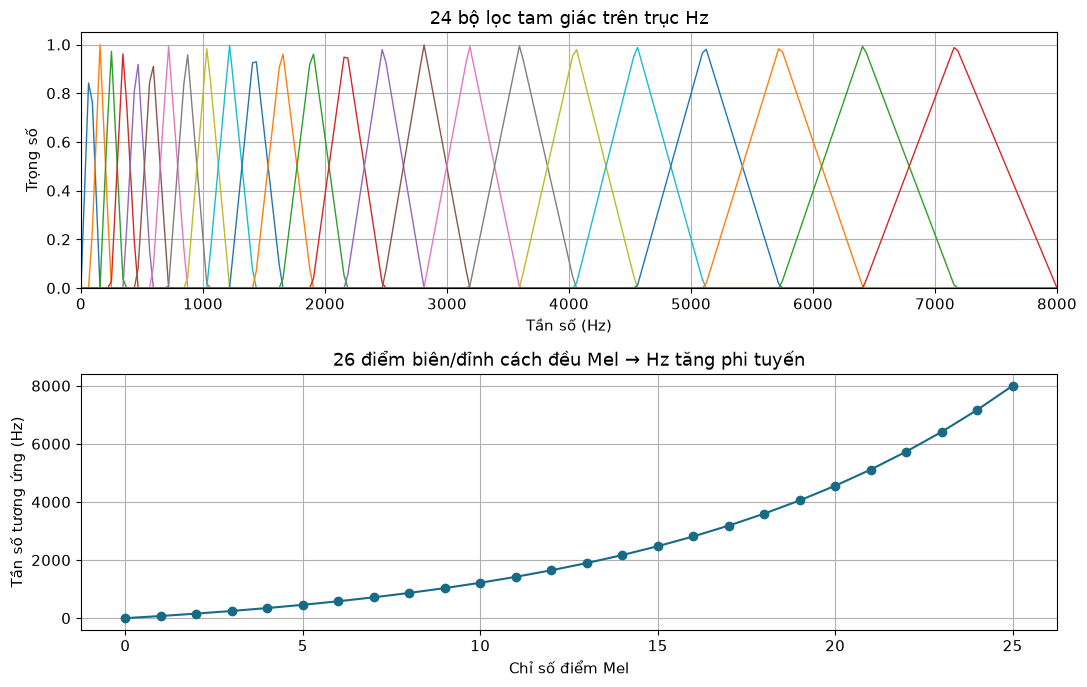

In [21]:
bank, frequencies, hz_points = mel_filterbank(FS, NFFT, N_MELS)
fig, axes = plt.subplots(2, 1, figsize=(11, 7))
for m in range(N_MELS):
    axes[0].plot(frequencies, bank[m], linewidth=1)
axes[0].set(title="24 bộ lọc tam giác trên trục Hz", xlabel="Tần số (Hz)",
            ylabel="Trọng số", xlim=(0, FS / 2), ylim=(0, 1.05))
axes[1].plot(np.arange(len(hz_points)), hz_points, "o-", color="#176b87")
axes[1].set(title="26 điểm biên/đỉnh cách đều Mel → Hz tăng phi tuyến",
            xlabel="Chỉ số điểm Mel", ylabel="Tần số tương ứng (Hz)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase5_mel_filterbank.png", dpi=160, bbox_inches="tight", pad_inches=0.2)
plt.show()
plt.close(fig)

### D3. Heatmap MFCC của 5 từ

Chọn file training `_01.wav` của từng nhãn. Trục ngang là thời gian cục bộ trong WAV trim, trục dọc C0–C12. Dùng cùng thang màu đối xứng cho 5 hình để so sánh; giới hạn bằng percentile 99 của |MFCC| trong 5 ví dụ, giá trị vượt giới hạn được bão hòa màu. Không dùng heatmap để kết luận accuracy hoặc chọn tham số trên test.

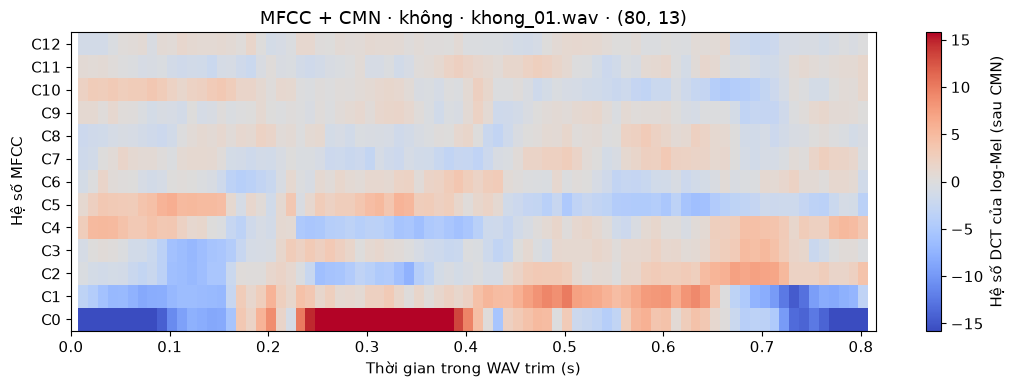

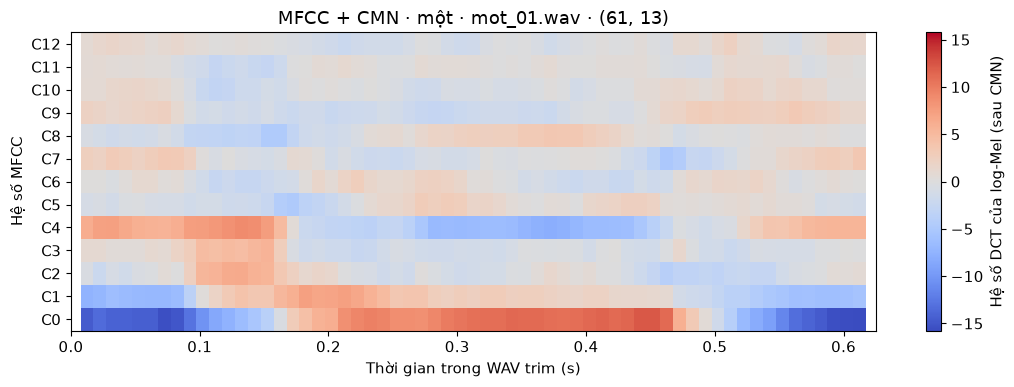

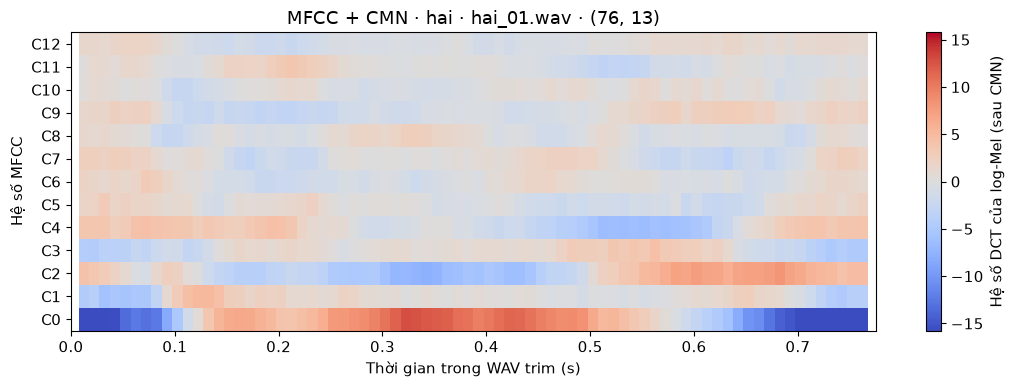

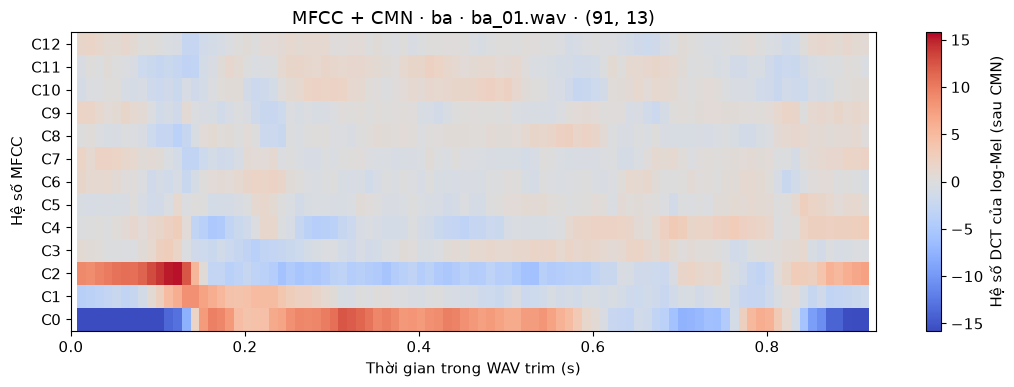

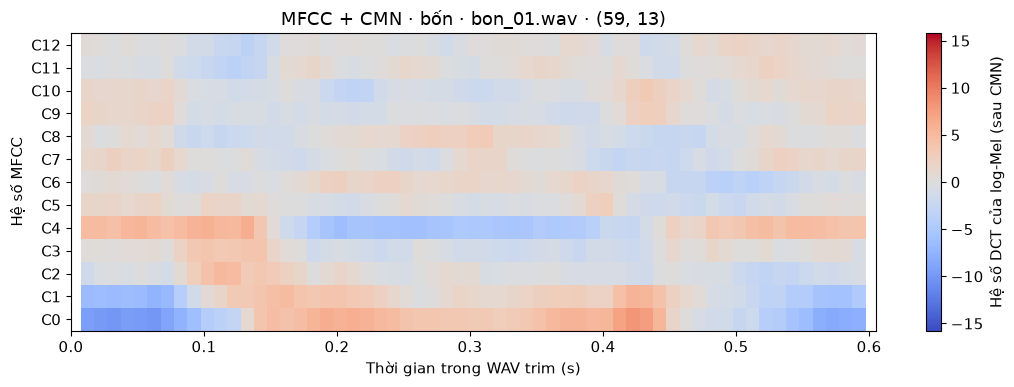

In [22]:
color_limit = max(1e-6, float(np.percentile(np.concatenate([
    np.abs(MFCC_FEATURES[relative]).ravel() for _, relative in PHASE3_EXAMPLES]), 99)))
for label, relative in PHASE3_EXAMPLES:
    detail = MFCC_DETAILS[relative]
    matrix = detail["mfcc"]
    duration = len(ENDPOINT_RESULTS[relative]["trimmed"]) / FS
    edge_left = detail["times"][0] - HOP / FS / 2
    edge_right = detail["times"][-1] + HOP / FS / 2
    fig, ax = plt.subplots(figsize=(11, 4))
    im = ax.imshow(matrix.T, origin="lower", aspect="auto", cmap="coolwarm",
                   vmin=-color_limit, vmax=color_limit,
                   extent=(edge_left, edge_right, -0.5, N_MFCC - 0.5))
    ax.set(title=f"MFCC + CMN · {LABEL_NAMES[label]} · {Path(relative).name} · {matrix.shape}",
           xlabel="Thời gian trong WAV trim (s)", ylabel="Hệ số MFCC", xlim=(0, duration))
    ax.set_yticks(np.arange(N_MFCC), [f"C{i}" for i in range(N_MFCC)])
    ax.grid(False)
    fig.colorbar(im, ax=ax, label="Hệ số DCT của log-Mel (sau CMN)")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"phase5_mfcc_{label}.png", dpi=160, bbox_inches="tight", pad_inches=0.2)
    plt.show()
    plt.close(fig)

### D4. CMN trước/sau và nhận xét

Raw MFCC và CMN được giữ riêng để kiểm tra. Với một file, lấy mean từng cột của raw MFCC rồi trừ khỏi tất cả frame; mean sau CMN gần 0 ở sai số dấu phẩy động. CMN không thay đổi số frame hay số chiều.

Hai heatmap dưới dùng thang màu riêng có colorbar để nhìn cấu trúc của từng ma trận; không so trực tiếp độ đậm màu giữa hai panel.

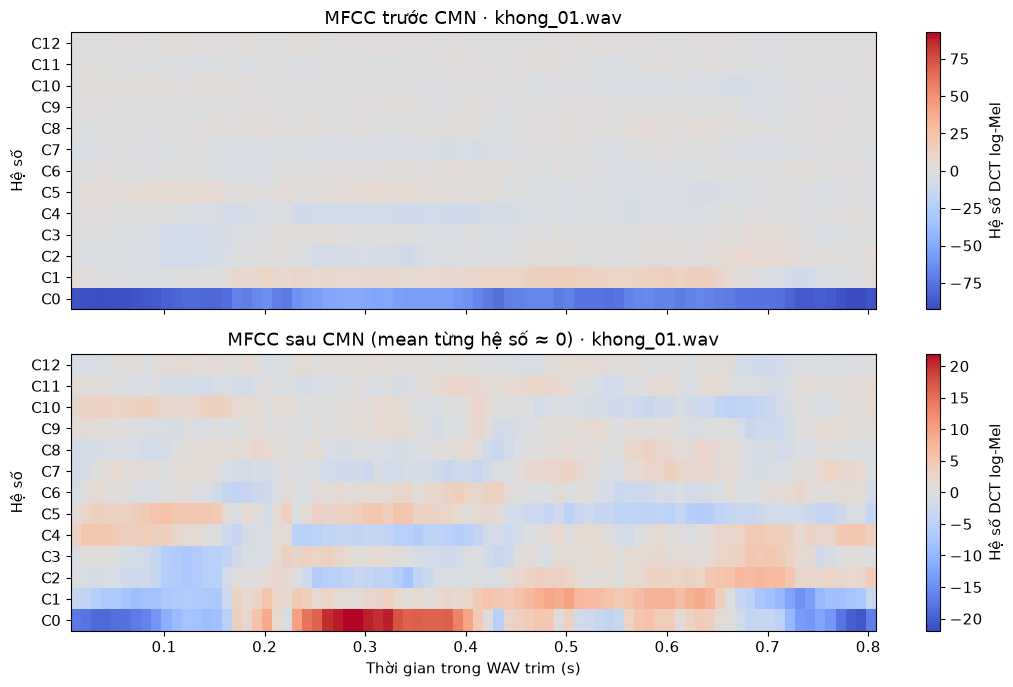

# Phase 5 — MFCC

Đã trích MFCC của 25 WAV trim; tổng 1815 frame. Mỗi ma trận (T,13), T từ 41 đến 176; split 15 train + 10 test giữ nguyên.

## Cấu hình

16 kHz; tiền nhấn alpha=0.97; frame 400 mẫu, hop 160 mẫu; Hamming đối xứng; FFT zero-pad 512; power=abs(FFT)^2/512; 24 tam giác peak-1, Mel=1125*ln(1+f/700), không chuẩn hóa diện tích; log tự nhiên với epsilon=1e-9; DCT-II orthonormal, giữ C0-C12; CMN theo utterance; không liftering.

## Quan sát

- không (khong/khong_01.wav): shape (80, 13); mean sau CMN tối đa |μ|=4.210e-14.
- một (mot/mot_01.wav): shape (61, 13); mean sau CMN tối đa |μ|=2.097e-14.
- hai (hai/hai_01.wav): shape (76, 13); mean sau CMN tối đa |μ|=1.552e-14.
- ba (ba/ba_01.wav): shape (91, 13); mean sau CMN tối đa |μ|=1.421e-14.
- bốn (bon/bon_01.wav): shape (59, 13); mean sau CMN tối đa |μ|=1.252e-14.
- Sai số mean sau CMN lớn nhất trong 25 file: 4.210e-14.
- Số frame thay đổi do thời lượng trim khác nhau; mỗi frame luôn 13 hệ số vì giữ cùng n_mfcc. Heatmap khác nhau theo thời gian và hệ số; chưa dùng để khẳng định phân loại đúng hay sai.
- Các vùng margin năng lượng thấp cũng xuất hiện trên heatmap; chất lượng endpoint ảnh hưởng các frame feature.

## Giải thích pipeline

Mel tăng mật độ phân giải ở tần số thấp. Log nén dynamic range. DCT biểu diễn log-Mel trên cơ sở cosine; 13 hệ số bậc thấp tạo biểu diễn gọn. CMN trừ mean theo từng hệ số của chính utterance, không gộp train/test.

## Khác biệt với baseline Librosa và giới hạn

Triển khai theo công thức lý thuyết của đề, dùng log tự nhiên/Mel công thức 1125ln và frame400 trước FFT512. Không dùng mặc định Slaney/log-dB/framing512 của lời gọi Librosa. Giá trị số có thể khác baseline nhưng cấu hình nhất quán cho mọi file.
Pitch không được ghép vào MFCC. Chưa thêm delta (để dành E2). Có 7 file endpoint cần kiểm tra nghe ở Phase 4; MFCC không tự sửa biên trim hoặc âm bị mất.

## Sản phẩm

- features/mfcc/<label>/*.npz: 25 file gồm MFCC, raw MFCC, log-Mel, thời gian, cấu hình và hash WAV trim.
- mfcc_config.json; outputs/phase5_mfcc_summary.csv.
- figures/phase5_mfcc_<label>.png: 5 heatmap cùng thang màu.
- phase5_mel_filterbank.png; phase5_cmn_comparison.png.
- Hàm mfcc_feature trả (T,13), sẵn sàng dùng trong DTW Phase 6.


Phase 5: đã lưu 25 ma trận MFCC, 7 hình và báo cáo.


In [23]:
relative = "khong/khong_01.wav"
detail = MFCC_DETAILS[relative]
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, matrix, title in zip(axes, [detail["raw_mfcc"], detail["mfcc"]],
                              ["MFCC trước CMN", "MFCC sau CMN (mean từng hệ số ≈ 0)"]):
    limit = max(1e-6, float(np.max(np.abs(matrix))))
    im = ax.imshow(matrix.T, origin="lower", aspect="auto", cmap="coolwarm",
                   vmin=-limit, vmax=limit,
                   extent=(detail["times"][0] - HOP / FS / 2,
                           detail["times"][-1] + HOP / FS / 2, -0.5, N_MFCC - 0.5))
    ax.set(title=f"{title} · khong_01.wav", ylabel="Hệ số")
    ax.set_yticks(range(N_MFCC), [f"C{i}" for i in range(N_MFCC)])
    ax.grid(False)
    fig.colorbar(im, ax=ax, label="Hệ số DCT log-Mel")
axes[-1].set_xlabel("Thời gian trong WAV trim (s)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase5_cmn_comparison.png", dpi=160, bbox_inches="tight", pad_inches=0.2)
plt.show()
plt.close(fig)

frames = [r["n_frames"] for r in MFCC_ROWS]
residual = max(r["max_cmn_mean_residual"] for r in MFCC_ROWS)
lines = ["# Phase 5 — MFCC", "",
         f"Đã trích MFCC của {len(MFCC_ROWS)} WAV trim; tổng {sum(frames)} frame. "
         f"Mỗi ma trận (T,13), T từ {min(frames)} đến {max(frames)}; split 15 train + 10 test giữ nguyên.",
         "", "## Cấu hình", "",
         "16 kHz; tiền nhấn alpha=0.97; frame 400 mẫu, hop 160 mẫu; Hamming đối xứng; FFT zero-pad 512; "
         "power=abs(FFT)^2/512; 24 tam giác peak-1, Mel=1125*ln(1+f/700), không chuẩn hóa diện tích; "
         "log tự nhiên với epsilon=1e-9; DCT-II orthonormal, giữ C0-C12; CMN theo utterance; không liftering.",
         "", "## Quan sát", ""]
for label, relative in PHASE3_EXAMPLES:
    matrix = MFCC_FEATURES[relative]
    lines.append(f"- {LABEL_NAMES[label]} ({relative}): shape {matrix.shape}; "
                 f"mean sau CMN tối đa |μ|={np.max(np.abs(matrix.mean(axis=0))):.3e}.")
lines += [f"- Sai số mean sau CMN lớn nhất trong 25 file: {residual:.3e}.",
          "- Số frame thay đổi do thời lượng trim khác nhau; mỗi frame luôn 13 hệ số vì giữ cùng n_mfcc. "
          "Heatmap khác nhau theo thời gian và hệ số; chưa dùng để khẳng định phân loại đúng hay sai.",
          "- Các vùng margin năng lượng thấp cũng xuất hiện trên heatmap; chất lượng endpoint ảnh hưởng các frame feature.",
          "", "## Giải thích pipeline", "",
          "Mel tăng mật độ phân giải ở tần số thấp. Log nén dynamic range. DCT biểu diễn log-Mel trên cơ sở cosine; "
          "13 hệ số bậc thấp tạo biểu diễn gọn. CMN trừ mean theo từng hệ số của chính utterance, không gộp train/test.",
          "", "## Khác biệt với baseline Librosa và giới hạn", "",
          "Triển khai theo công thức lý thuyết của đề, dùng log tự nhiên/Mel công thức 1125ln và frame400 trước FFT512. "
          "Không dùng mặc định Slaney/log-dB/framing512 của lời gọi Librosa. Giá trị số có thể khác baseline nhưng cấu hình nhất quán cho mọi file.",
          "Pitch không được ghép vào MFCC. Chưa thêm delta (để dành E2). Có 7 file endpoint cần kiểm tra nghe ở Phase 4; "
          "MFCC không tự sửa biên trim hoặc âm bị mất.",
          "", "## Sản phẩm", "",
          "- features/mfcc/<label>/*.npz: 25 file gồm MFCC, raw MFCC, log-Mel, thời gian, cấu hình và hash WAV trim.",
          "- mfcc_config.json; outputs/phase5_mfcc_summary.csv.",
          "- figures/phase5_mfcc_<label>.png: 5 heatmap cùng thang màu.",
          "- phase5_mel_filterbank.png; phase5_cmn_comparison.png.",
          "- Hàm mfcc_feature trả (T,13), sẵn sàng dùng trong DTW Phase 6."]
PHASE5_REPORT = "\n".join(lines) + "\n"
(PROJECT_ROOT / "reports/Phase5_MFCC_Report.md").write_text(PHASE5_REPORT, encoding="utf-8")
display(Markdown(PHASE5_REPORT))
print("Phase 5: đã lưu 25 ma trận MFCC, 7 hình và báo cáo.")

## E. DTW tự cài đặt — Phase 6

### E1. Local distance và quy hoạch động

Mỗi chuỗi MFCC có dạng $(N,13)$ hoặc $(M,13)$, mỗi hàng là một frame. Tự tính Euclidean local distance:

$$C[i,j]=\|X_i-Y_j\|_2=\sqrt{\sum_{q=0}^{12}(X_i[q]-Y_j[q])^2}$$

Ma trận có N hàng theo X và M cột theo Y. Khởi tạo ma trận tích lũy có padding $(N+1,M+1)$: $D[0,0]=0$, hàng/cột biên còn lại là $+\infty$. Với chỉ số padding bắt đầu từ 1:

$$D[i,j]=C[i-1,j-1]+\min\{D[i-1,j-1],D[i-1,j],D[i,j-1]\}$$

- Chéo `(1,1)`: cả hai chuỗi tiến một frame.
- Dọc `(1,0)`: X tiến, cùng frame Y được đối sánh lại.
- Ngang `(0,1)`: Y tiến, cùng frame X được đối sánh lại.

Lưu hướng tiền nhiệm; backtrack từ `(N,M)` về `(0,0)`, trả path theo chỉ số feature **0-based**: bắt đầu `(0,0)`, kết thúc `(N-1,M-1)`. Các bước đơn điệu, không nhảy frame.

$$DTW_{norm}=D[N,M]/|P|$$

$|P|$ là số **cặp frame**, không phải số bước (số bước là $|P|-1$). Tối ưu **tổng cost**, sau đó mới chia path length; không khẳng định đây là đường tối ưu cho trung bình cost. Khi tổng cost hòa chính xác, ưu tiên path ngắn hơn, rồi chéo/dọc/ngang để có kết quả xác định. Đây là lựa chọn xử lý tie của triển khai.

Không dùng thư viện DTW, không warping band hoặc giới hạn độ dốc. Độ phức tạp local distance $O(NM\cdot13)$, DP $O(NM)$ và bộ nhớ $O(NM)$; phù hợp bộ từ nhỏ.

Mã triển khai nằm trong `lab2_dtw.py`, cần nộp kèm notebook cùng các module của dự án.

In [24]:
import lab2_dtw
importlib.reload(lab2_dtw)
from lab2_dtw import local_distance_matrix, dtw_details, dtw_distance, path_statistics
from itertools import combinations

DTW_CONFIG = {"local_distance": "Euclidean", "steps": [[1, 1], [1, 0], [0, 1]],
              "boundary": "start (0,0), end (N-1,M-1)", "objective": "minimum total cost",
              "normalization": "total optimal cost / number of frame pairs",
              "tie_rule": "minimum total cost, then shorter path, then diagonal/vertical/horizontal",
              "warping_band": None, "feature_dimensions": N_MFCC,
              "feature_config": MFCC_METADATA}
(PROJECT_ROOT / "dtw_config.json").write_text(json.dumps(DTW_CONFIG, indent=2, ensure_ascii=False), encoding="utf-8")

# Ví dụ Euclidean trong đề: [1,2] và [4,6] có khoảng cách 5.
assert local_distance_matrix([[1, 2]], [[4, 6]])[0, 0] == 5
print("Local distance ví dụ = 5; ma trận MFCC giữ đúng (T,13).")

Local distance ví dụ = 5; ma trận MFCC giữ đúng (T,13).


### E2. Kiểm tra bắt buộc và kiểm tra đường đi

Đối sánh từng chuỗi với chính nó: score gần 0. Đây là kiểm tra thuật toán, **không phải accuracy nhận dạng**. Kiểm tra thêm một chuỗi feature lặp mỗi frame 2 lần để minh họa kéo giãn thời gian; đây là dữ liệu feature mô phỏng, không phải bản ghi người nói nhanh/chậm.

Đường đi phải đúng hai đầu, bước hợp lệ, path length nằm giữa max(N,M) và N+M−1; tổng local cost trên path khớp cost tích lũy. Bộ test độc lập `tests/test_lab2_dtw.py` còn liệt kê mọi path của các ma trận nhỏ để so kết quả DP và kiểm tra input lỗi.

In [25]:
def validate_dtw_path(result, n, m):
    path = np.asarray(result["path"], dtype=int)
    assert tuple(path[0]) == (0, 0) and tuple(path[-1]) == (n - 1, m - 1)
    assert max(n, m) <= len(path) <= n + m - 1
    assert np.all((0 <= path[:, 0]) & (path[:, 0] < n))
    assert np.all((0 <= path[:, 1]) & (path[:, 1] < m))
    assert all(tuple(step) in {(1, 1), (1, 0), (0, 1)} for step in np.diff(path, axis=0))
    local_sum = result["local_distance"][path[:, 0], path[:, 1]].sum()
    assert np.isclose(local_sum, result["total_cost"], atol=1e-10)
    assert np.isclose(result["normalized_cost"], result["total_cost"] / len(path))

IDENTITY_ROWS = []
for relative, feature in MFCC_FEATURES.items():
    result = dtw_details(feature, feature)
    validate_dtw_path(result, len(feature), len(feature))
    assert np.isclose(result["normalized_cost"], 0, atol=1e-12)
    assert result["path_length"] == len(feature)
    IDENTITY_ROWS.append({"file": relative, "n_frames": len(feature),
                          "dtw_self": result["normalized_cost"], "path_length": result["path_length"]})
write_csv(PROJECT_ROOT / "outputs/phase6_identity_checks.csv", IDENTITY_ROWS, list(IDENTITY_ROWS[0]))
show_table(IDENTITY_ROWS, ["file", "n_frames", "dtw_self", "path_length"])

reference = MFCC_FEATURES["khong/khong_01.wav"]
stretched = np.repeat(reference, 2, axis=0)
STRETCH_RESULT = dtw_details(reference, stretched)
validate_dtw_path(STRETCH_RESULT, len(reference), len(stretched))
assert np.isclose(STRETCH_RESULT["normalized_cost"], 0, atol=1e-12)
print(f"Kiểm tra lặp frame mô phỏng: {len(reference)} → {len(stretched)} frame, "
      f"DTW_norm={STRETCH_RESULT['normalized_cost']:.6f}, path length={STRETCH_RESULT['path_length']}.")

| file | n_frames | dtw_self | path_length |
| --- | --- | --- | --- |
| khong/khong_01.wav | 80 | 0.0 | 80 |
| khong/khong_02.wav | 88 | 0.0 | 88 |
| khong/khong_03.wav | 86 | 0.0 | 86 |
| khong/khong_04.wav | 41 | 0.0 | 41 |
| khong/khong_05.wav | 68 | 0.0 | 68 |
| mot/mot_01.wav | 61 | 0.0 | 61 |
| mot/mot_02.wav | 88 | 0.0 | 88 |
| mot/mot_03.wav | 44 | 0.0 | 44 |
| mot/mot_04.wav | 73 | 0.0 | 73 |
| mot/mot_05.wav | 46 | 0.0 | 46 |
| hai/hai_01.wav | 76 | 0.0 | 76 |
| hai/hai_02.wav | 65 | 0.0 | 65 |
| hai/hai_03.wav | 46 | 0.0 | 46 |
| hai/hai_04.wav | 66 | 0.0 | 66 |
| hai/hai_05.wav | 61 | 0.0 | 61 |
| ba/ba_01.wav | 91 | 0.0 | 91 |
| ba/ba_02.wav | 92 | 0.0 | 92 |
| ba/ba_03.wav | 71 | 0.0 | 71 |
| ba/ba_04.wav | 176 | 0.0 | 176 |
| ba/ba_05.wav | 54 | 0.0 | 54 |
| bon/bon_01.wav | 59 | 0.0 | 59 |
| bon/bon_02.wav | 129 | 0.0 | 129 |
| bon/bon_03.wav | 45 | 0.0 | 45 |
| bon/bon_04.wav | 57 | 0.0 | 57 |
| bon/bon_05.wav | 52 | 0.0 | 52 |

Kiểm tra lặp frame mô phỏng: 80 → 160 frame, DTW_norm=0.000000, path length=160.


### E3. Cùng từ và khác từ — dữ liệu thật

Chọn trước hai cặp file training, không chọn theo kết quả score:

- Cùng từ: `khong_01.wav` và `khong_02.wav`.
- Khác từ: `khong_01.wav` và `mot_01.wav`.

Lưu local-distance matrix C, accumulated-cost matrix D và optimal path riêng. Báo cáo cả tổng cost, path length, normalized cost và số bước. Độ lệch đường chéo tính bằng mean |i/(N−1) − j/(M−1)|; đường chéo tham chiếu nối hai đầu ma trận, không phải yêu cầu mọi frame phải khớp cùng chỉ số.

| type | file_x | file_y | n_frames | m_frames | total_cost | path_length | dtw_norm | diagonal_steps | vertical_steps | horizontal_steps | mean_normalized_diagonal_deviation |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| same_word | khong/khong_01.wav | khong/khong_02.wav | 80 | 88 | 914.0538785182245 | 94 | 9.723977431044942 | 73 | 6 | 14 | 0.02503010546975367 |
| different_word | khong/khong_01.wav | mot/mot_01.wav | 80 | 61 | 981.7919849894704 | 80 | 12.27239981236838 | 60 | 19 | 0 | 0.06555907172995781 |

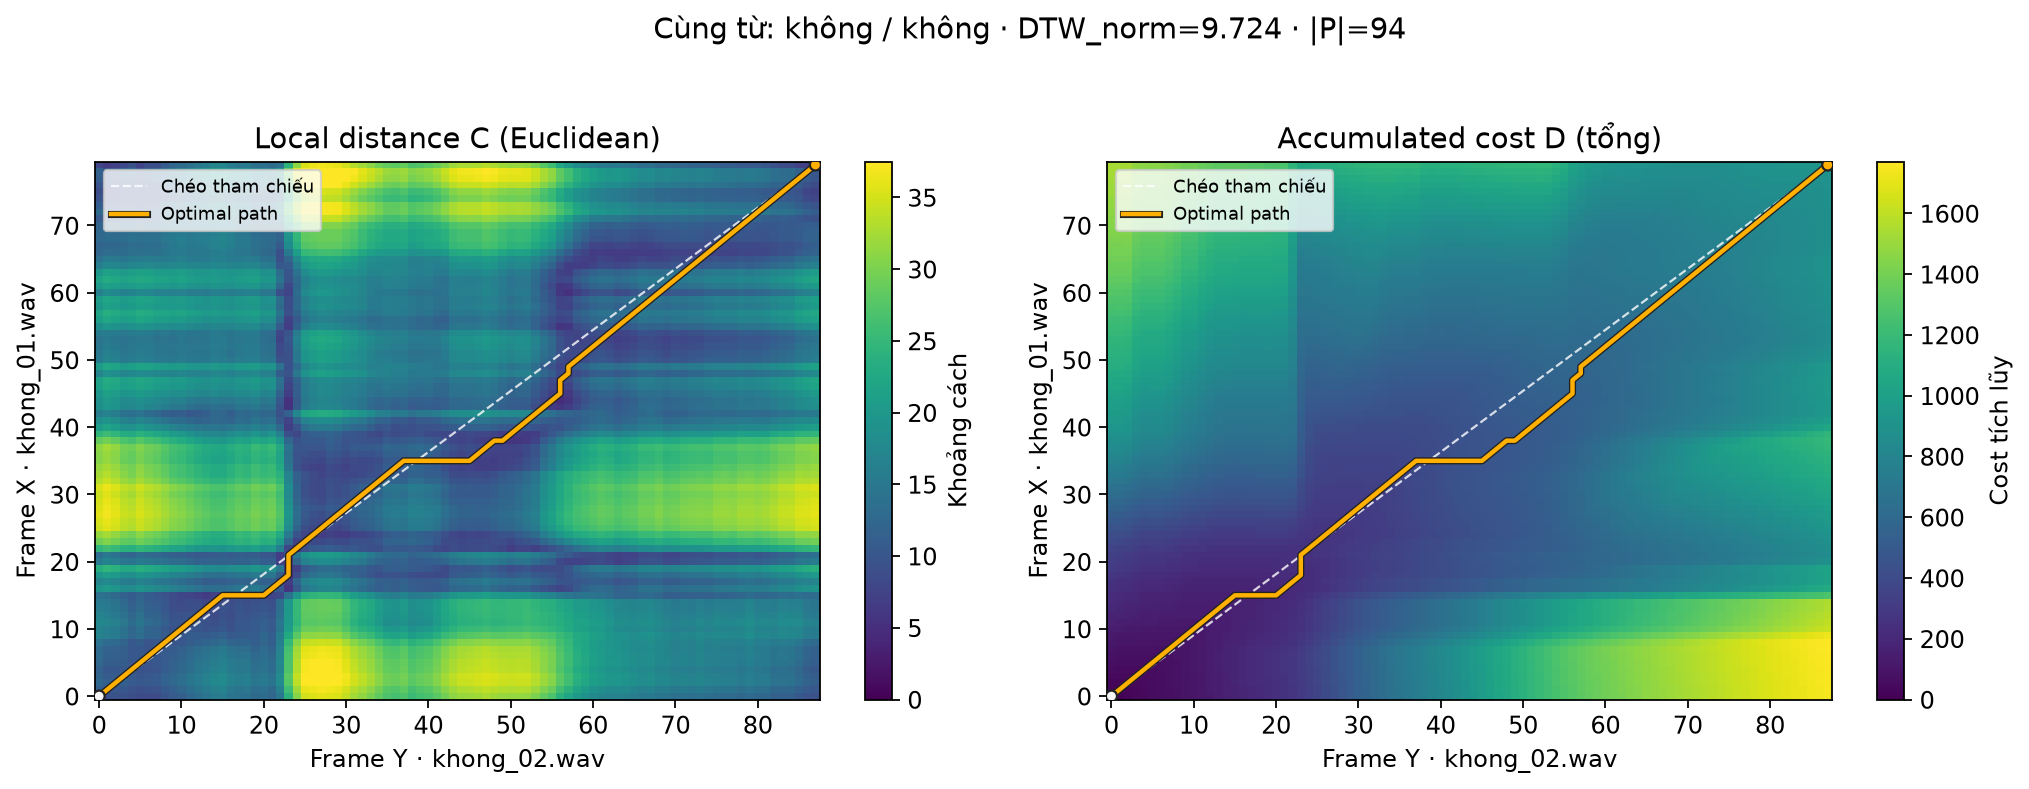

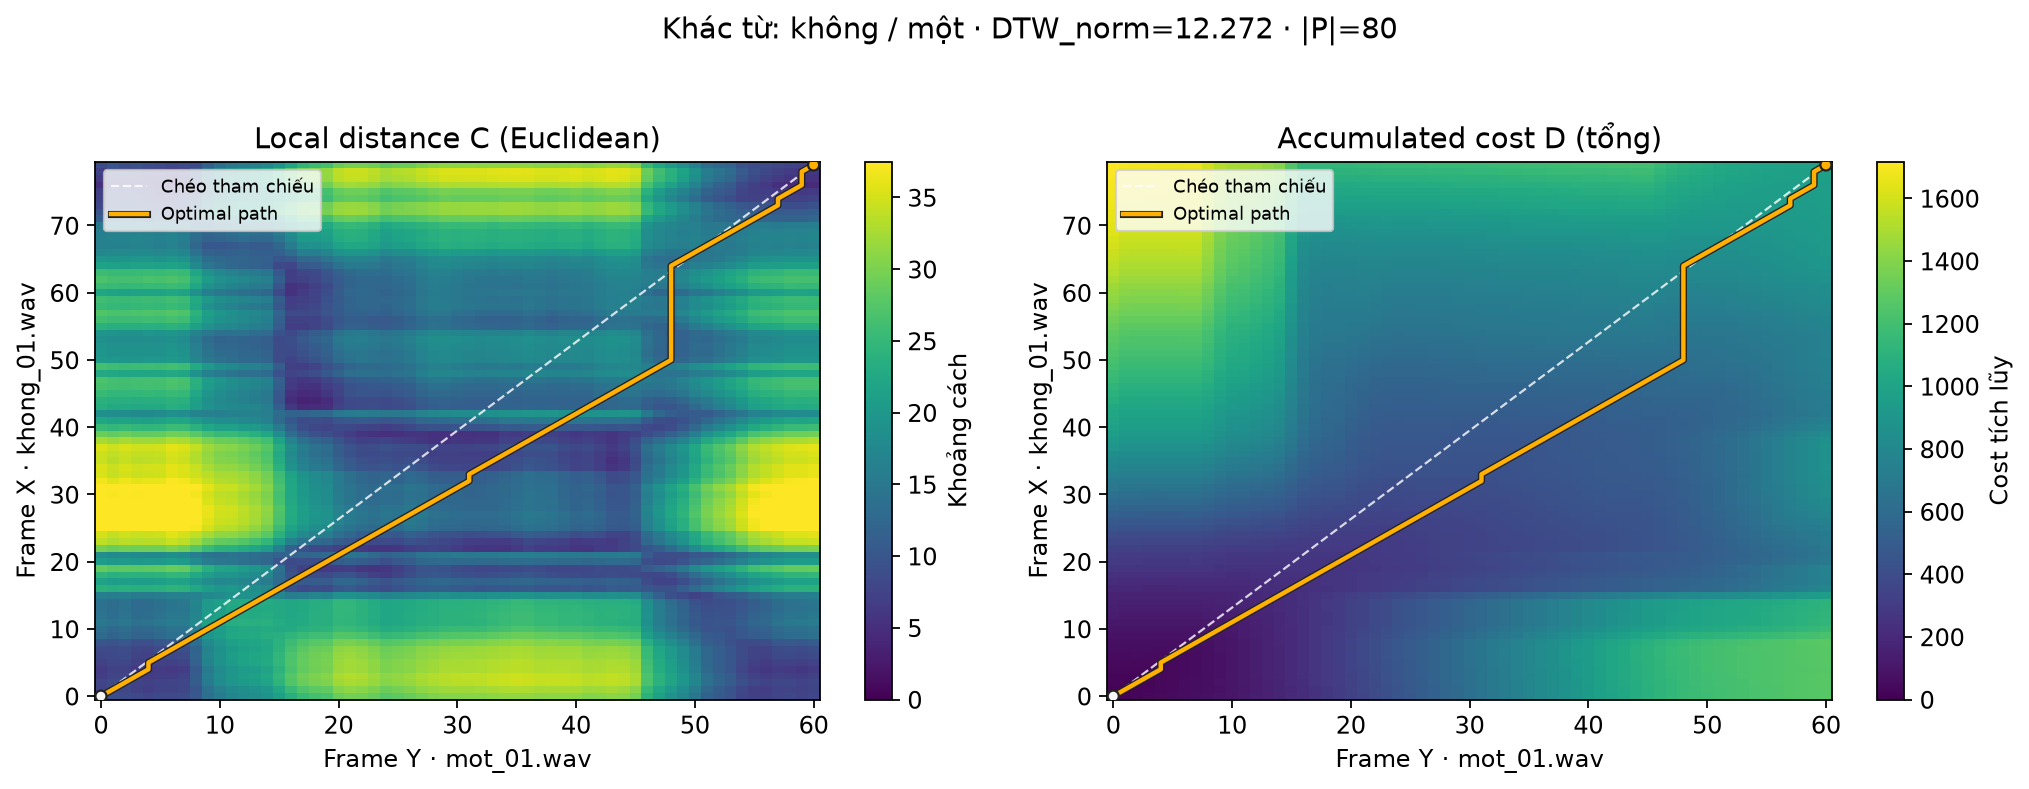

In [26]:
PAIR_SPECS = [("same_word", "Cùng từ: không / không", "khong/khong_01.wav", "khong/khong_02.wav"),
              ("different_word", "Khác từ: không / một", "khong/khong_01.wav", "mot/mot_01.wav")]
DTW_RESULT_DIR = PROJECT_ROOT / "features" / "dtw"
DTW_RESULT_DIR.mkdir(parents=True, exist_ok=True)
PAIR_RESULTS, PAIR_ROWS = {}, []
for key, description, file_x, file_y in PAIR_SPECS:
    X, Y = MFCC_FEATURES[file_x], MFCC_FEATURES[file_y]
    result = dtw_details(X, Y)
    validate_dtw_path(result, len(X), len(Y))
    PAIR_RESULTS[key] = result
    stats = path_statistics(result["path"], len(X), len(Y))
    PAIR_ROWS.append({"type": key, "file_x": file_x, "file_y": file_y,
                      "n_frames": len(X), "m_frames": len(Y),
                      "total_cost": result["total_cost"], "path_length": result["path_length"],
                      "dtw_norm": result["normalized_cost"], **stats})
    path_rows = [{"step": k, "frame_x": i, "frame_y": j,
                  "local_distance": float(result["local_distance"][i, j])}
                 for k, (i, j) in enumerate(result["path"])]
    write_csv(PROJECT_ROOT / f"outputs/phase6_path_{key}.csv", path_rows, list(path_rows[0]))
    np.savez_compressed(DTW_RESULT_DIR / f"{key}.npz", local_distance=result["local_distance"],
                        accumulated_cost=result["accumulated_cost"], path=np.asarray(result["path"]),
                        normalized_cost=result["normalized_cost"], file_x=file_x, file_y=file_y,
                        config_json=json.dumps(DTW_CONFIG, ensure_ascii=False))
write_csv(PROJECT_ROOT / "outputs/phase6_dtw_comparison.csv", PAIR_ROWS, list(PAIR_ROWS[0]))
show_table(PAIR_ROWS, ["type", "file_x", "file_y", "n_frames", "m_frames", "total_cost",
                       "path_length", "dtw_norm", "diagonal_steps", "vertical_steps", "horizontal_steps",
                       "mean_normalized_diagonal_deviation"])

from matplotlib import patheffects
local_limit = max(1e-6, float(np.percentile(np.concatenate([
    result["local_distance"].ravel() for result in PAIR_RESULTS.values()]), 99)))
for key, description, file_x, file_y in PAIR_SPECS:
    result = PAIR_RESULTS[key]
    N, M = result["local_distance"].shape
    path = np.asarray(result["path"])
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, matrix, title in zip(axes,
            [result["local_distance"], result["accumulated_cost"]],
            ["Local distance C (Euclidean)", "Accumulated cost D (tổng)"]):
        im = ax.imshow(matrix, origin="lower", aspect="auto", cmap="viridis", vmin=0,
                       vmax=local_limit if title.startswith("Local") else None)
        ax.plot([0, M - 1], [0, N - 1], "--", color="white", linewidth=1, alpha=0.8,
                label="Chéo tham chiếu")
        ax.plot(path[:, 1], path[:, 0], color="#ffb000", linewidth=2, label="Optimal path",
                path_effects=[patheffects.Stroke(linewidth=3.2, foreground="#222"), patheffects.Normal()])
        ax.scatter([0, M - 1], [0, N - 1], s=25, color=["#f7f7f7", "#ffb000"], edgecolor="#222", zorder=4)
        ax.set(title=title, xlabel=f"Frame Y · {Path(file_y).name}",
               ylabel=f"Frame X · {Path(file_x).name}")
        ax.grid(False)
        ax.legend(fontsize=8, loc="upper left")
        fig.colorbar(im, ax=ax, label="Khoảng cách" if title.startswith("Local") else "Cost tích lũy")
    fig.suptitle(f"{description} · DTW_norm={result['normalized_cost']:.3f} · |P|={result['path_length']}")
    fig.set_dpi(160)
    fig.canvas.draw()
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    fig.savefig(FIGURES_DIR / f"phase6_dtw_{key}.png", dpi=160, bbox_inches="tight", pad_inches=0.2)
    plt.show()
    plt.close(fig)

### E4. Đối chiếu thêm trên tập training

Tính các cặp không trùng trong 15 training files: **105 cặp**, gồm 15 cặp cùng nhãn và 90 cặp khác nhãn. Không dùng file test trong phần thống kê này. Mục đích là quan sát độ phân tán/chồng lấn, chưa xây dựng bộ nhận dạng và chưa chọn ngưỡng reject.

Khoảng cách cùng từ không nhất thiết nhỏ hơn mọi cặp khác từ: phát âm, tốc độ, noise, endpoint và CMN có thể làm phân bố chồng lấn.

| Nhóm | Số cặp | Min | Median | Mean | Max |
| --- | --- | --- | --- | --- | --- |
| Cùng từ | 15 | 5.085959136617491 | 6.051903116801524 | 6.76517665833517 | 12.191002736403625 |
| Khác từ | 90 | 4.9003695366036615 | 9.201021804409585 | 9.15628716985032 | 13.360865604458814 |

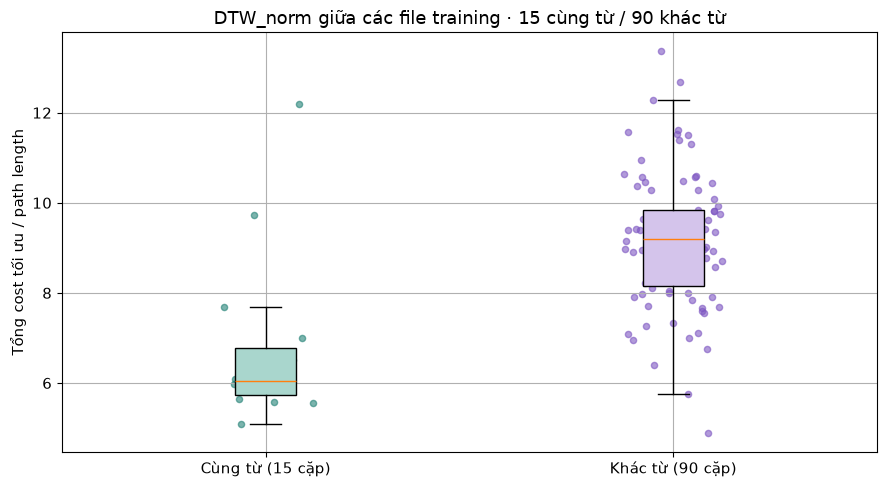

In [27]:
training_items = [item for item in SPLIT_ROWS if item["split"] == "train"]
TRAIN_PAIR_ROWS = []
for left, right in combinations(training_items, 2):
    X, Y = MFCC_FEATURES[left["file"]], MFCC_FEATURES[right["file"]]
    result = dtw_details(X, Y)
    validate_dtw_path(result, len(X), len(Y))
    TRAIN_PAIR_ROWS.append({"file_x": left["file"], "file_y": right["file"],
                            "same_label": left["label"] == right["label"],
                            "dtw_norm": result["normalized_cost"],
                            "total_cost": result["total_cost"], "path_length": result["path_length"]})
write_csv(PROJECT_ROOT / "outputs/phase6_training_pairs.csv", TRAIN_PAIR_ROWS, list(TRAIN_PAIR_ROWS[0]))
same = np.array([r["dtw_norm"] for r in TRAIN_PAIR_ROWS if r["same_label"]])
different = np.array([r["dtw_norm"] for r in TRAIN_PAIR_ROWS if not r["same_label"]])
TRAIN_GROUP_ROWS = [{"Nhóm": name, "Số cặp": len(values), "Min": float(values.min()),
                    "Median": float(np.median(values)), "Mean": float(values.mean()),
                    "Max": float(values.max())}
                   for name, values in [("Cùng từ", same), ("Khác từ", different)]]
show_table(TRAIN_GROUP_ROWS, ["Nhóm", "Số cặp", "Min", "Median", "Mean", "Max"])

fig, ax = plt.subplots(figsize=(9, 5))
box = ax.boxplot([same, different], positions=[1, 2], patch_artist=True, showfliers=False)
for patch, color in zip(box["boxes"], ["#a9d6cd", "#d4c4eb"]):
    patch.set_facecolor(color)
rng = np.random.default_rng(457)
for position, values, color in [(1, same, "#248277"), (2, different, "#7e57c2")]:
    ax.scatter(position + rng.uniform(-0.12, 0.12, len(values)), values, alpha=0.6, s=20, color=color)
ax.set_xticks([1, 2], [f"Cùng từ ({len(same)} cặp)", f"Khác từ ({len(different)} cặp)"])
ax.set(title="DTW_norm giữa các file training · 15 cùng từ / 90 khác từ",
       ylabel="Tổng cost tối ưu / path length")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase6_training_distance_distribution.png", dpi=160,
            bbox_inches="tight", pad_inches=0.2)
plt.show()
plt.close(fig)

### E5. Nhận xét và giới hạn

Các số liệu bên dưới được sinh từ kết quả thật. Diagonal path không bảo đảm nhận dạng đúng; DTW vẫn có thể căn chỉnh hai từ khác nhau. Chi phí nhỏ chỉ có ý nghĩa tương đối trong cùng cấu hình MFCC/normalization, không có ngưỡng dùng chung cho mọi người nói/micro.

Chuẩn hóa giảm thiên lệch do số cặp frame, nhưng không loại bỏ mọi ảnh hưởng thời lượng/path shape. Không band/giới hạn độ dốc nên có thể có nhiều đoạn ngang/dọc. Endpoint vẫn có 7 file cần kiểm tra nghe từ Phase 4.

In [28]:
same_row, diff_row = PAIR_ROWS
delta = diff_row["dtw_norm"] - same_row["dtw_norm"]
relative_change = delta / same_row["dtw_norm"] * 100 if same_row["dtw_norm"] > 0 else float("nan")
overlap = max(same.min(), different.min()) <= min(same.max(), different.max())
lines = ["# Phase 6 — DTW tự cài đặt", "",
         "Euclidean local distance; dynamic programming 3 bước; backtracking 0-based; cost chuẩn hóa theo số cặp frame trên path. "
         "Không gọi thư viện DTW. Khi tổng cost hòa, chọn path ngắn hơn rồi chéo/dọc/ngang; tối ưu tổng trước, chuẩn hóa sau.",
         "", "## Kiểm tra", "",
         f"- Đối sánh tự thân của {len(IDENTITY_ROWS)} MFCC đều có DTW_norm=0 và path chéo.",
         f"- Minh họa feature lặp frame 2 lần: {len(reference)} → {len(stretched)} frame; "
         f"DTW_norm={STRETCH_RESULT['normalized_cost']:.6f}. Đây là feature mô phỏng, không phải bản ghi tốc độ khác.",
         "- Kiểm tra path: hai đầu, bước đơn điệu hợp lệ, path length và tổng local cost bằng accumulated cost.",
         "- Bộ unittest độc lập đối chiếu với mọi path trên các ma trận nhỏ; kiểm tra Euclidean ví dụ, chuỗi lặp và input lỗi.",
         "", "## Hai cặp minh họa thật", ""]
for row in PAIR_ROWS:
    lines.append(f"- {row['type']}: {row['file_x']} / {row['file_y']}; "
                 f"shape ({row['n_frames']},13) / ({row['m_frames']},13); "
                 f"total={row['total_cost']:.6f}; |P|={row['path_length']}; DTW_norm={row['dtw_norm']:.6f}; "
                 f"chéo/dọc/ngang={row['diagonal_steps']}/{row['vertical_steps']}/{row['horizontal_steps']}; "
                 f"mean lệch chéo chuẩn hóa={row['mean_normalized_diagonal_deviation']:.4f}.")
lines += [f"- Cặp khác từ có DTW_norm chênh {delta:.6f} ({relative_change:.2f}%) so với cặp cùng từ đã chọn.",
          "- Cặp cùng từ có đường đi gần chéo tham chiếu hơn theo mean độ lệch; các bước ngang/dọc thể hiện kéo giãn thời gian. "
          "Đường đi khác từ vẫn tồn tại và không chứng minh hai từ giống nhau.",
          "", "## 105 cặp training", ""]
for row in TRAIN_GROUP_ROWS:
    lines.append(f"- {row['Nhóm']}: {row['Số cặp']} cặp; min={row['Min']:.3f}, "
                 f"median={row['Median']:.3f}, mean={row['Mean']:.3f}, max={row['Max']:.3f}.")
lines += [f"- Khoảng min–max của hai nhóm {'có' if overlap else 'không'} chồng lấn. "
          "Không chọn ngưỡng reject từ hai ví dụ; phần này chưa phải accuracy/confusion matrix.",
          "", "## Giới hạn và bước tiếp theo", "",
          "DTW tối ưu tổng cost rồi chia path length, không tối ưu trực tiếp trung bình cost. "
          "Không band hoặc ràng buộc độ dốc; các cost phụ thuộc pipeline MFCC và endpoint. "
          "Có 7 file endpoint cần nghe lại. Phase 7 sẽ xây nearest-template với train/test đã chốt; Phase 8 mới đánh giá accuracy.",
          "", "## Sản phẩm", "",
          "- lab2_dtw.py; tests/test_lab2_dtw.py.",
          "- dtw_config.json; outputs/phase6_identity_checks.csv; outputs/phase6_dtw_comparison.csv; outputs/phase6_training_pairs.csv.",
          "- outputs/phase6_path_same_word.csv / outputs/phase6_path_different_word.csv.",
          "- features/dtw/same_word.npz và different_word.npz chứa C, D, path và cấu hình.",
          "- figures/phase6_dtw_same_word.png, phase6_dtw_different_word.png, phase6_training_distance_distribution.png."]
PHASE6_REPORT = "\n".join(lines) + "\n"
(PROJECT_ROOT / "reports/Phase6_DTW_Report.md").write_text(PHASE6_REPORT, encoding="utf-8")
display(Markdown(PHASE6_REPORT))
print("Phase 6: DTW tự cài, kiểm tra 25 chuỗi, 2 cặp minh họa và 105 cặp training; đã lưu 3 hình và báo cáo.")

# Phase 6 — DTW tự cài đặt

Euclidean local distance; dynamic programming 3 bước; backtracking 0-based; cost chuẩn hóa theo số cặp frame trên path. Không gọi thư viện DTW. Khi tổng cost hòa, chọn path ngắn hơn rồi chéo/dọc/ngang; tối ưu tổng trước, chuẩn hóa sau.

## Kiểm tra

- Đối sánh tự thân của 25 MFCC đều có DTW_norm=0 và path chéo.
- Minh họa feature lặp frame 2 lần: 80 → 160 frame; DTW_norm=0.000000. Đây là feature mô phỏng, không phải bản ghi tốc độ khác.
- Kiểm tra path: hai đầu, bước đơn điệu hợp lệ, path length và tổng local cost bằng accumulated cost.
- Bộ unittest độc lập đối chiếu với mọi path trên các ma trận nhỏ; kiểm tra Euclidean ví dụ, chuỗi lặp và input lỗi.

## Hai cặp minh họa thật

- same_word: khong/khong_01.wav / khong/khong_02.wav; shape (80,13) / (88,13); total=914.053879; |P|=94; DTW_norm=9.723977; chéo/dọc/ngang=73/6/14; mean lệch chéo chuẩn hóa=0.0250.
- different_word: khong/khong_01.wav / mot/mot_01.wav; shape (80,13) / (61,13); total=981.791985; |P|=80; DTW_norm=12.272400; chéo/dọc/ngang=60/19/0; mean lệch chéo chuẩn hóa=0.0656.
- Cặp khác từ có DTW_norm chênh 2.548422 (26.21%) so với cặp cùng từ đã chọn.
- Cặp cùng từ có đường đi gần chéo tham chiếu hơn theo mean độ lệch; các bước ngang/dọc thể hiện kéo giãn thời gian. Đường đi khác từ vẫn tồn tại và không chứng minh hai từ giống nhau.

## 105 cặp training

- Cùng từ: 15 cặp; min=5.086, median=6.052, mean=6.765, max=12.191.
- Khác từ: 90 cặp; min=4.900, median=9.201, mean=9.156, max=13.361.
- Khoảng min–max của hai nhóm có chồng lấn. Không chọn ngưỡng reject từ hai ví dụ; phần này chưa phải accuracy/confusion matrix.

## Giới hạn và bước tiếp theo

DTW tối ưu tổng cost rồi chia path length, không tối ưu trực tiếp trung bình cost. Không band hoặc ràng buộc độ dốc; các cost phụ thuộc pipeline MFCC và endpoint. Có 7 file endpoint cần nghe lại. Phase 7 sẽ xây nearest-template với train/test đã chốt; Phase 8 mới đánh giá accuracy.

## Sản phẩm

- lab2_dtw.py; tests/test_lab2_dtw.py.
- dtw_config.json; outputs/phase6_identity_checks.csv; outputs/phase6_dtw_comparison.csv; outputs/phase6_training_pairs.csv.
- outputs/phase6_path_same_word.csv / outputs/phase6_path_different_word.csv.
- features/dtw/same_word.npz và different_word.npz chứa C, D, path và cấu hình.
- figures/phase6_dtw_same_word.png, phase6_dtw_different_word.png, phase6_training_distance_distribution.png.


Phase 6: DTW tự cài, kiểm tra 25 chuỗi, 2 cặp minh họa và 105 cặp training; đã lưu 3 hình và báo cáo.


## F. Nearest-template recognizer — Phase 7

### F1. Template bank từ train split

Tạo **15 template = 3 bản ghi × 5 nhãn**, chỉ từ các dòng `train` trong `data_split.csv`. Không lấy file test làm template. Kiểm tra hash WAV nguồn, WAV trim, split và cấu hình MFCC; tính lại feature training để đối chiếu cache Phase 5 trước khi sử dụng.

Pipeline chung cho template và query: **WAV PCM_16 mono 16 kHz → endpoint margin 80 ms → tiền nhấn → 13 MFCC + CMN → Euclidean DTW chuẩn hóa theo path length**. Query là WAV gốc, hàm tự trim đúng một lần. Không gain normalization bổ sung, không đổi tham số sau khi xem dự đoán.

Triển khai trong `lab2_recognizer.py`, có API Python và CLI độc lập notebook.

In [29]:
import lab2_recognizer
importlib.reload(lab2_recognizer)
from lab2_recognizer import NearestTemplateRecognizer

RECOGNIZER = NearestTemplateRecognizer.from_project(PROJECT_ROOT)
TEMPLATE_ROWS = [{"file": t["file"], "label": t["label"], "split": t["split"],
                  "n_frames": len(t["mfcc"]), "n_mfcc": t["mfcc"].shape[1],
                  "audio_hash": t["audio_hash"], "trimmed_sha256": t["trimmed_sha256"]}
                 for t in RECOGNIZER.templates]
assert len(TEMPLATE_ROWS) == 15
assert all(t["split"] == "train" for t in TEMPLATE_ROWS)
assert {t["file"] for t in TEMPLATE_ROWS}.isdisjoint(
    {r["file"] for r in SPLIT_ROWS if r["split"] == "test"})
write_csv(PROJECT_ROOT / "outputs/phase7_template_index.csv", TEMPLATE_ROWS, list(TEMPLATE_ROWS[0]))
show_table(TEMPLATE_ROWS, ["file", "label", "split", "n_frames", "n_mfcc"])
RECOGNIZER_CONFIG = {"method": "closed-set nearest template",
                     "label_score": "minimum normalized DTW over 3 train templates",
                     "tie_break": "score, label alphabetical, template filename alphabetical",
                     "top_k": 3, "unknown_rejection": False,
                     "query_input": "original untrimmed WAV PCM_16 mono 16000 Hz",
                     "training_files": [t["file"] for t in TEMPLATE_ROWS],
                     "mfcc": RECOGNIZER.metadata, "dtw": DTW_CONFIG}
(PROJECT_ROOT / "recognizer_config.json").write_text(
    json.dumps(RECOGNIZER_CONFIG, ensure_ascii=False, indent=2), encoding="utf-8")

| file | label | split | n_frames | n_mfcc |
| --- | --- | --- | --- | --- |
| khong/khong_01.wav | khong | train | 80 | 13 |
| khong/khong_02.wav | khong | train | 88 | 13 |
| khong/khong_03.wav | khong | train | 86 | 13 |
| mot/mot_01.wav | mot | train | 61 | 13 |
| mot/mot_02.wav | mot | train | 88 | 13 |
| mot/mot_03.wav | mot | train | 44 | 13 |
| hai/hai_01.wav | hai | train | 76 | 13 |
| hai/hai_02.wav | hai | train | 65 | 13 |
| hai/hai_03.wav | hai | train | 46 | 13 |
| ba/ba_01.wav | ba | train | 91 | 13 |
| ba/ba_02.wav | ba | train | 92 | 13 |
| ba/ba_03.wav | ba | train | 71 | 13 |
| bon/bon_01.wav | bon | train | 59 | 13 |
| bon/bon_02.wav | bon | train | 129 | 13 |
| bon/bon_03.wav | bon | train | 45 | 13 |

3346

### F2. Nhận dạng và xếp hạng theo nhãn

Với nhãn $c$, lấy điểm thấp nhất trong các template training của nhãn đó:

$$s_c(X)=\min_{T\in\mathcal T_c} DTW_{norm}(X,T),\qquad \hat c=\arg\min_c s_c(X).$$

`recognize_wav(path, top_k=3)` trả về nhãn, score, winning template, **top-3 nhãn khác nhau**, thứ hạng đủ 5 nhãn và đủ 15 template. Top-3 không phải ba template có thể trùng nhãn. Tie được xử lý cố định theo thứ tự chữ cái nhãn/tên file.

Score càng nhỏ càng gần trong cấu hình này; **không phải xác suất hoặc độ tin cậy**. `score_gap` là top-2 trừ top-1, chỉ để quan sát. Chưa có reject unknown: mọi tín hiệu qua được endpoint đều nhận một trong 5 nhãn. File training và bản sao nguyên âm thanh của nó bị từ chối khi gọi API WAV demo.

In [30]:
def recognize_lab2(wav_path, top_k=3):
    """Nhận WAV gốc; đường dẫn tương đối được tính từ thư mục dự án."""
    wav_path = Path(wav_path)
    if not wav_path.is_absolute():
        wav_path = PROJECT_ROOT / wav_path
    return RECOGNIZER.recognize_wav(wav_path, top_k=top_k)

# API trả về dữ liệu có cấu trúc, không phụ thuộc nhãn thật của query.
DEMO_FILE = "khong/khong_04.wav"
DEMO_RESULT = recognize_lab2(Path("dataset") / DEMO_FILE)
assert DEMO_FILE not in {t["file"] for t in TEMPLATE_ROWS}
display(Markdown(f"**Demo ngoài template:** `{DEMO_FILE}` — dự đoán "
                 f"**{LABEL_NAMES[DEMO_RESULT['prediction']]}**, score={DEMO_RESULT['score']:.6f}; "
                 f"template gần nhất `{DEMO_RESULT['winning_template']}`."))
show_table([{ "rank": i + 1, **r} for i, r in enumerate(DEMO_RESULT["top_k"])],
           ["rank", "label", "score", "template_file", "path_length"])
display(Markdown("**WAV query gốc (test đã chốt, chưa phải bản ghi mới):**"))
display(Audio(filename=str(DATASET_DIR / DEMO_FILE)))
display(Markdown("**Query sau endpoint:**"))
display(Audio(filename=str(TRIMMED_DIR / DEMO_FILE)))
display(Markdown("**Template gần nhất sau endpoint:**"))
display(Audio(filename=str(TRIMMED_DIR / DEMO_RESULT["winning_template"])))

**Demo ngoài template:** `khong/khong_04.wav` — dự đoán **hai**, score=6.342908; template gần nhất `hai/hai_02.wav`.

| rank | label | score | template_file | path_length |
| --- | --- | --- | --- | --- |
| 1 | hai | 6.342907860248758 | hai/hai_02.wav | 65 |
| 2 | bon | 7.098037389318213 | bon/bon_03.wav | 47 |
| 3 | khong | 7.10465833732014 | khong/khong_02.wav | 88 |

**WAV query gốc (test đã chốt, chưa phải bản ghi mới):**

**Query sau endpoint:**

**Template gần nhất sau endpoint:**

### F3. Bảng top-3 trên 10 file test

Chạy cả 10 query test gốc (đáp ứng yêu cầu ít nhất 5 file), mỗi file so với đủ 15 template. Nhãn thật chỉ thêm vào bảng **sau** nhận dạng. Đối chiếu feature query với cache Phase 5 để kiểm tra pipeline tương đương; không sử dụng nhãn thật để sửa dự đoán.

Lưu bảng top-3, toàn bộ điểm template/nhãn và JSON chi tiết. Accuracy, confusion matrix và `results.csv` sẽ thực hiện ở Phase 8.

| file | Thật | Top 1 | Top 2 | Top 3 | Template thắng |
| --- | --- | --- | --- | --- | --- |
| khong/khong_04.wav | không | hai (6.343) | bốn (7.098) | không (7.105) | hai/hai_02.wav |
| khong/khong_05.wav | không | hai (6.734) | không (6.820) | bốn (7.777) | hai/hai_02.wav |
| mot/mot_04.wav | một | một (4.742) | bốn (6.488) | ba (7.944) | mot/mot_01.wav |
| mot/mot_05.wav | một | một (4.973) | bốn (6.326) | ba (6.927) | mot/mot_03.wav |
| hai/hai_04.wav | hai | hai (5.884) | ba (8.567) | không (8.657) | hai/hai_01.wav |
| hai/hai_05.wav | hai | hai (6.146) | ba (8.224) | không (8.379) | hai/hai_03.wav |
| ba/ba_04.wav | ba | ba (5.651) | không (6.791) | hai (7.393) | ba/ba_01.wav |
| ba/ba_05.wav | ba | ba (6.895) | một (6.990) | không (7.816) | ba/ba_02.wav |
| bon/bon_04.wav | bốn | bốn (4.154) | một (7.050) | không (9.083) | bon/bon_01.wav |
| bon/bon_05.wav | bốn | bốn (8.818) | không (10.632) | một (11.102) | bon/bon_02.wav |

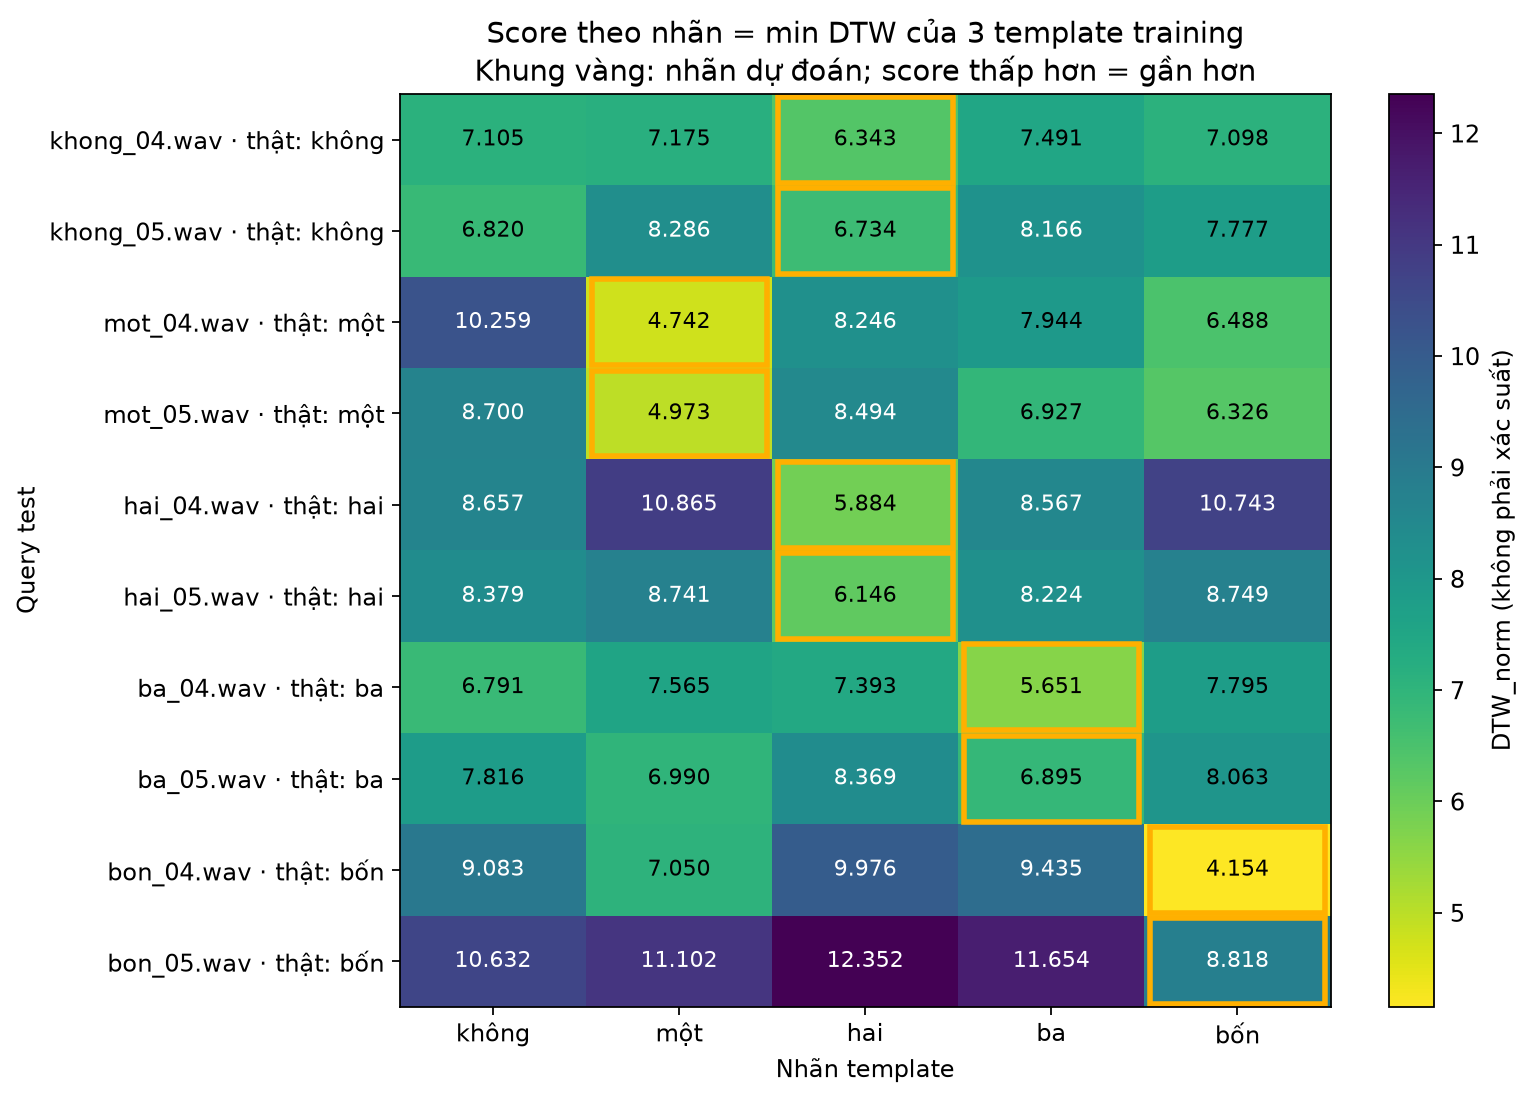

In [31]:
PHASE7_RESULTS, PREDICTION_ROWS, TEMPLATE_SCORE_ROWS, LABEL_SCORE_ROWS = {}, [], [], []
for item in [r for r in SPLIT_ROWS if r["split"] == "test"]:
    file = item["file"]
    result = DEMO_RESULT if file == DEMO_FILE else recognize_lab2(Path("dataset") / file)
    assert result["query_audio_hash"] == item["audio_hash"], f"Test WAV changed: {file}"
    assert len(result["template_ranking"]) == 15 and len(result["label_ranking"]) == 5
    assert len({r["label"] for r in result["top_k"]}) == 3
    # So sánh feature từ WAV gốc với cache đã tạo, chỉ để kiểm tra nhất quán.
    y, sr = sf.read(DATASET_DIR / file)
    segment, info = trim_endpoint(y, sr, **RECOGNIZER.endpoint_config)
    fresh = mfcc_feature(segment, sr, **RECOGNIZER.mfcc_config)
    np.testing.assert_allclose(fresh, MFCC_FEATURES[file], rtol=1e-12, atol=1e-12)
    PHASE7_RESULTS[file] = result
    row = {"file": file, "true_label": item["label"], "predicted_label": result["prediction"],
           "winning_template": result["winning_template"], "score_gap": result["score_gap"],
           "n_frames": result["n_frames"], "endpoint_warnings": "; ".join(result["endpoint_warnings"])}
    for rank, candidate in enumerate(result["top_k"], 1):
        row.update({f"top{rank}_label": candidate["label"], f"top{rank}_score": candidate["score"],
                    f"top{rank}_template": candidate["template_file"]})
    PREDICTION_ROWS.append(row)
    TEMPLATE_SCORE_ROWS.extend({"query_file": file, **r} for r in result["template_ranking"])
    LABEL_SCORE_ROWS.extend({"query_file": file, **r} for r in result["label_ranking"])
write_csv(PROJECT_ROOT / "outputs/phase7_predictions.csv", PREDICTION_ROWS, list(PREDICTION_ROWS[0]))
write_csv(PROJECT_ROOT / "outputs/phase7_template_scores.csv", TEMPLATE_SCORE_ROWS, list(TEMPLATE_SCORE_ROWS[0]))
write_csv(PROJECT_ROOT / "outputs/phase7_label_scores.csv", LABEL_SCORE_ROWS, list(LABEL_SCORE_ROWS[0]))
(PROJECT_ROOT / "outputs/phase7_recognition_details.json").write_text(
    json.dumps(PHASE7_RESULTS, ensure_ascii=False, indent=2), encoding="utf-8")
show_table([{ "file": r["file"], "Thật": LABEL_NAMES[r["true_label"]],
              **{f"Top {i}": f"{LABEL_NAMES[r[f'top{i}_label']]} ({r[f'top{i}_score']:.3f})"
                 for i in range(1, 4)}, "Template thắng": r["winning_template"]}
            for r in PREDICTION_ROWS], ["file", "Thật", "Top 1", "Top 2", "Top 3", "Template thắng"])

scores = np.array([[next(c["score"] for c in PHASE7_RESULTS[r["file"]]["label_ranking"]
                       if c["label"] == label) for label in LABELS] for r in PREDICTION_ROWS])
from matplotlib.patches import Rectangle
fig, ax = plt.subplots(figsize=(10, 7), dpi=160)
im = ax.imshow(scores, aspect="auto", cmap="viridis_r")
for i, row in enumerate(PREDICTION_ROWS):
    for j in range(len(LABELS)):
        color = "black" if im.norm(scores[i, j]) < 0.48 else "white"
        ax.text(j, i, f"{scores[i,j]:.3f}", ha="center", va="center", color=color, fontsize=10)
    winning = LABELS.index(row["predicted_label"])
    ax.add_patch(Rectangle((winning - 0.47, i - 0.47), 0.94, 0.94,
                          fill=False, edgecolor="#ffb000", linewidth=2.5))
ax.set_xticks(range(len(LABELS)), [LABEL_NAMES[label] for label in LABELS])
ax.set_yticks(range(len(PREDICTION_ROWS)),
              [f"{Path(r['file']).name} · thật: {LABEL_NAMES[r['true_label']]}" for r in PREDICTION_ROWS])
ax.set(title="Score theo nhãn = min DTW của 3 template training\nKhung vàng: nhãn dự đoán; score thấp hơn = gần hơn",
       xlabel="Nhãn template", ylabel="Query test")
ax.grid(False)
fig.colorbar(im, ax=ax, label="DTW_norm (không phải xác suất)")
fig.canvas.draw()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase7_label_scores.png", dpi=160, bbox_inches="tight", pad_inches=0.2)
plt.show()
plt.close(fig)

### F4. Dùng cho WAV khác và nhận xét

Trong notebook gọi `recognize_lab2("dataset/hai/hai_05.wav")`, hoặc thay bằng đường dẫn tuyệt đối tới WAV mới. WAV phải PCM 16-bit mono 16 kHz, chỉ một từ và có khoảng yên đầu/cuối; dùng `convert_recording` nếu cần chuyển định dạng trước. Hàm tự trim nên truyền **bản gốc**.

CLI tại thư mục dự án:

```powershell
.\.venv-lab2\Scripts\python.exe -X utf8 lab2_recognizer.py dataset/hai/hai_05.wav
```

Demo hiện dùng file test chưa nằm trong template; không giả lập một bản ghi mới. Audio player phục vụ người dùng nghe kiểm tra, chưa xác nhận nội dung/biên bằng nghe tự động. Không có ngưỡng reject được chọn từ tập test.

In [32]:
lines = ["# Phase 7 — Nearest-template recognizer", "",
         "Đã tạo 15 template training (3/nhãn), chạy 10 query test từ WAV gốc và xuất top-3 nhãn khác nhau.",
         "", "## Phương pháp và tính nhất quán", "",
         "- WAV PCM_16 mono 16 kHz → endpoint margin 80 ms → MFCC 13 + CMN → Euclidean DTW_norm.",
         "- Điểm một nhãn là min điểm của 3 template training; top-1 là nhãn có min thấp nhất.",
         "- Tie: score, thứ tự chữ cái nhãn, tên template. Có đủ ranking 15 template và 5 nhãn.",
         "- Không đưa test vào template; kiểm tra hash nguồn, split, cấu hình, trim và cache feature.",
         "- Feature của cả 10 query tính từ WAV gốc đã đối chiếu cache Phase 5 thành công.",
         "- WAV training/bản sao cùng âm thanh bị từ chối trong API WAV demo.",
         "", "## Top-3 query test", "",
         "| File | Nhãn thật | Top 1 (score) | Top 2 (score) | Top 3 (score) | Template thắng |",
         "|---|---|---|---|---|---|"]
for row in PREDICTION_ROWS:
    candidates = [f"{LABEL_NAMES[row[f'top{i}_label']]} ({row[f'top{i}_score']:.3f})" for i in range(1, 4)]
    lines.append("| " + " | ".join([row["file"], LABEL_NAMES[row["true_label"]], *candidates,
                                    row["winning_template"]]) + " |")
wrong_files = [r["file"] for r in PREDICTION_ROWS if r["predicted_label"] != r["true_label"]]
warnings_files = [r["file"] for r in PREDICTION_ROWS if r["endpoint_warnings"]]
lines += ["", "## Demo và nhận xét", "",
          f"- Demo `{DEMO_FILE}` là WAV test, không nằm trong template và không phải bản ghi mới. "
          f"Dự đoán {LABEL_NAMES[DEMO_RESULT['prediction']]} với score {DEMO_RESULT['score']:.6f}.",
          "- Các file có top-1 khác nhãn thật: " + (", ".join(wrong_files) if wrong_files else "không có") + ".",
          "- Query có cảnh báo endpoint: " + (", ".join(warnings_files) if warnings_files else "không có") + ".",
          "- Giữ nguyên kết quả nhận nhầm và baseline; chưa thay cấu hình theo dự đoán test.",
          "- Score/gap không phải xác suất hoặc confidence; phân bố cùng/khác từ có chồng lấn ở Phase 6.",
          "- Chưa reject unknown: âm ngoài 5 từ vẫn có thể bị gán một nhãn nếu endpoint chấp nhận.",
          "- Có 7 WAV cần kiểm tra nghe từ Phase 4 (gồm cả training/test). Player không thay thế xác nhận bằng nghe.",
          "- Phase 8 sẽ tính accuracy/confusion matrix và xuất results.csv; Phase 9 thực hiện E1/E2.",
          "", "## Kiểm tra và sản phẩm", "",
          "6 unittest đạt: min theo nhãn/top-3 riêng biệt, tie/input lỗi, train-only, query/cache nhất quán, "
          "từ chối training và bản sao, WAV sai định dạng/silence/cấu hình cũ.",
          "", "- lab2_recognizer.py; tests/test_lab2_recognizer.py; phần F notebook.",
          "- recognizer_config.json; outputs/phase7_template_index.csv.",
          "- outputs/phase7_predictions.csv; outputs/phase7_template_scores.csv (150 dòng); outputs/phase7_label_scores.csv (50 dòng).",
          "- outputs/phase7_recognition_details.json; figures/phase7_label_scores.png."]
PHASE7_REPORT = "\n".join(lines) + "\n"
(PROJECT_ROOT / "reports/Phase7_Recognizer_Report.md").write_text(PHASE7_REPORT, encoding="utf-8")
display(Markdown(PHASE7_REPORT))
print("Phase 7: đã tạo 15 template, nhận dạng 10 WAV test, xuất top-3, hình và báo cáo.")

# Phase 7 — Nearest-template recognizer

Đã tạo 15 template training (3/nhãn), chạy 10 query test từ WAV gốc và xuất top-3 nhãn khác nhau.

## Phương pháp và tính nhất quán

- WAV PCM_16 mono 16 kHz → endpoint margin 80 ms → MFCC 13 + CMN → Euclidean DTW_norm.
- Điểm một nhãn là min điểm của 3 template training; top-1 là nhãn có min thấp nhất.
- Tie: score, thứ tự chữ cái nhãn, tên template. Có đủ ranking 15 template và 5 nhãn.
- Không đưa test vào template; kiểm tra hash nguồn, split, cấu hình, trim và cache feature.
- Feature của cả 10 query tính từ WAV gốc đã đối chiếu cache Phase 5 thành công.
- WAV training/bản sao cùng âm thanh bị từ chối trong API WAV demo.

## Top-3 query test

| File | Nhãn thật | Top 1 (score) | Top 2 (score) | Top 3 (score) | Template thắng |
|---|---|---|---|---|---|
| khong/khong_04.wav | không | hai (6.343) | bốn (7.098) | không (7.105) | hai/hai_02.wav |
| khong/khong_05.wav | không | hai (6.734) | không (6.820) | bốn (7.777) | hai/hai_02.wav |
| mot/mot_04.wav | một | một (4.742) | bốn (6.488) | ba (7.944) | mot/mot_01.wav |
| mot/mot_05.wav | một | một (4.973) | bốn (6.326) | ba (6.927) | mot/mot_03.wav |
| hai/hai_04.wav | hai | hai (5.884) | ba (8.567) | không (8.657) | hai/hai_01.wav |
| hai/hai_05.wav | hai | hai (6.146) | ba (8.224) | không (8.379) | hai/hai_03.wav |
| ba/ba_04.wav | ba | ba (5.651) | không (6.791) | hai (7.393) | ba/ba_01.wav |
| ba/ba_05.wav | ba | ba (6.895) | một (6.990) | không (7.816) | ba/ba_02.wav |
| bon/bon_04.wav | bốn | bốn (4.154) | một (7.050) | không (9.083) | bon/bon_01.wav |
| bon/bon_05.wav | bốn | bốn (8.818) | không (10.632) | một (11.102) | bon/bon_02.wav |

## Demo và nhận xét

- Demo `khong/khong_04.wav` là WAV test, không nằm trong template và không phải bản ghi mới. Dự đoán hai với score 6.342908.
- Các file có top-1 khác nhãn thật: khong/khong_04.wav, khong/khong_05.wav.
- Query có cảnh báo endpoint: hai/hai_04.wav, hai/hai_05.wav, bon/bon_04.wav, bon/bon_05.wav.
- Giữ nguyên kết quả nhận nhầm và baseline; chưa thay cấu hình theo dự đoán test.
- Score/gap không phải xác suất hoặc confidence; phân bố cùng/khác từ có chồng lấn ở Phase 6.
- Chưa reject unknown: âm ngoài 5 từ vẫn có thể bị gán một nhãn nếu endpoint chấp nhận.
- Có 7 WAV cần kiểm tra nghe từ Phase 4 (gồm cả training/test). Player không thay thế xác nhận bằng nghe.
- Phase 8 sẽ tính accuracy/confusion matrix và xuất results.csv; Phase 9 thực hiện E1/E2.

## Kiểm tra và sản phẩm

6 unittest đạt: min theo nhãn/top-3 riêng biệt, tie/input lỗi, train-only, query/cache nhất quán, từ chối training và bản sao, WAV sai định dạng/silence/cấu hình cũ.

- lab2_recognizer.py; tests/test_lab2_recognizer.py; phần F notebook.
- recognizer_config.json; outputs/phase7_template_index.csv.
- outputs/phase7_predictions.csv; outputs/phase7_template_scores.csv (150 dòng); outputs/phase7_label_scores.csv (50 dòng).
- outputs/phase7_recognition_details.json; figures/phase7_label_scores.png.


Phase 7: đã tạo 15 template, nhận dạng 10 WAV test, xuất top-3, hình và báo cáo.


## G. Đánh giá và thí nghiệm — Phase 8–9

### G1. Đánh giá baseline trên toàn bộ test — Phase 8

Dùng **toàn bộ 10 file test** đã chốt (2/nhãn), so với 15 template training (3/nhãn). Giữ nguyên endpoint, MFCC, CMN, DTW và quy tắc min theo nhãn của Phase 7. Không chọn ngưỡng hoặc thay tham số dựa vào test.

`lab2_evaluation.py` kiểm tra đủ mọi query test, hash WAV và không có train/test trùng nhau. Trong Run All, dùng kết quả nhận dạng vừa tính ở phần F; CLI đánh giá độc lập sẽ tính lại từ WAV gốc. Nhãn thật chỉ tham gia tính chỉ số sau khi nhận dạng.

$$Accuracy=\frac{\text{số file có top-1 đúng}}{\text{tổng số file test}}.$$

Top-2/top-3 là chỉ số bổ sung: nhãn thật có xuất hiện trong 2/3 nhãn đứng đầu hay không; không thay thế top-1 accuracy.

In [33]:
import lab2_evaluation
importlib.reload(lab2_evaluation)
from lab2_evaluation import summarize_results, evaluate_test_set, save_evaluation

EVAL_ROWS, EVAL_METRICS = evaluate_test_set(RECOGNIZER, PHASE7_RESULTS)
assert len(EVAL_ROWS) == 10 and EVAL_METRICS["n_templates"] == 15
assert {r["file"] for r in EVAL_ROWS} == {r["file"] for r in SPLIT_ROWS if r["split"] == "test"}
assert EVAL_METRICS["split_sha256"] == MFCC_METADATA["split_sha256"]
save_evaluation(PROJECT_ROOT, EVAL_ROWS, EVAL_METRICS)
cm = np.array(EVAL_METRICS["confusion_matrix"])
cm_normalized = np.array(EVAL_METRICS["confusion_matrix_row_normalized"])
# Kiểm tra độc lập với metrics: đếm từng cặp nhãn trực tiếp.
manual_cm = np.zeros((len(LABELS), len(LABELS)), dtype=int)
for row in EVAL_ROWS:
    manual_cm[LABELS.index(row["true_label"]), LABELS.index(row["predicted_label"])] += 1
np.testing.assert_array_equal(cm, manual_cm)
assert sum(r["correct"] for r in EVAL_ROWS) == EVAL_METRICS["n_correct"] == int(np.trace(cm))

METRIC_ROWS = [{"Chỉ số": f"Top-{k}", "Đúng": EVAL_METRICS["top_k_correct"][str(k)],
                "Tổng": EVAL_METRICS["n_test"],
                "Tỷ lệ": f"{EVAL_METRICS['top_k_accuracy'][str(k)]:.1%}"} for k in (1, 2, 3)]
show_table(METRIC_ROWS, ["Chỉ số", "Đúng", "Tổng", "Tỷ lệ"])
show_table([{**r, "top1_score": f"{r['top1_score']:.6f}",
                   "top2_score": f"{r['top2_score']:.6f}"} for r in EVAL_ROWS],
           ["file", "true_label", "predicted_label", "correct", "top1_score", "top2_label", "top2_score"])
print(f"Accuracy = {EVAL_METRICS['n_correct']}/{EVAL_METRICS['n_test']} = {EVAL_METRICS['accuracy']:.1%}")
print("Đã xuất results.csv, confusion matrix CSV, per-label metrics và JSON/provenance.")

| Chỉ số | Đúng | Tổng | Tỷ lệ |
| --- | --- | --- | --- |
| Top-1 | 8 | 10 | 80.0% |
| Top-2 | 9 | 10 | 90.0% |
| Top-3 | 10 | 10 | 100.0% |

| file | true_label | predicted_label | correct | top1_score | top2_label | top2_score |
| --- | --- | --- | --- | --- | --- | --- |
| khong/khong_04.wav | khong | hai | False | 6.342908 | bon | 7.098037 |
| khong/khong_05.wav | khong | hai | False | 6.734468 | khong | 6.819653 |
| mot/mot_04.wav | mot | mot | True | 4.742080 | bon | 6.487584 |
| mot/mot_05.wav | mot | mot | True | 4.973202 | bon | 6.326160 |
| hai/hai_04.wav | hai | hai | True | 5.883988 | ba | 8.566785 |
| hai/hai_05.wav | hai | hai | True | 6.146397 | ba | 8.224426 |
| ba/ba_04.wav | ba | ba | True | 5.651277 | khong | 6.791415 |
| ba/ba_05.wav | ba | ba | True | 6.894793 | mot | 6.990430 |
| bon/bon_04.wav | bon | bon | True | 4.153889 | mot | 7.049856 |
| bon/bon_05.wav | bon | bon | True | 8.818120 | khong | 10.632111 |

Accuracy = 8/10 = 80.0%
Đã xuất results.csv, confusion matrix CSV, per-label metrics và JSON/provenance.


### G2. Confusion matrix và kết quả theo nhãn

**Hàng là nhãn thật, cột là nhãn dự đoán**, thứ tự cố định: không, một, hai, ba, bốn. Matrix bên trái là số file; bên phải chia mỗi hàng cho số test của nhãn thật. Đường chéo thể hiện nhận đúng.

Recall của một nhãn là số file nhận đúng / số file test thật của nhãn đó. Precision là số dự đoán đúng / số lần dự đoán nhãn đó. Khi không có dự đoán cho một nhãn, precision được ghi 0 (`zero_division=0`), không suy ra rằng đã quan sát nhiều dự đoán sai.

| Nhãn | Test | Đúng | Precision | Recall | F1 |
| --- | --- | --- | --- | --- | --- |
| không | 2 | 0 | 0.000 | 0.000 | 0.000 |
| một | 2 | 2 | 1.000 | 1.000 | 1.000 |
| hai | 2 | 2 | 0.500 | 1.000 | 0.667 |
| ba | 2 | 2 | 1.000 | 1.000 | 1.000 |
| bốn | 2 | 2 | 1.000 | 1.000 | 1.000 |

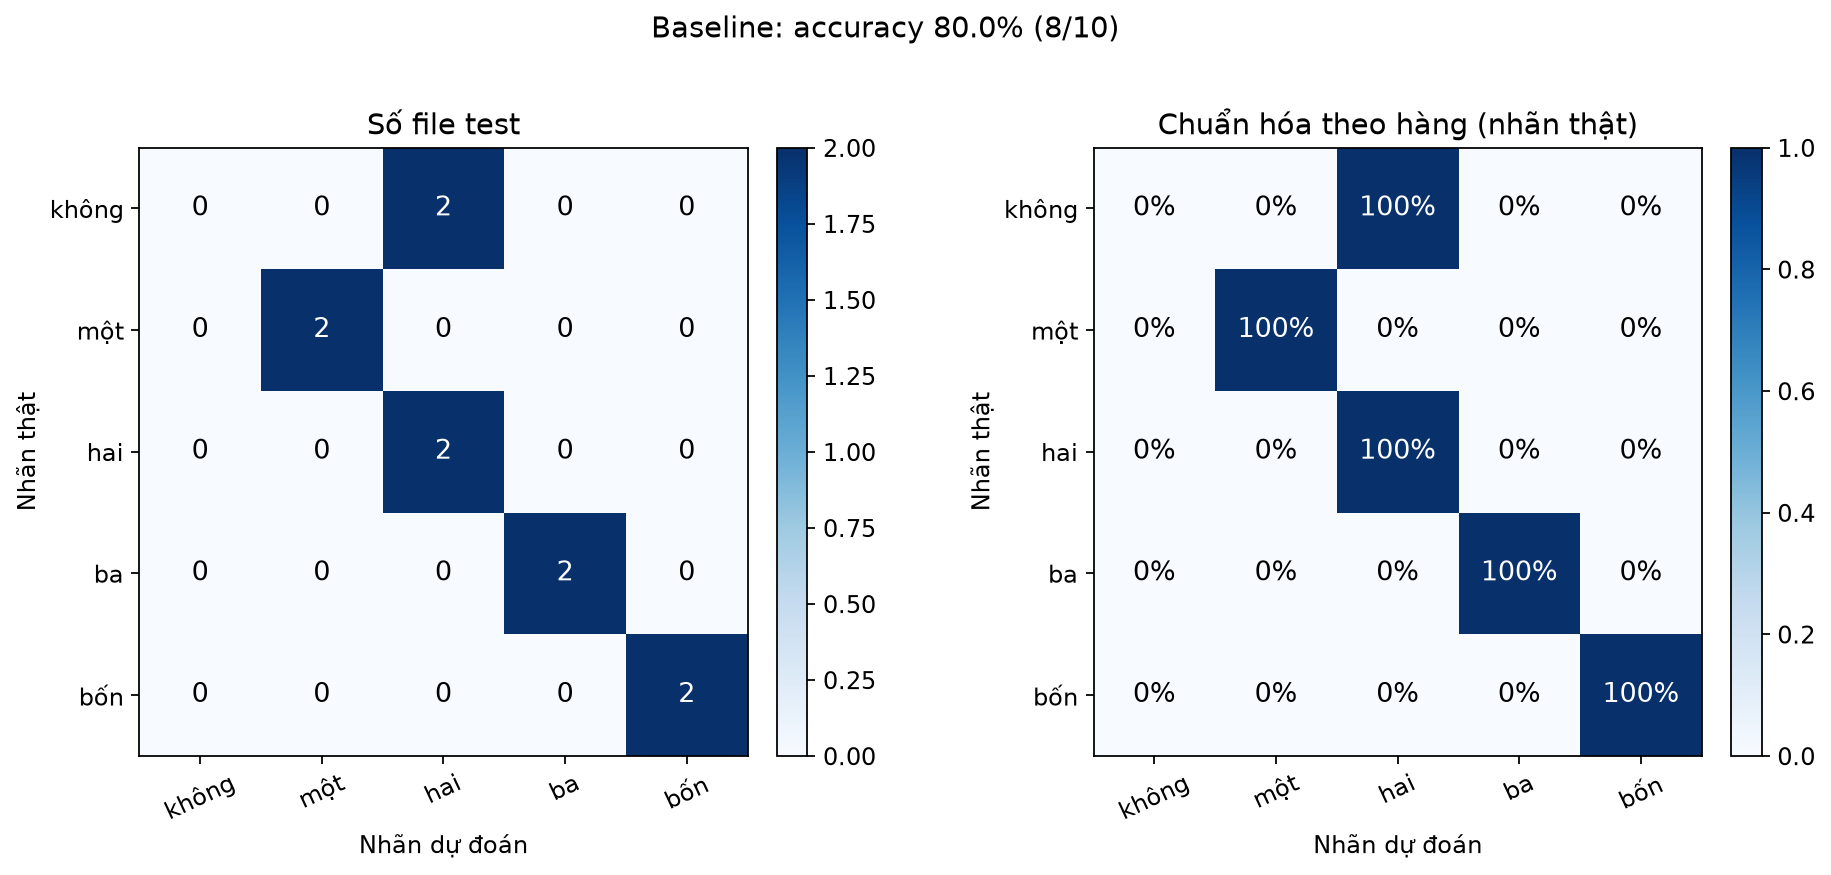

In [34]:
PER_LABEL_DISPLAY = [{"Nhãn": LABEL_NAMES[r["label"]], "Test": r["support"], "Đúng": r["correct"],
                      "Precision": f"{r['precision']:.3f}", "Recall": f"{r['recall']:.3f}",
                      "F1": f"{r['f1']:.3f}"} for r in EVAL_METRICS["per_label"]]
show_table(PER_LABEL_DISPLAY, ["Nhãn", "Test", "Đúng", "Precision", "Recall", "F1"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5.4), dpi=160)
names = [LABEL_NAMES[label] for label in LABELS]
for ax, matrix, normalized in zip(axes, [cm, cm_normalized], [False, True]):
    im = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=1 if normalized else max(1, cm.max()))
    for i in range(len(LABELS)):
        for j in range(len(LABELS)):
            text = f"{matrix[i,j]:.0%}" if normalized else str(matrix[i,j])
            color = "white" if matrix[i,j] > (0.5 if normalized else cm.max()/2) else "black"
            ax.text(j, i, text, ha="center", va="center", color=color, fontsize=12)
    ax.set_xticks(range(len(LABELS)), names, rotation=25)
    ax.set_yticks(range(len(LABELS)), names)
    ax.set(title="Chuẩn hóa theo hàng (nhãn thật)" if normalized else "Số file test",
           xlabel="Nhãn dự đoán", ylabel="Nhãn thật")
    ax.grid(False)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(f"Baseline: accuracy {EVAL_METRICS['accuracy']:.1%} ({EVAL_METRICS['n_correct']}/{EVAL_METRICS['n_test']})")
fig.canvas.draw()
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(FIGURES_DIR / "phase8_confusion_matrix.png", dpi=160, bbox_inches="tight", pad_inches=0.2)
plt.show()
plt.close(fig)

### G3. Phân tích các trường hợp nhận nhầm

Lấy **mọi lỗi top-1** từ kết quả, không chọn lại split hoặc template để cải thiện accuracy. Với mỗi query, đối chiếu ba bản ghi: query, template thắng của nhãn dự đoán sai, và template có DTW thấp nhất trong nhãn thật.

Vẽ waveform gốc/trim, ba heatmap MFCC cùng thang màu, local/accumulated cost và path của hai phép đối sánh. Lưu path để kiểm tra tổng local cost. Một đường đi DTW hợp lệ vẫn có thể nối hai từ khác nhau.

Các nguyên nhân nêu ở cuối là giả thuyết cần kiểm tra nghe/thí nghiệm, không phải kết luận phụ âm đã bị cắt hoặc nhãn dữ liệu sai.

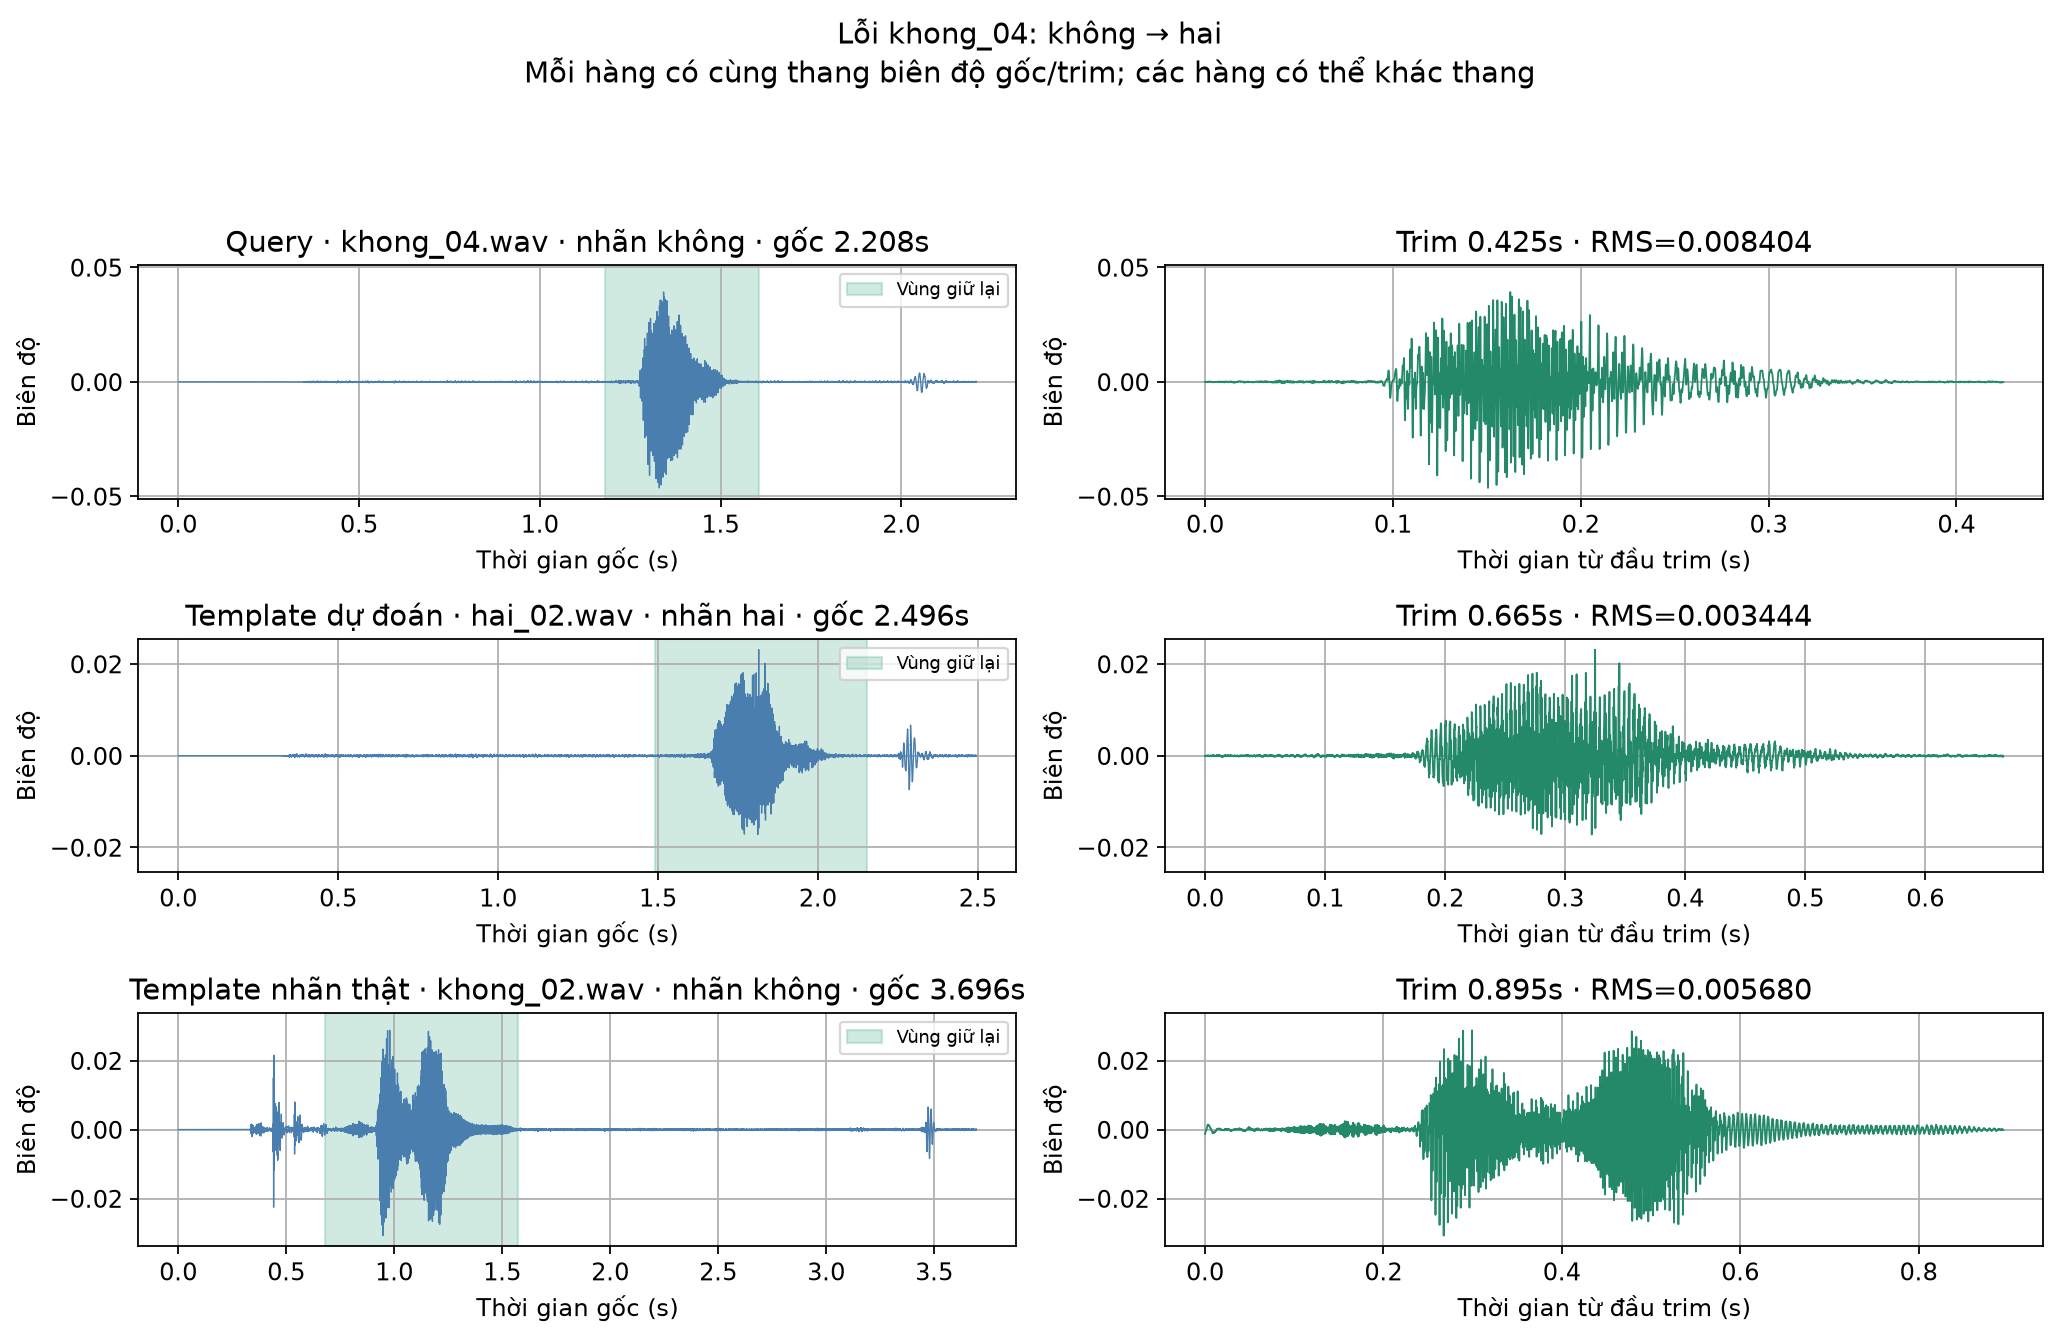

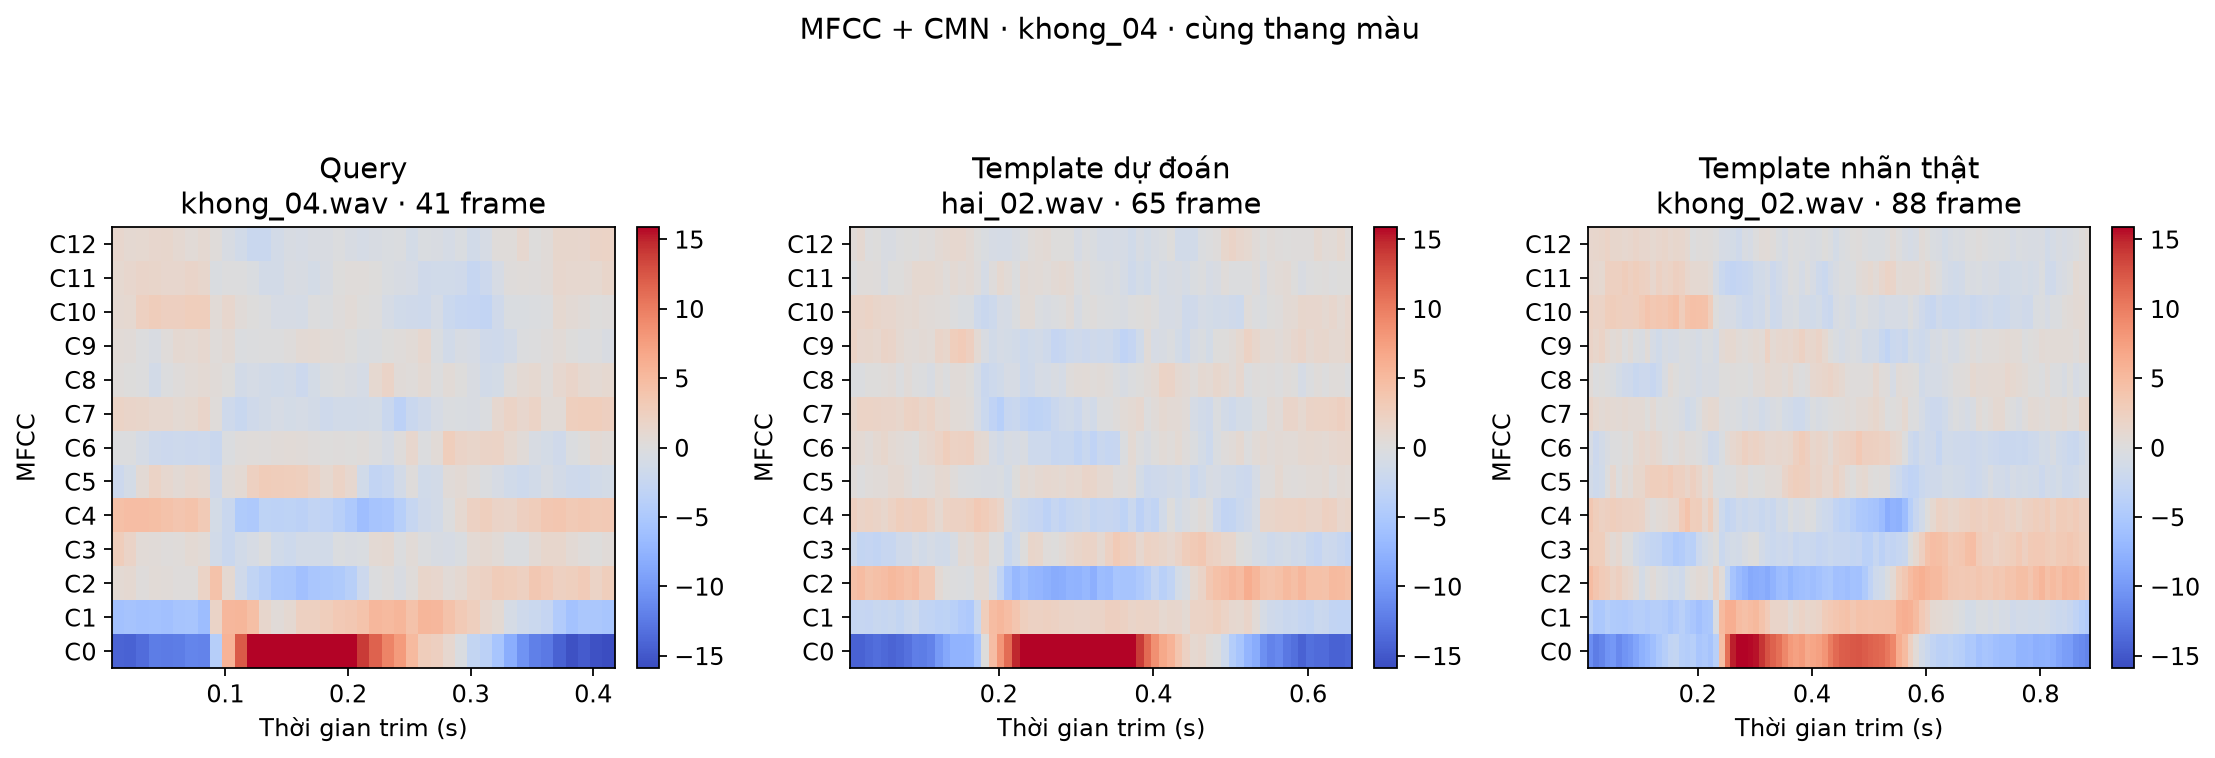

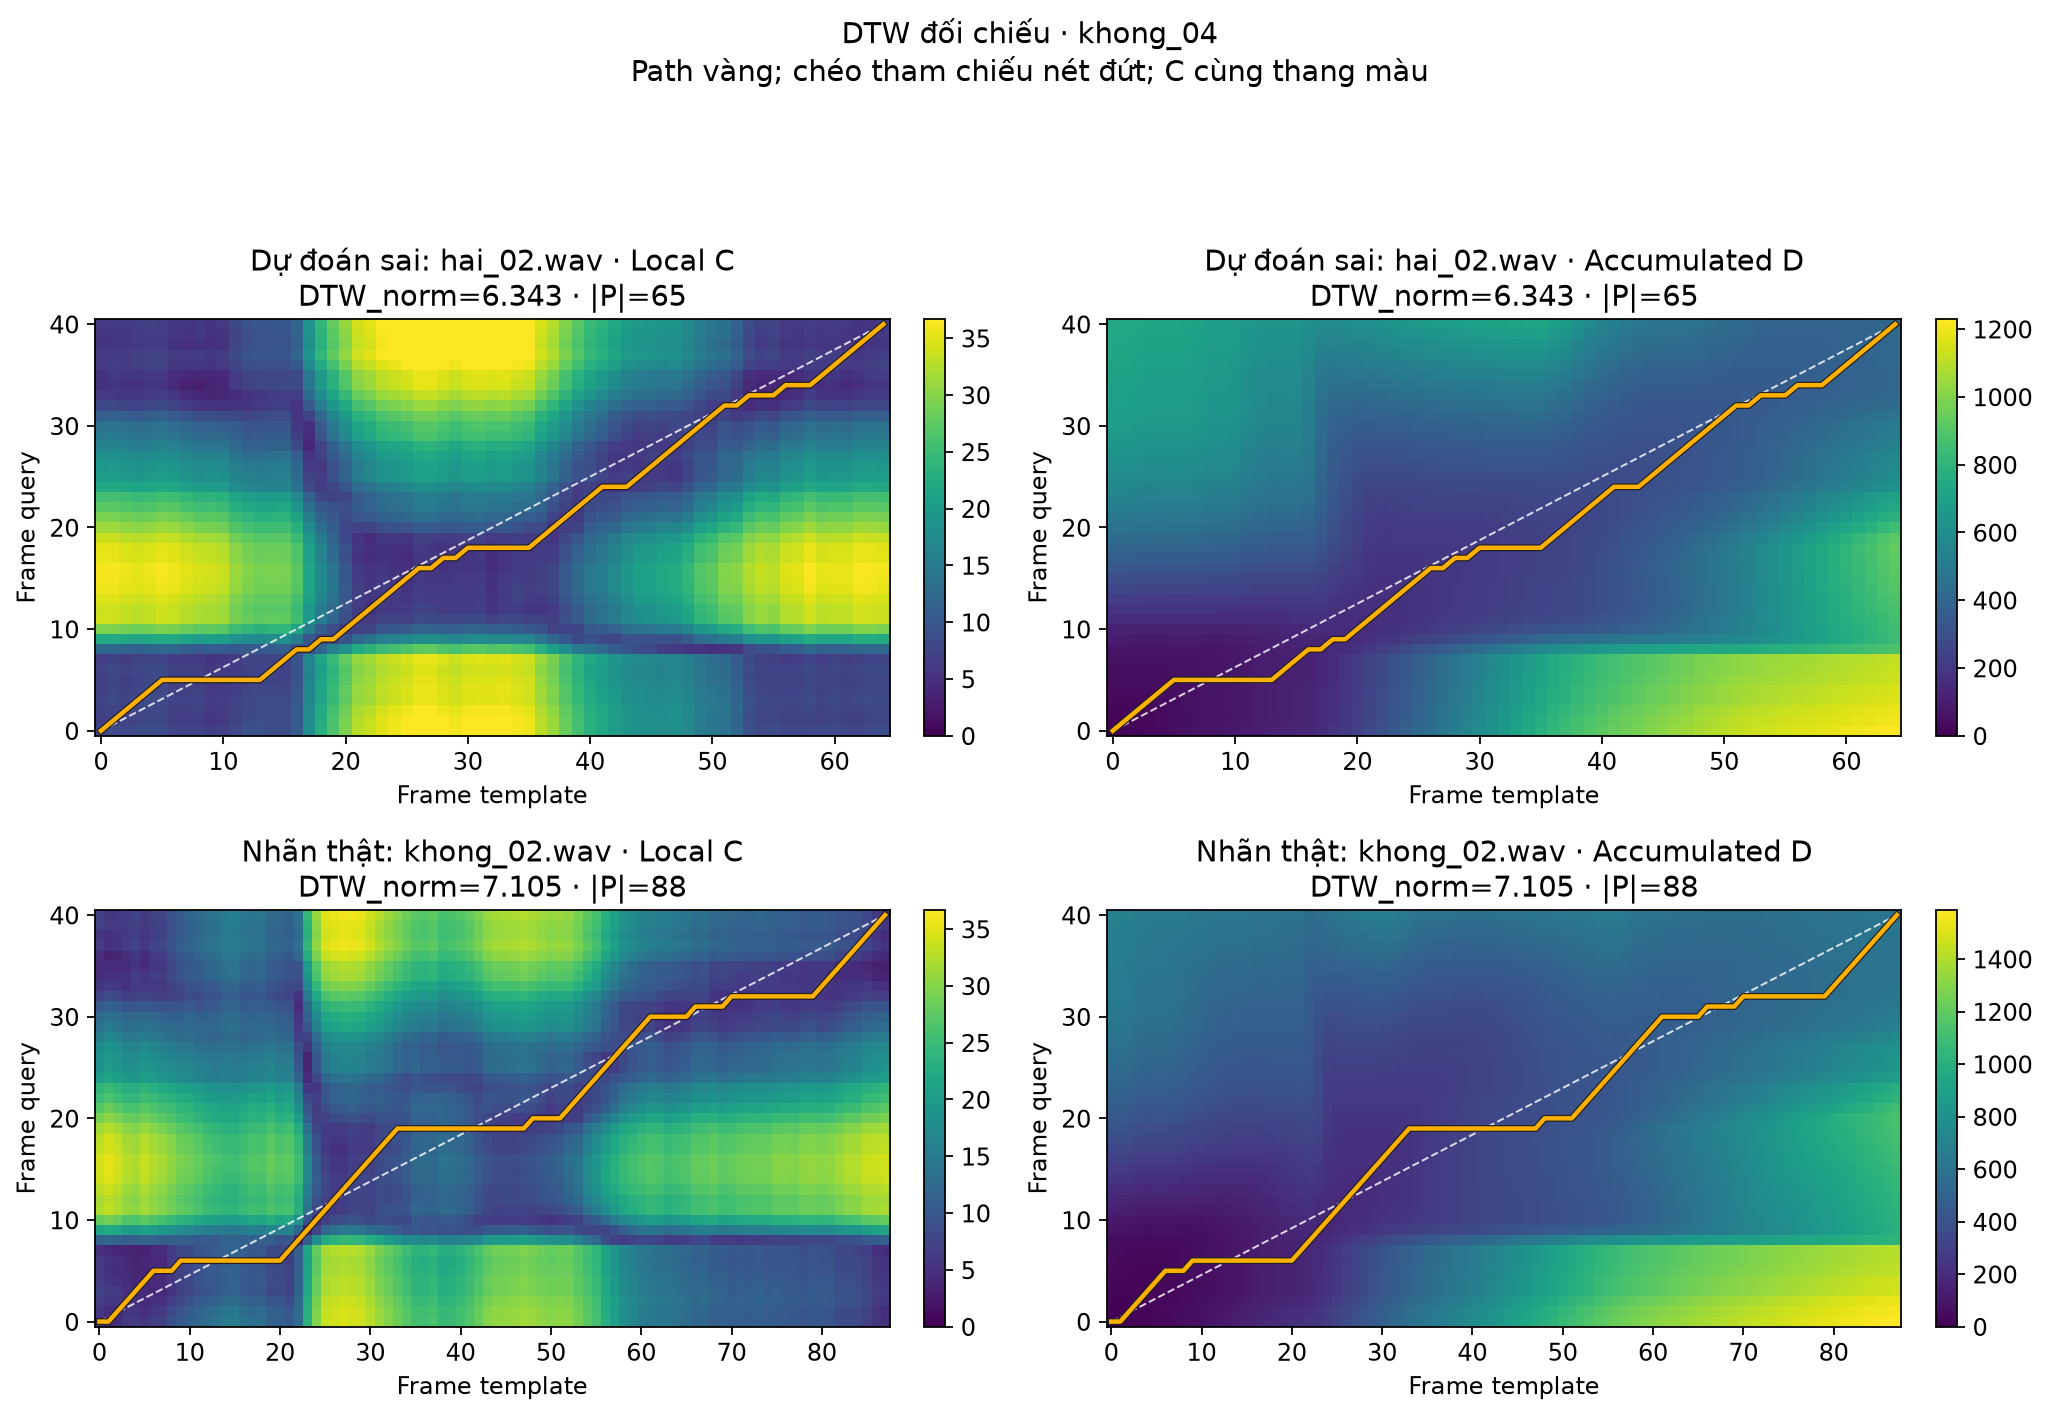

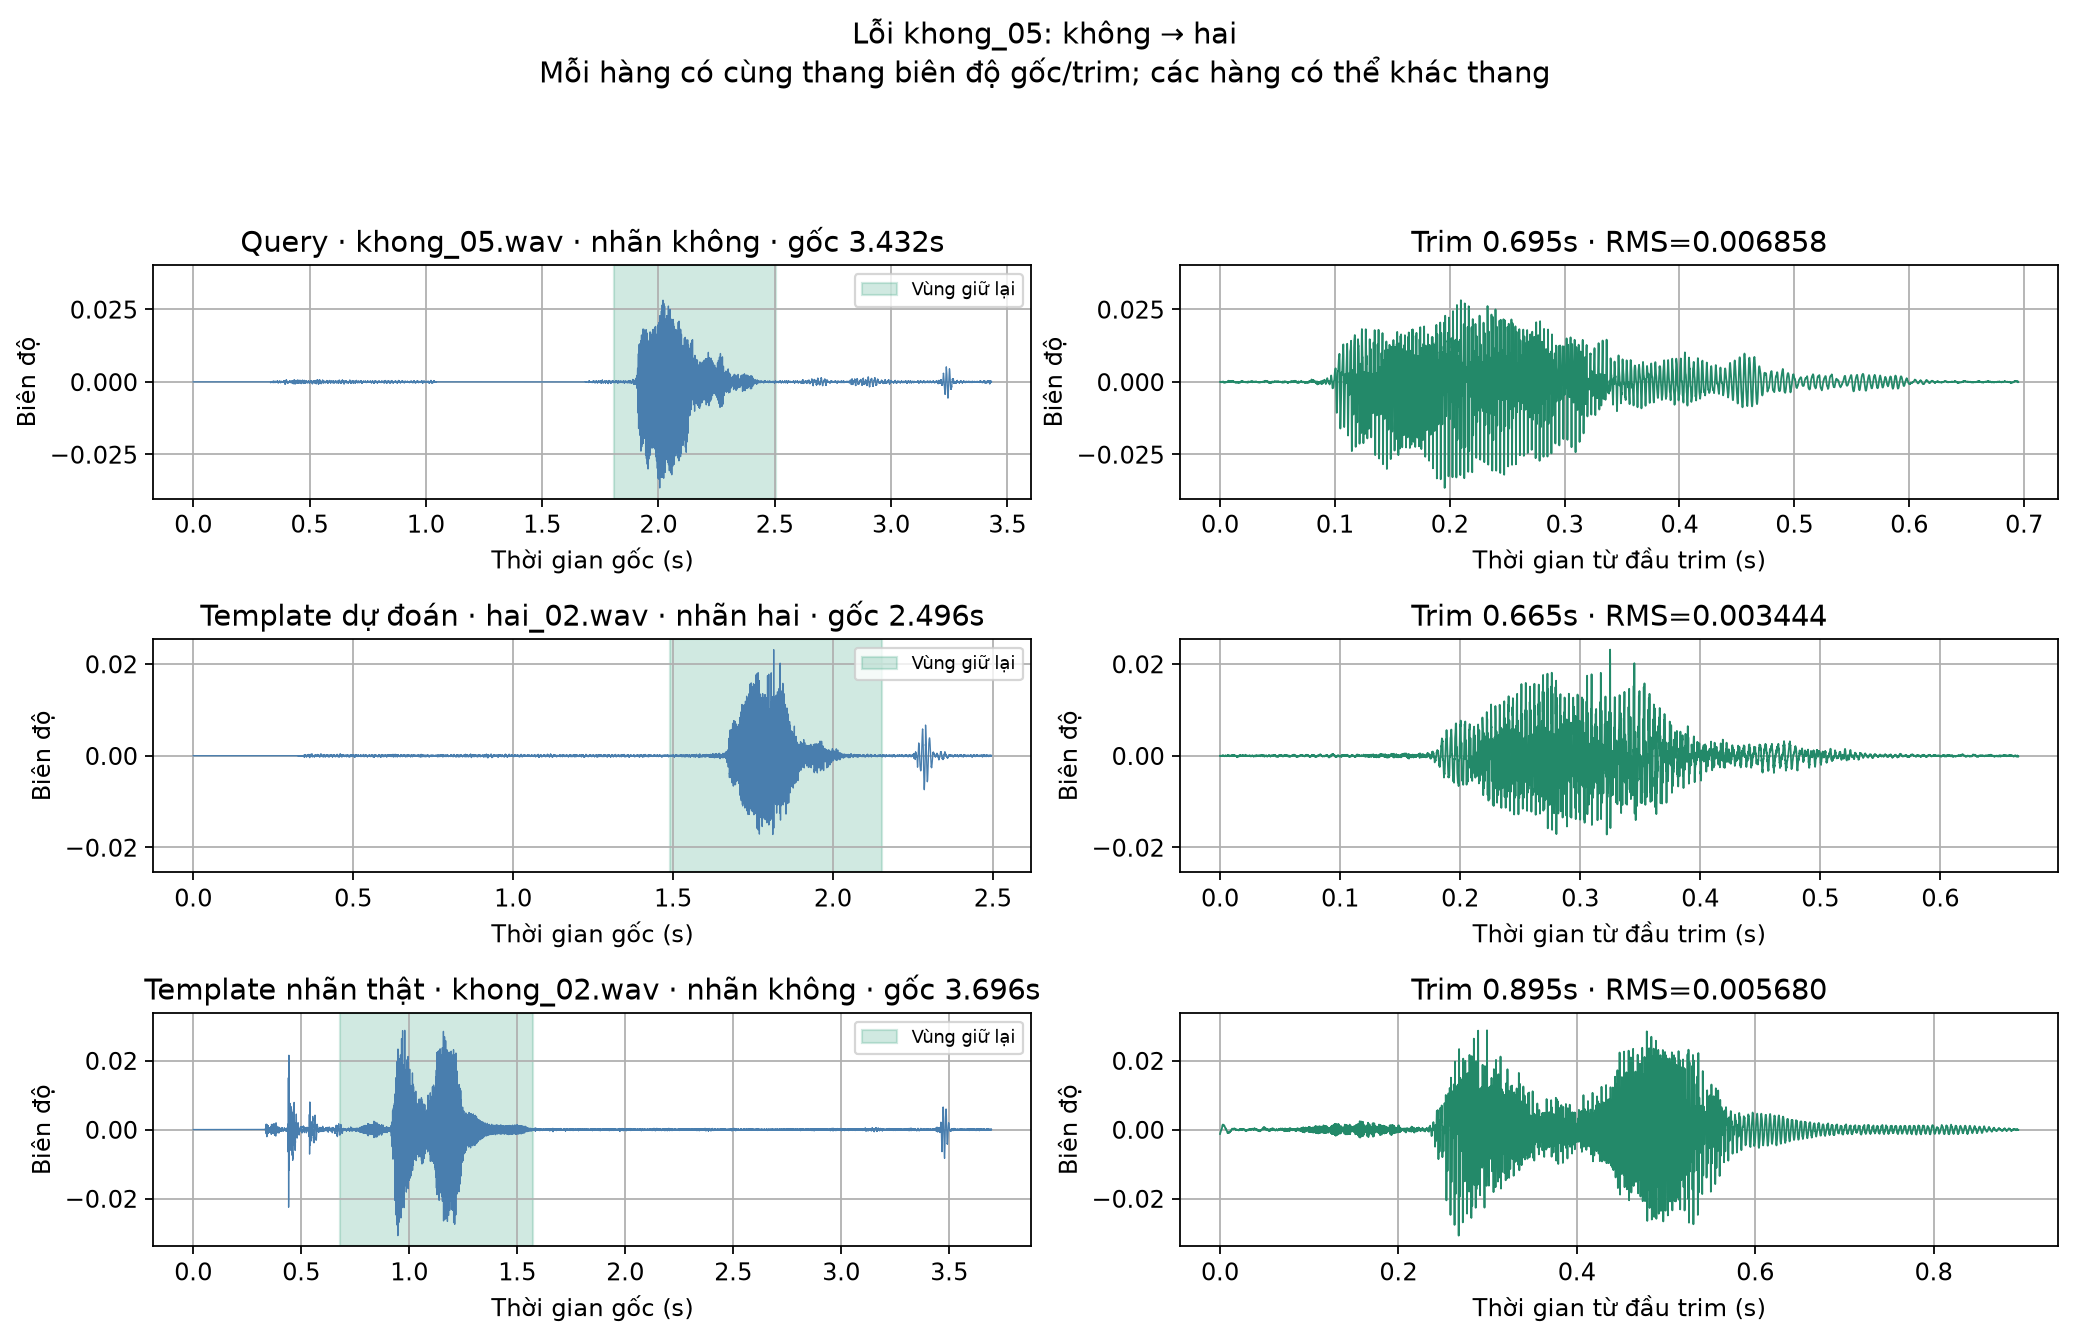

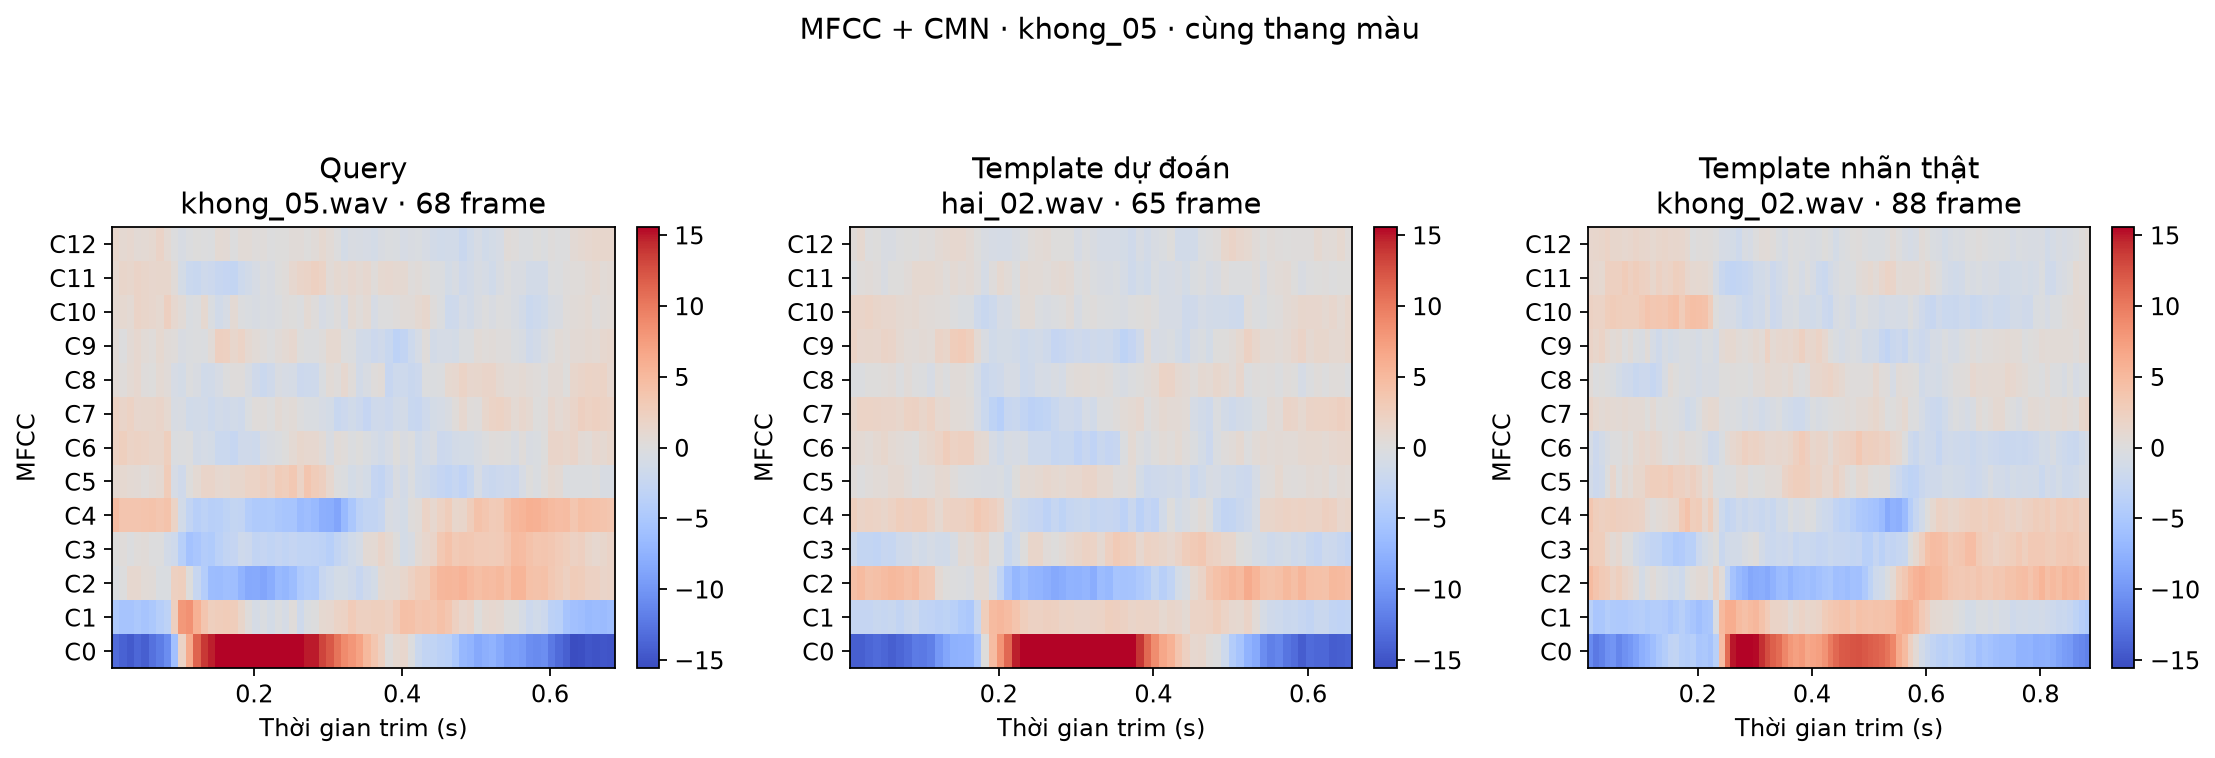

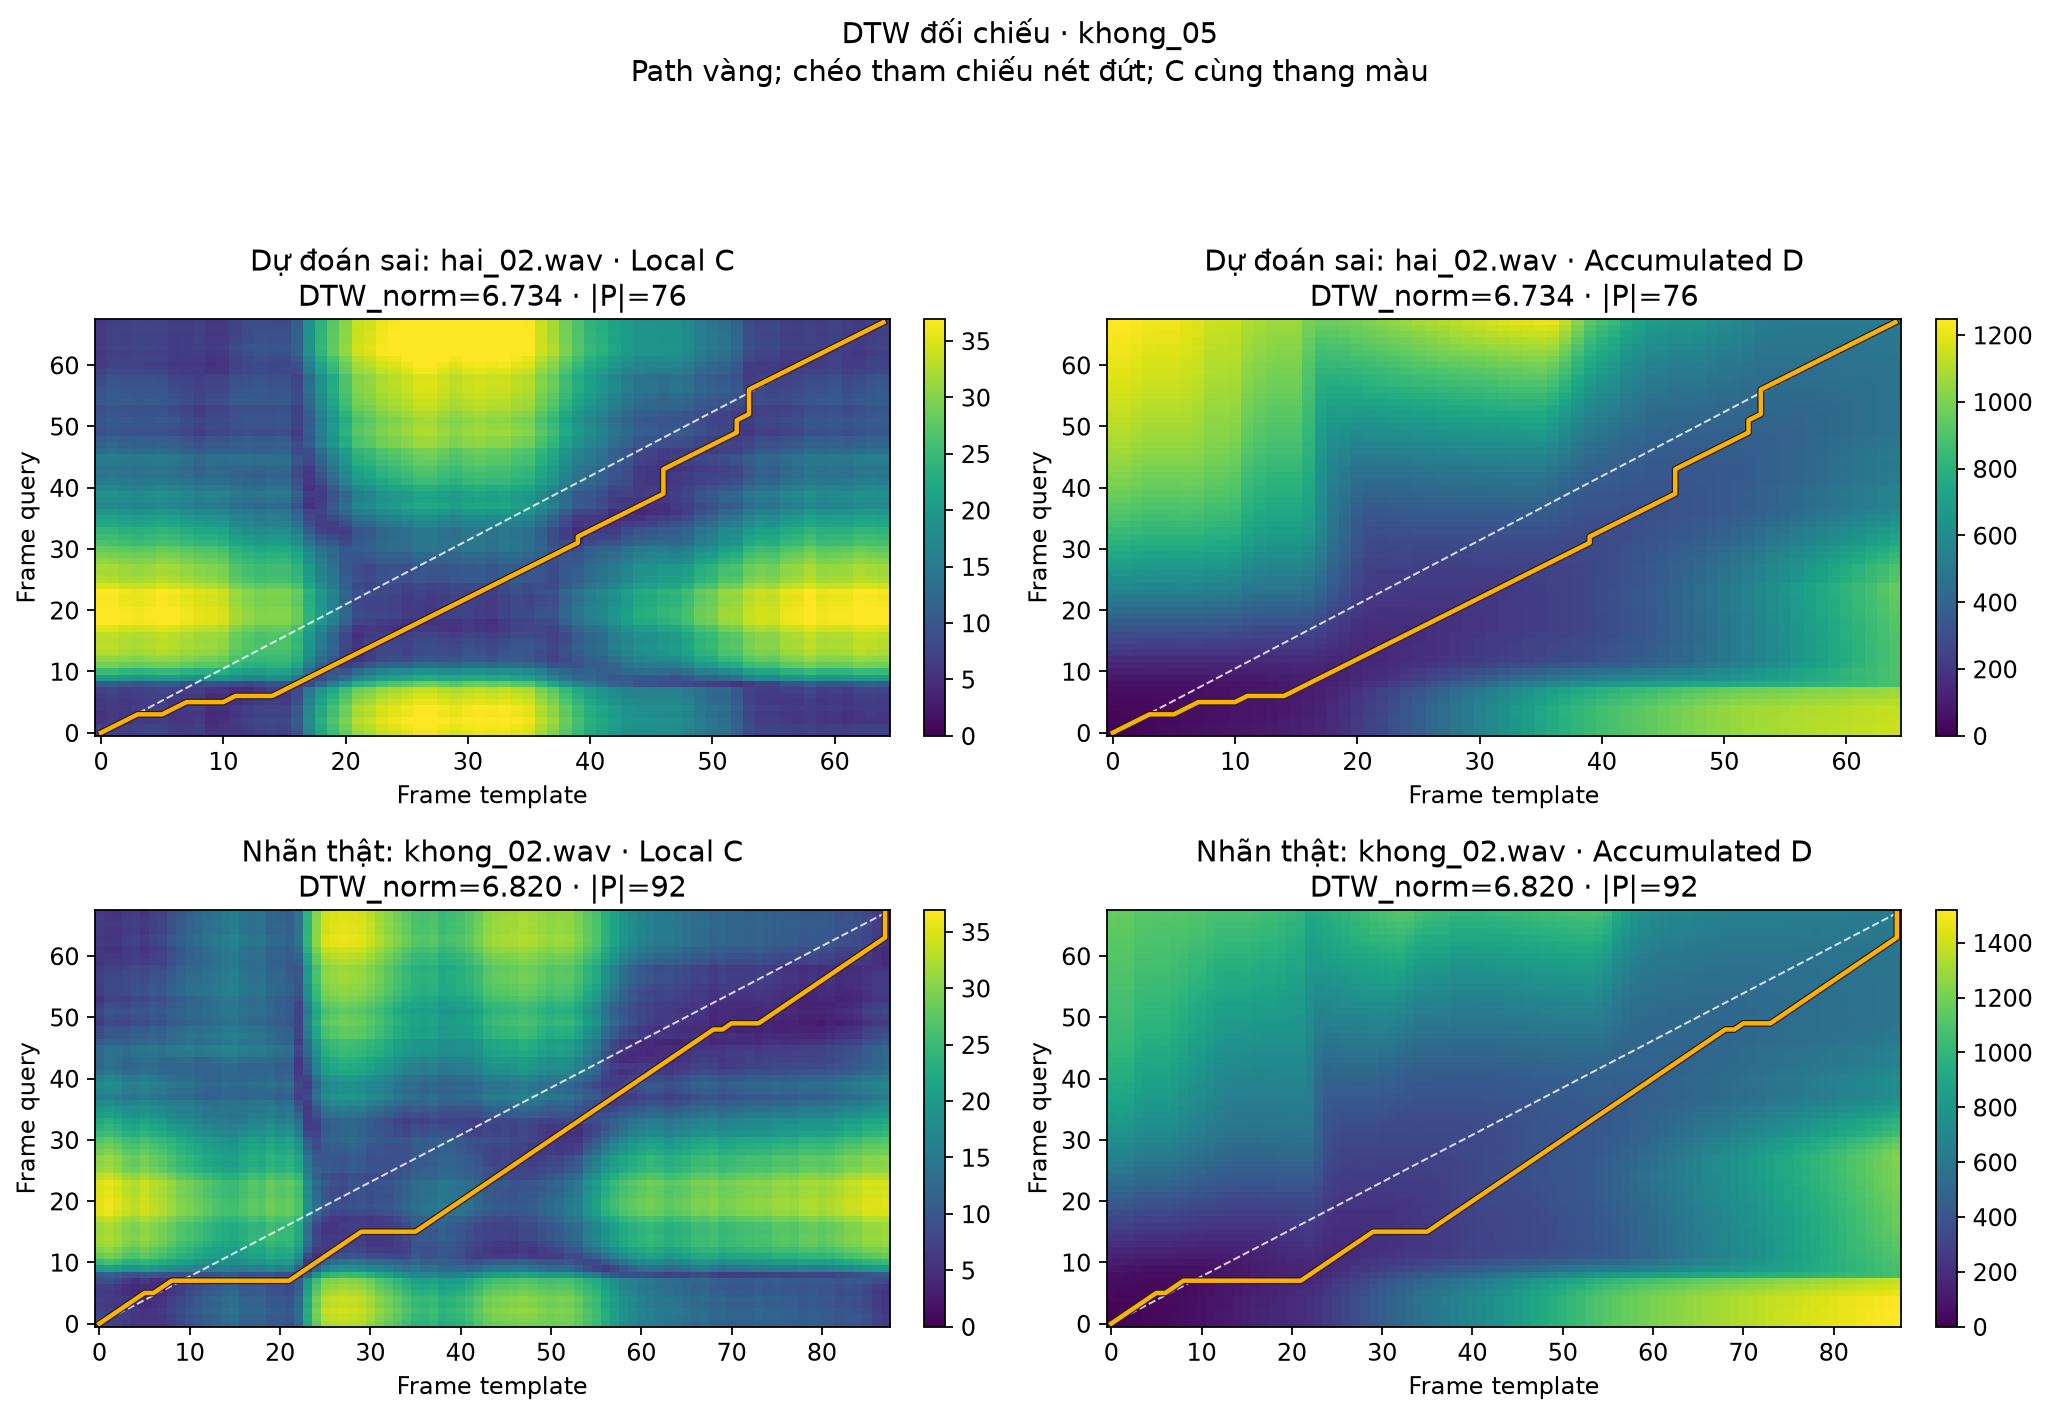

| query_file | comparison | template_file | query_frames | template_frames | query_trim_s | template_trim_s | dtw_norm | path_length | mean_normalized_diagonal_deviation |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| khong/khong_04.wav | predicted | hai/hai_02.wav | 41 | 65 | 0.425 | 0.665 | 6.342907860248758 | 65 | 0.03894230769230769 |
| khong/khong_04.wav | true_label | khong/khong_02.wav | 41 | 88 | 0.425 | 0.895 | 7.10465833732014 | 88 | 0.039958855799373035 |
| khong/khong_05.wav | predicted | hai/hai_02.wav | 68 | 65 | 0.695 | 0.665 | 6.734468457906033 | 76 | 0.084633370974077 |
| khong/khong_05.wav | true_label | khong/khong_02.wav | 68 | 88 | 0.695 | 0.895 | 6.81965338802468 | 92 | 0.09209760791246172 |

In [35]:
ERROR_ROWS = [row for row in EVAL_ROWS if not row["correct"]]
ERROR_COMPARISON_ROWS = []
ERROR_FEATURE_DIR = PROJECT_ROOT / "features" / "errors"
ERROR_FEATURE_DIR.mkdir(parents=True, exist_ok=True)
from matplotlib import patheffects

for error in ERROR_ROWS:
    query_file = error["file"]
    case = Path(query_file).stem
    items = [("Query", query_file),
             ("Template dự đoán", error["winning_template"]),
             ("Template nhãn thật", error["true_label_template"])]
    signals, features = {}, {}
    for role, file in items:
        y, sr = sf.read(DATASET_DIR / file)
        trimmed, endpoint = trim_endpoint(y, sr, **RECOGNIZER.endpoint_config)
        details = mfcc_details(trimmed, sr, **RECOGNIZER.mfcc_config)
        np.testing.assert_allclose(details["mfcc"], MFCC_FEATURES[file], rtol=1e-12, atol=1e-12)
        signals[file] = (y, trimmed, endpoint)
        features[file] = details

    # Waveform gốc và trim: thời gian trim bắt đầu lại từ 0; cùng scale trong mỗi hàng.
    fig, axes = plt.subplots(3, 2, figsize=(13, 8.5), dpi=160)
    for row_index, (role, file) in enumerate(items):
        y, trimmed, endpoint = signals[file]
        left, right = axes[row_index]
        left.plot(np.arange(len(y))/FS, y, color="#497eae", linewidth=.6)
        left.axvspan(endpoint["start_sample"]/FS, endpoint["end_sample"]/FS,
                    color="#2c9e77", alpha=.22, label="Vùng giữ lại")
        right.plot(np.arange(len(trimmed))/FS, trimmed, color="#238969", linewidth=.8)
        limit = max(1e-5, float(np.max(np.abs(y))) * 1.1)
        left.set_ylim(-limit, limit)
        right.set_ylim(-limit, limit)
        label = LABEL_NAMES[file.split("/")[0]]
        left.set(title=f"{role} · {Path(file).name} · nhãn {label} · gốc {len(y)/FS:.3f}s",
                 xlabel="Thời gian gốc (s)", ylabel="Biên độ")
        right.set(title=f"Trim {len(trimmed)/FS:.3f}s · RMS={np.sqrt(np.mean(trimmed**2)):.6f}",
                  xlabel="Thời gian từ đầu trim (s)", ylabel="Biên độ")
        left.legend(fontsize=8, loc="upper right")
    fig.suptitle(f"Lỗi {case}: {LABEL_NAMES[error['true_label']]} → {LABEL_NAMES[error['predicted_label']]}\n"
                 "Mỗi hàng có cùng thang biên độ gốc/trim; các hàng có thể khác thang")
    fig.canvas.draw()
    fig.tight_layout(rect=(0, 0, 1, .92))
    fig.savefig(FIGURES_DIR / f"phase8_error_{case}_waveforms.png", dpi=160, bbox_inches="tight", pad_inches=.2)
    plt.show()
    plt.close(fig)

    # MFCC: cùng giới hạn màu, thời gian theo tâm frame kể từ đầu trim.
    limit = max(1e-6, float(np.percentile(np.abs(np.concatenate(
        [features[file]["mfcc"].ravel() for _, file in items])), 99)))
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.8), dpi=160)
    for ax, (role, file) in zip(axes, items):
        details = features[file]
        times = details["times"]
        im = ax.imshow(details["mfcc"].T, origin="lower", aspect="auto", cmap="coolwarm",
                       vmin=-limit, vmax=limit,
                       extent=(times[0] - HOP/FS/2, times[-1] + HOP/FS/2, -.5, N_MFCC-.5))
        ax.set(title=f"{role}\n{Path(file).name} · {len(times)} frame", xlabel="Thời gian trim (s)", ylabel="MFCC")
        ax.set_yticks(range(N_MFCC), [f"C{i}" for i in range(N_MFCC)])
        ax.grid(False)
        fig.colorbar(im, ax=ax, fraction=.046, pad=.04)
    fig.suptitle(f"MFCC + CMN · {case} · cùng thang màu")
    fig.canvas.draw()
    fig.tight_layout(rect=(0, 0, 1, .91))
    fig.savefig(FIGURES_DIR / f"phase8_error_{case}_mfcc.png", dpi=160, bbox_inches="tight", pad_inches=.2)
    plt.show()
    plt.close(fig)

    comparisons = []
    for kind, template_file, expected_score in [
            ("predicted", error["winning_template"], error["top1_score"]),
            ("true_label", error["true_label_template"], error["true_label_score"])]:
        X, Y = features[query_file]["mfcc"], features[template_file]["mfcc"]
        details = dtw_details(X, Y)
        validate_dtw_path(details, len(X), len(Y))
        assert np.isclose(details["normalized_cost"], expected_score, rtol=1e-12, atol=1e-12)
        comparisons.append((kind, template_file, details))
        _, trimmed, _ = signals[template_file]
        statistics = path_statistics(details["path"], len(X), len(Y))
        comparison = {"query_file": query_file, "true_label": error["true_label"],
                      "predicted_label": error["predicted_label"], "comparison": kind,
                      "template_file": template_file, "query_frames": len(X), "template_frames": len(Y),
                      "query_trim_s": error["trimmed_duration_s"], "template_trim_s": len(trimmed)/FS,
                      "dtw_norm": details["normalized_cost"], "total_cost": details["total_cost"],
                      "path_length": details["path_length"], **statistics}
        ERROR_COMPARISON_ROWS.append(comparison)
        np.savez_compressed(ERROR_FEATURE_DIR / f"{case}_{kind}.npz",
                            local_distance=details["local_distance"], accumulated_cost=details["accumulated_cost"],
                            path=np.array(details["path"]), query_file=query_file, template_file=template_file,
                            normalized_cost=details["normalized_cost"], total_cost=details["total_cost"],
                            config_json=json.dumps(RECOGNIZER_CONFIG, ensure_ascii=False))
        path_rows = [{"step": step, "query_frame": i, "template_frame": j,
                      "local_cost": details["local_distance"][i,j],
                      "accumulated_cost": details["accumulated_cost"][i,j]}
                     for step, (i, j) in enumerate(details["path"])]
        write_csv(PROJECT_ROOT / f"outputs/phase8_path_{case}_{kind}.csv", path_rows, list(path_rows[0]))

    local_limit = max(1e-6, float(np.percentile(np.concatenate(
        [r[2]["local_distance"].ravel() for r in comparisons]), 99)))
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), dpi=160)
    for row_index, (kind, file, details) in enumerate(comparisons):
        N, M = details["local_distance"].shape
        path_array = np.array(details["path"])
        for ax, key, title in zip(axes[row_index], ["local_distance", "accumulated_cost"], ["Local C", "Accumulated D"]):
            im = ax.imshow(details[key], origin="lower", aspect="auto", cmap="viridis", vmin=0,
                           vmax=local_limit if key == "local_distance" else None)
            ax.plot([0, M-1], [0, N-1], "--", color="white", linewidth=.9, alpha=.8)
            ax.plot(path_array[:,1], path_array[:,0], color="#ffb000", linewidth=2,
                    path_effects=[patheffects.Stroke(linewidth=3.1, foreground="#222"), patheffects.Normal()])
            role = "Dự đoán sai" if kind == "predicted" else "Nhãn thật"
            ax.set(title=f"{role}: {Path(file).name} · {title}\nDTW_norm={details['normalized_cost']:.3f} · |P|={details['path_length']}",
                   xlabel="Frame template", ylabel="Frame query")
            ax.grid(False)
            fig.colorbar(im, ax=ax, fraction=.046, pad=.04)
    fig.suptitle(f"DTW đối chiếu · {case}\nPath vàng; chéo tham chiếu nét đứt; C cùng thang màu")
    fig.canvas.draw()
    fig.tight_layout(rect=(0, 0, 1, .91))
    fig.savefig(FIGURES_DIR / f"phase8_error_{case}_dtw.png", dpi=160, bbox_inches="tight", pad_inches=.2)
    plt.show()
    plt.close(fig)

if ERROR_COMPARISON_ROWS:
    write_csv(PROJECT_ROOT / "outputs/phase8_error_comparison.csv", ERROR_COMPARISON_ROWS, list(ERROR_COMPARISON_ROWS[0]))
    show_table(ERROR_COMPARISON_ROWS, ["query_file", "comparison", "template_file", "query_frames", "template_frames",
                                     "query_trim_s", "template_trim_s", "dtw_norm", "path_length",
                                     "mean_normalized_diagonal_deviation"])
else:
    print("Không có lỗi top-1 trên split này; không tạo minh họa lỗi giả.")

### G4. Nhận xét Phase 8 và cách chạy lại

Tỷ lệ ở đây chỉ mô tả 10 query của split đã chốt. Mỗi nhãn có 2 test, vì vậy recall theo nhãn thay đổi 50 điểm phần trăm khi một file đổi kết quả. Chưa đánh giá người nói/micro mới hoặc unknown words.

Bộ kiểm thử `tests/test_lab2_evaluation.py` kiểm tra confusion matrix bằng ví dụ có kết quả đếm biết trước, thứ tự hàng/cột, top-k, nhãn thiếu support, input lỗi và đủ query test. Run All kiểm tra matrix thêm bằng vòng lặp đếm độc lập.

Chạy đánh giá từ WAV gốc bằng CLI:

```powershell
.\.venv-lab2\Scripts\python.exe -X utf8 lab2_evaluation.py
```

CLI xuất bảng/chỉ số; notebook tạo thêm hình và phân tích lỗi. Các thí nghiệm đổi cấu hình E1/E2 thuộc Phase 9 bên dưới.

In [36]:
lines = ["# Phase 8 — Đánh giá baseline", "",
         f"**Accuracy: {EVAL_METRICS['n_correct']}/{EVAL_METRICS['n_test']} = {EVAL_METRICS['accuracy']:.1%}.** "
         f"Top-2: {EVAL_METRICS['top_k_accuracy']['2']:.1%}; top-3: {EVAL_METRICS['top_k_accuracy']['3']:.1%}.",
         "", "## Giao thức", "",
         "15 template training (3/nhãn), 10 test (2/nhãn), split cố định. "
         "WAV gốc → endpoint margin 80 ms → MFCC 13 + CMN → DTW Euclidean chuẩn hóa/path length → min theo nhãn.",
         "Không thay tham số hoặc chọn ngưỡng reject từ kết quả test. CLI tính lại từ WAV gốc và cho cùng chỉ số; "
         "Run All dùng kết quả vừa tính ở Phase 7. Hash WAV/split và provenance đã được kiểm tra.",
         "", "## Confusion matrix", "",
         "Hàng = nhãn thật; cột = nhãn dự đoán. Đơn vị số file.", "",
         "| Thật / dự đoán | " + " | ".join(LABEL_NAMES[label] for label in LABELS) + " |",
         "|---|" + "---|" * len(LABELS)]
for label, counts in zip(LABELS, cm):
    lines.append("| " + " | ".join([LABEL_NAMES[label], *[str(int(v)) for v in counts]]) + " |")
lines += ["", "## Theo nhãn", "", "| Nhãn | Test | Đúng | Precision | Recall | F1 |", "|---|---|---|---|---|---|"]
for row in EVAL_METRICS["per_label"]:
    lines.append(f"| {LABEL_NAMES[row['label']]} | {row['support']} | {row['correct']} | "
                 f"{row['precision']:.3f} | {row['recall']:.3f} | {row['f1']:.3f} |")
lines += [f"", f"Macro precision={EVAL_METRICS['macro_precision']:.3f}; recall={EVAL_METRICS['macro_recall']:.3f}; "
          f"F1={EVAL_METRICS['macro_f1']:.3f}. Precision nhãn không không có dự đoán được ghi 0 theo zero_division=0.",
          "", "## Phân tích mọi lỗi top-1", ""]
for error in ERROR_ROWS:
    lines.append(f"- `{error['file']}`: thật **{LABEL_NAMES[error['true_label']]}**, dự đoán "
                 f"**{LABEL_NAMES[error['predicted_label']]}**; template thắng `{error['winning_template']}` "
                 f"score={error['top1_score']:.6f}; template nhãn thật tốt nhất `{error['true_label_template']}` "
                 f"score={error['true_label_score']:.6f}; nhãn thật rank={error['true_label_rank']}. "
                 f"True-minus-pred={error['true_minus_pred_score']:.6f}; top2-minus-top1={error['score_gap']:.6f}. "
                 f"Query trim={error['trimmed_duration_s']:.3f}s/{error['n_frames']} frame.")
for row in ERROR_COMPARISON_ROWS:
    lines.append(f"- Đối chiếu {row['query_file']} / {row['template_file']} ({row['comparison']}): "
                 f"{row['query_frames']}×{row['template_frames']} frame; template trim={row['template_trim_s']:.3f}s; "
                 f"path={row['path_length']}; chéo/dọc/ngang={row['diagonal_steps']}/{row['vertical_steps']}/{row['horizontal_steps']}; "
                 f"mean lệch chéo chuẩn hóa={row['mean_normalized_diagonal_deviation']:.4f}.")
if not ERROR_ROWS:
    lines.append("Không có lỗi top-1 trong split này.")
lines += ["", "## Nhận xét dựa trên số liệu", "",
          "- Hai lỗi hiện tại đều không → hai; recall không=0/2, precision hai=2/4. Bốn nhãn còn lại có recall 2/2.",
          "- khong_04: nhãn thật chỉ đứng thứ 3; top-2 là bốn. Vì vậy top2-minus-top1 khác chênh giữa nhãn thật và dự đoán. "
          "khong_05: nhãn thật đứng thứ 2, chênh khoảng 0.085; điểm gần nhau không đủ căn cứ để đặt ngưỡng reject.",
          "- Waveform cho biết vùng được giữ và thời lượng; MFCC của query/template có số frame khác nhau. "
          "DTW đối chiếu xác nhận chi phí chuẩn hóa của hai thấp hơn template không tốt nhất, nhưng shape/path không chứng minh hai bản ghi cùng từ.",
          "- Ở waveform trim, khong_04 có một cụm biên độ mạnh ngắn, còn khong_02 có hai cụm rõ hơn. "
          "Query khong_04 dài 0.425s, khong_05 dài 0.695s, so với hai_02 0.665s và khong_02 0.895s. "
          "Thời lượng và hình dạng bao biên độ khác nhau, chưa đủ gán nguyên nhân ngữ âm.",
          "- Trên heatmap cùng thang màu, C0/C1 biến thiên nổi bật hơn nhiều hệ số cao; CMN vẫn giữ biến thiên theo thời gian. "
          "Các dải màu được DTW căn chỉnh, không chỉ so hai hình tại cùng thời điểm tuyệt đối.",
          "- Mean độ lệch chéo của khong_04 với hai_02/khong_02 là 0.0389/0.0400; khong_05 là 0.0846/0.0921. "
          "Cả path của nhãn sai lẫn nhãn thật đều có thể gần chéo; quyết định ở đây dựa trên DTW_norm.",
          "- Giả thuyết cần kiểm tra: biến thiên phát âm/tốc độ/nền và đoạn phụ âm yếu bị endpoint bỏ qua có thể làm feature kém phân biệt. "
          "Chưa xác nhận cắt phụ âm hoặc sai nhãn bằng nghe. CMN loại bỏ trung bình mỗi utterance; không khắc phục mọi khác biệt.",
          "- E1 trim vs không trim và E2 MFCC vs MFCC+delta ở Phase 9 sẽ kiểm tra ảnh hưởng pipeline theo cùng split; chưa thực hiện ở Phase 8.",
          "- Kết quả 80% chỉ của 10 test; 2 test/nhãn. Chưa có kiểm tra người nói mới, microphone khác hay unknown words. "
          "Có 7 file endpoint cần nghe từ Phase 4; không loại khỏi đánh giá.",
          "", "## Sản phẩm và kiểm tra", "",
          "- results.csv: 10 dòng, nhãn thật/dự đoán, đúng/sai, top-1/top-2/top-3, template, rank nhãn thật và cảnh báo.",
          "- outputs/phase8_metrics.json; outputs/phase8_confusion_matrix.csv; outputs/phase8_confusion_matrix_normalized.csv; outputs/phase8_per_label_metrics.csv.",
          "- outputs/phase8_evaluation_provenance.json; outputs/phase8_error_comparison.csv; 4 CSV path; features/errors/ (4 NPZ).",
          "- figures/phase8_confusion_matrix.png; 6 hình lỗi waveform/MFCC/DTW cho 2 query.",
          "- lab2_evaluation.py; tests/test_lab2_evaluation.py (3 kiểm thử đạt); phần G1–G4 notebook."]
PHASE8_REPORT = "\n".join(lines) + "\n"
(PROJECT_ROOT / "reports/Phase8_Evaluation_Report.md").write_text(PHASE8_REPORT, encoding="utf-8")
display(Markdown(PHASE8_REPORT))
print("Phase 8: đã đánh giá 10 test, xuất results.csv, confusion matrix, 7 hình và báo cáo phân tích lỗi.")

# Phase 8 — Đánh giá baseline

**Accuracy: 8/10 = 80.0%.** Top-2: 90.0%; top-3: 100.0%.

## Giao thức

15 template training (3/nhãn), 10 test (2/nhãn), split cố định. WAV gốc → endpoint margin 80 ms → MFCC 13 + CMN → DTW Euclidean chuẩn hóa/path length → min theo nhãn.
Không thay tham số hoặc chọn ngưỡng reject từ kết quả test. CLI tính lại từ WAV gốc và cho cùng chỉ số; Run All dùng kết quả vừa tính ở Phase 7. Hash WAV/split và provenance đã được kiểm tra.

## Confusion matrix

Hàng = nhãn thật; cột = nhãn dự đoán. Đơn vị số file.

| Thật / dự đoán | không | một | hai | ba | bốn |
|---|---|---|---|---|---|
| không | 0 | 0 | 2 | 0 | 0 |
| một | 0 | 2 | 0 | 0 | 0 |
| hai | 0 | 0 | 2 | 0 | 0 |
| ba | 0 | 0 | 0 | 2 | 0 |
| bốn | 0 | 0 | 0 | 0 | 2 |

## Theo nhãn

| Nhãn | Test | Đúng | Precision | Recall | F1 |
|---|---|---|---|---|---|
| không | 2 | 0 | 0.000 | 0.000 | 0.000 |
| một | 2 | 2 | 1.000 | 1.000 | 1.000 |
| hai | 2 | 2 | 0.500 | 1.000 | 0.667 |
| ba | 2 | 2 | 1.000 | 1.000 | 1.000 |
| bốn | 2 | 2 | 1.000 | 1.000 | 1.000 |

Macro precision=0.700; recall=0.800; F1=0.733. Precision nhãn không không có dự đoán được ghi 0 theo zero_division=0.

## Phân tích mọi lỗi top-1

- `khong/khong_04.wav`: thật **không**, dự đoán **hai**; template thắng `hai/hai_02.wav` score=6.342908; template nhãn thật tốt nhất `khong/khong_02.wav` score=7.104658; nhãn thật rank=3. True-minus-pred=0.761750; top2-minus-top1=0.755130. Query trim=0.425s/41 frame.
- `khong/khong_05.wav`: thật **không**, dự đoán **hai**; template thắng `hai/hai_02.wav` score=6.734468; template nhãn thật tốt nhất `khong/khong_02.wav` score=6.819653; nhãn thật rank=2. True-minus-pred=0.085185; top2-minus-top1=0.085185. Query trim=0.695s/68 frame.
- Đối chiếu khong/khong_04.wav / hai/hai_02.wav (predicted): 41×65 frame; template trim=0.665s; path=65; chéo/dọc/ngang=40/0/24; mean lệch chéo chuẩn hóa=0.0389.
- Đối chiếu khong/khong_04.wav / khong/khong_02.wav (true_label): 41×88 frame; template trim=0.895s; path=88; chéo/dọc/ngang=40/0/47; mean lệch chéo chuẩn hóa=0.0400.
- Đối chiếu khong/khong_05.wav / hai/hai_02.wav (predicted): 68×65 frame; template trim=0.665s; path=76; chéo/dọc/ngang=56/11/8; mean lệch chéo chuẩn hóa=0.0846.
- Đối chiếu khong/khong_05.wav / khong/khong_02.wav (true_label): 68×88 frame; template trim=0.895s; path=92; chéo/dọc/ngang=63/4/24; mean lệch chéo chuẩn hóa=0.0921.

## Nhận xét dựa trên số liệu

- Hai lỗi hiện tại đều không → hai; recall không=0/2, precision hai=2/4. Bốn nhãn còn lại có recall 2/2.
- khong_04: nhãn thật chỉ đứng thứ 3; top-2 là bốn. Vì vậy top2-minus-top1 khác chênh giữa nhãn thật và dự đoán. khong_05: nhãn thật đứng thứ 2, chênh khoảng 0.085; điểm gần nhau không đủ căn cứ để đặt ngưỡng reject.
- Waveform cho biết vùng được giữ và thời lượng; MFCC của query/template có số frame khác nhau. DTW đối chiếu xác nhận chi phí chuẩn hóa của hai thấp hơn template không tốt nhất, nhưng shape/path không chứng minh hai bản ghi cùng từ.
- Ở waveform trim, khong_04 có một cụm biên độ mạnh ngắn, còn khong_02 có hai cụm rõ hơn. Query khong_04 dài 0.425s, khong_05 dài 0.695s, so với hai_02 0.665s và khong_02 0.895s. Thời lượng và hình dạng bao biên độ khác nhau, chưa đủ gán nguyên nhân ngữ âm.
- Trên heatmap cùng thang màu, C0/C1 biến thiên nổi bật hơn nhiều hệ số cao; CMN vẫn giữ biến thiên theo thời gian. Các dải màu được DTW căn chỉnh, không chỉ so hai hình tại cùng thời điểm tuyệt đối.
- Mean độ lệch chéo của khong_04 với hai_02/khong_02 là 0.0389/0.0400; khong_05 là 0.0846/0.0921. Cả path của nhãn sai lẫn nhãn thật đều có thể gần chéo; quyết định ở đây dựa trên DTW_norm.
- Giả thuyết cần kiểm tra: biến thiên phát âm/tốc độ/nền và đoạn phụ âm yếu bị endpoint bỏ qua có thể làm feature kém phân biệt. Chưa xác nhận cắt phụ âm hoặc sai nhãn bằng nghe. CMN loại bỏ trung bình mỗi utterance; không khắc phục mọi khác biệt.
- E1 trim vs không trim và E2 MFCC vs MFCC+delta ở Phase 9 sẽ kiểm tra ảnh hưởng pipeline theo cùng split; chưa thực hiện ở Phase 8.
- Kết quả 80% chỉ của 10 test; 2 test/nhãn. Chưa có kiểm tra người nói mới, microphone khác hay unknown words. Có 7 file endpoint cần nghe từ Phase 4; không loại khỏi đánh giá.

## Sản phẩm và kiểm tra

- results.csv: 10 dòng, nhãn thật/dự đoán, đúng/sai, top-1/top-2/top-3, template, rank nhãn thật và cảnh báo.
- outputs/phase8_metrics.json; outputs/phase8_confusion_matrix.csv; outputs/phase8_confusion_matrix_normalized.csv; outputs/phase8_per_label_metrics.csv.
- outputs/phase8_evaluation_provenance.json; outputs/phase8_error_comparison.csv; 4 CSV path; features/errors/ (4 NPZ).
- figures/phase8_confusion_matrix.png; 6 hình lỗi waveform/MFCC/DTW cho 2 query.
- lab2_evaluation.py; tests/test_lab2_evaluation.py (3 kiểm thử đạt); phần G1–G4 notebook.


Phase 8: đã đánh giá 10 test, xuất results.csv, confusion matrix, 7 hình và báo cáo phân tích lỗi.


### G5. Thiết kế thí nghiệm đối chứng — Phase 9

Theo phần G và mục 5.9 của **Lab 2.pdf**, chạy E1/E2 với cùng 15 train và 10 test, giữ ba template/nhãn và toàn bộ cấu hình còn lại:

| Cấu hình | Endpoint | Feature/frame | Vai trò |
|---|---|---|---|
| `trim_mfcc13` | Có, margin 80 ms | 13 MFCC + CMN | Đối chứng chung, tính lại để khớp Phase 8 |
| `no_trim_mfcc13` | Không, giữ toàn WAV | 13 MFCC + CMN | E1: chỉ bỏ endpoint ở cả train/test |
| `trim_mfcc_delta26` | Có, margin 80 ms | 13 MFCC + 13 Δ | E2: chỉ thêm Δ ở cả train/test |

Mỗi cấu hình **tính mới tất cả 25 feature**, không tái dùng template trim cho query không trim. Không gain normalization, band DTW, trọng số Δ hoặc reject threshold được điều chỉnh theo test. Kết quả ở `experiments/phase9/`, cache feature ở `features/experiments/`; `results.csv` gốc tiếp tục là baseline Phase 8.

Đề không ấn định cửa sổ Δ. Chốt trước khi chạy: Δ bậc 1, $N=2$ frame mỗi phía (cửa sổ 5 frame, hop 10 ms), lặp frame biên và trọng số 1:

$$\Delta c_t=\frac{\sum_{n=1}^{2}n(c_{t+n}-c_{t-n})}{2\sum_{n=1}^{2}n^2}=\frac{(c_{t+1}-c_{t-1})+2(c_{t+2}-c_{t-2})}{10}.$$

Tính Δ trên MFCC đã CMN, ghép `[C0…C12, ΔC0…ΔC12]` thành `(T,26)`. Không tính ΔΔ, không CMN thêm block Δ. Đơn vị Δ là thay đổi hệ số/frame, không phải hệ số/giây. Cách tính tường minh trong `lab2_experiments.py`.

In [37]:
import lab2_experiments
importlib.reload(lab2_experiments)
from lab2_experiments import VARIANTS, DELTA_CONFIG, delta_features, run_experiments, comparison_changes, path_case

EXPERIMENT_RUNS, EXPERIMENT_SUMMARY = run_experiments(PROJECT_ROOT, progress=lambda message: print(message, flush=True))
for file, static in MFCC_FEATURES.items():
    control = EXPERIMENT_RUNS["trim_mfcc13"]["features"][file]
    dynamic = EXPERIMENT_RUNS["trim_mfcc_delta26"]["features"][file]
    full = EXPERIMENT_RUNS["no_trim_mfcc13"]["features"][file]
    np.testing.assert_allclose(control["features"], static, rtol=1e-12, atol=1e-12)
    np.testing.assert_array_equal(dynamic["features"][:, :13], control["features"])
    np.testing.assert_array_equal(dynamic["features"][:, 13:], delta_features(control["features"]))
    assert len(dynamic["features"]) == len(control["features"])
    assert full["start_sample"] == 0
    assert full["features"].shape[1] == 13 and dynamic["features"].shape[1] == 26
assert EXPERIMENT_RUNS["trim_mfcc13"]["metrics"]["confusion_matrix"] == EVAL_METRICS["confusion_matrix"]
display(Markdown("**Đối chứng tính mới đã tái lập đúng Phase 8; cả 25 block MFCC tĩnh của E2 khớp đối chứng.**"))
show_table([{**r, "accuracy": f"{r['accuracy']:.1%}", "top2_accuracy": f"{r['top2_accuracy']:.1%}",
                  "top3_accuracy": f"{r['top3_accuracy']:.1%}", "macro_f1": f"{r['macro_f1']:.3f}"}
            for r in EXPERIMENT_SUMMARY],
           ["variant", "trim", "dimensions", "n_templates", "n_test", "n_correct", "accuracy",
            "top2_accuracy", "top3_accuracy", "macro_f1", "total_feature_frames", "dtw_grid_cells"])

trim_mfcc13: extracting fresh features for all 25 WAVs


trim_mfcc13: 1/10 khong/khong_04.wav -> hai


trim_mfcc13: 2/10 khong/khong_05.wav -> hai


trim_mfcc13: 3/10 mot/mot_04.wav -> mot

trim_mfcc13: 4/10 mot/mot_05.wav -> mot


...

trim_mfcc_delta26: 9/10 bon/bon_04.wav -> bon


trim_mfcc_delta26: 10/10 bon/bon_05.wav -> bon

trim_mfcc_delta26: accuracy=80.0%


**Đối chứng tính mới đã tái lập đúng Phase 8; cả 25 block MFCC tĩnh của E2 khớp đối chứng.**

| variant | trim | dimensions | n_templates | n_test | n_correct | accuracy | top2_accuracy | top3_accuracy | macro_f1 | total_feature_frames | dtw_grid_cells |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| trim_mfcc13 | True | 13 | 15 | 10 | 8 | 80.0% | 90.0% | 100.0% | 0.733 | 1815 | 777974 |
| no_trim_mfcc13 | False | 13 | 15 | 10 | 7 | 70.0% | 70.0% | 70.0% | 0.648 | 6324 | 9757163 |
| trim_mfcc_delta26 | True | 26 | 15 | 10 | 8 | 80.0% | 100.0% | 100.0% | 0.733 | 1815 | 777974 |

### G6. Accuracy, confusion matrix và thay đổi từng query

Accuracy/top-k tính trên cùng 10 file; matrix có hàng là nhãn thật, cột là dự đoán, cùng thứ tự không/một/hai/ba/bốn. `outputs/phase9_prediction_changes.csv` đối chiếu E1/E2 với baseline để phân biệt file sửa được lỗi, phát sinh lỗi, vẫn đúng và vẫn sai.

Không so ngưỡng DTW tuyệt đối giữa 13 và 26 chiều: local distance thay đổi khi thêm tọa độ Δ. Đối chứng accuracy/rank có cùng nhãn và cùng query; score không phải xác suất.

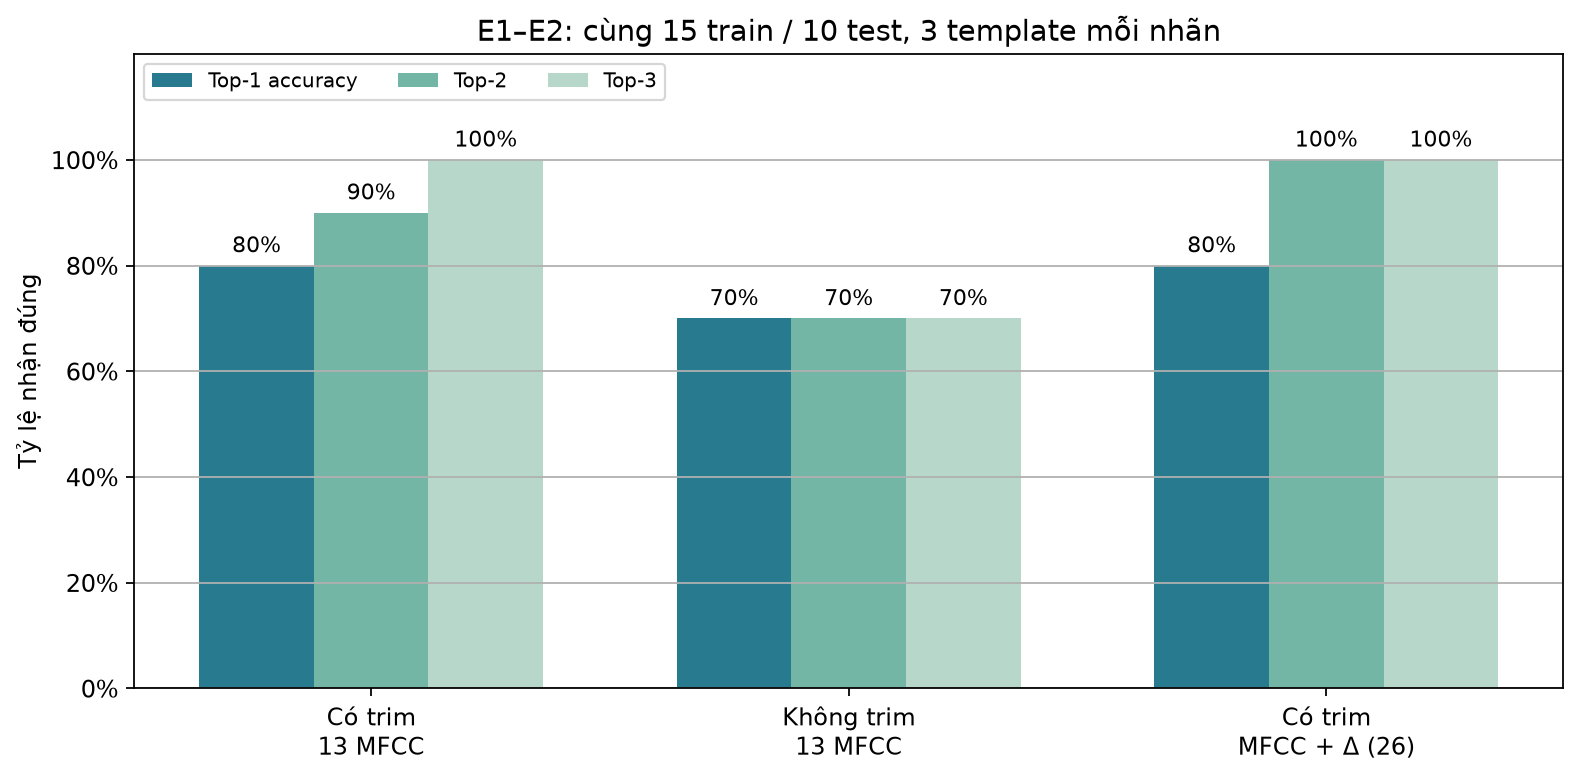

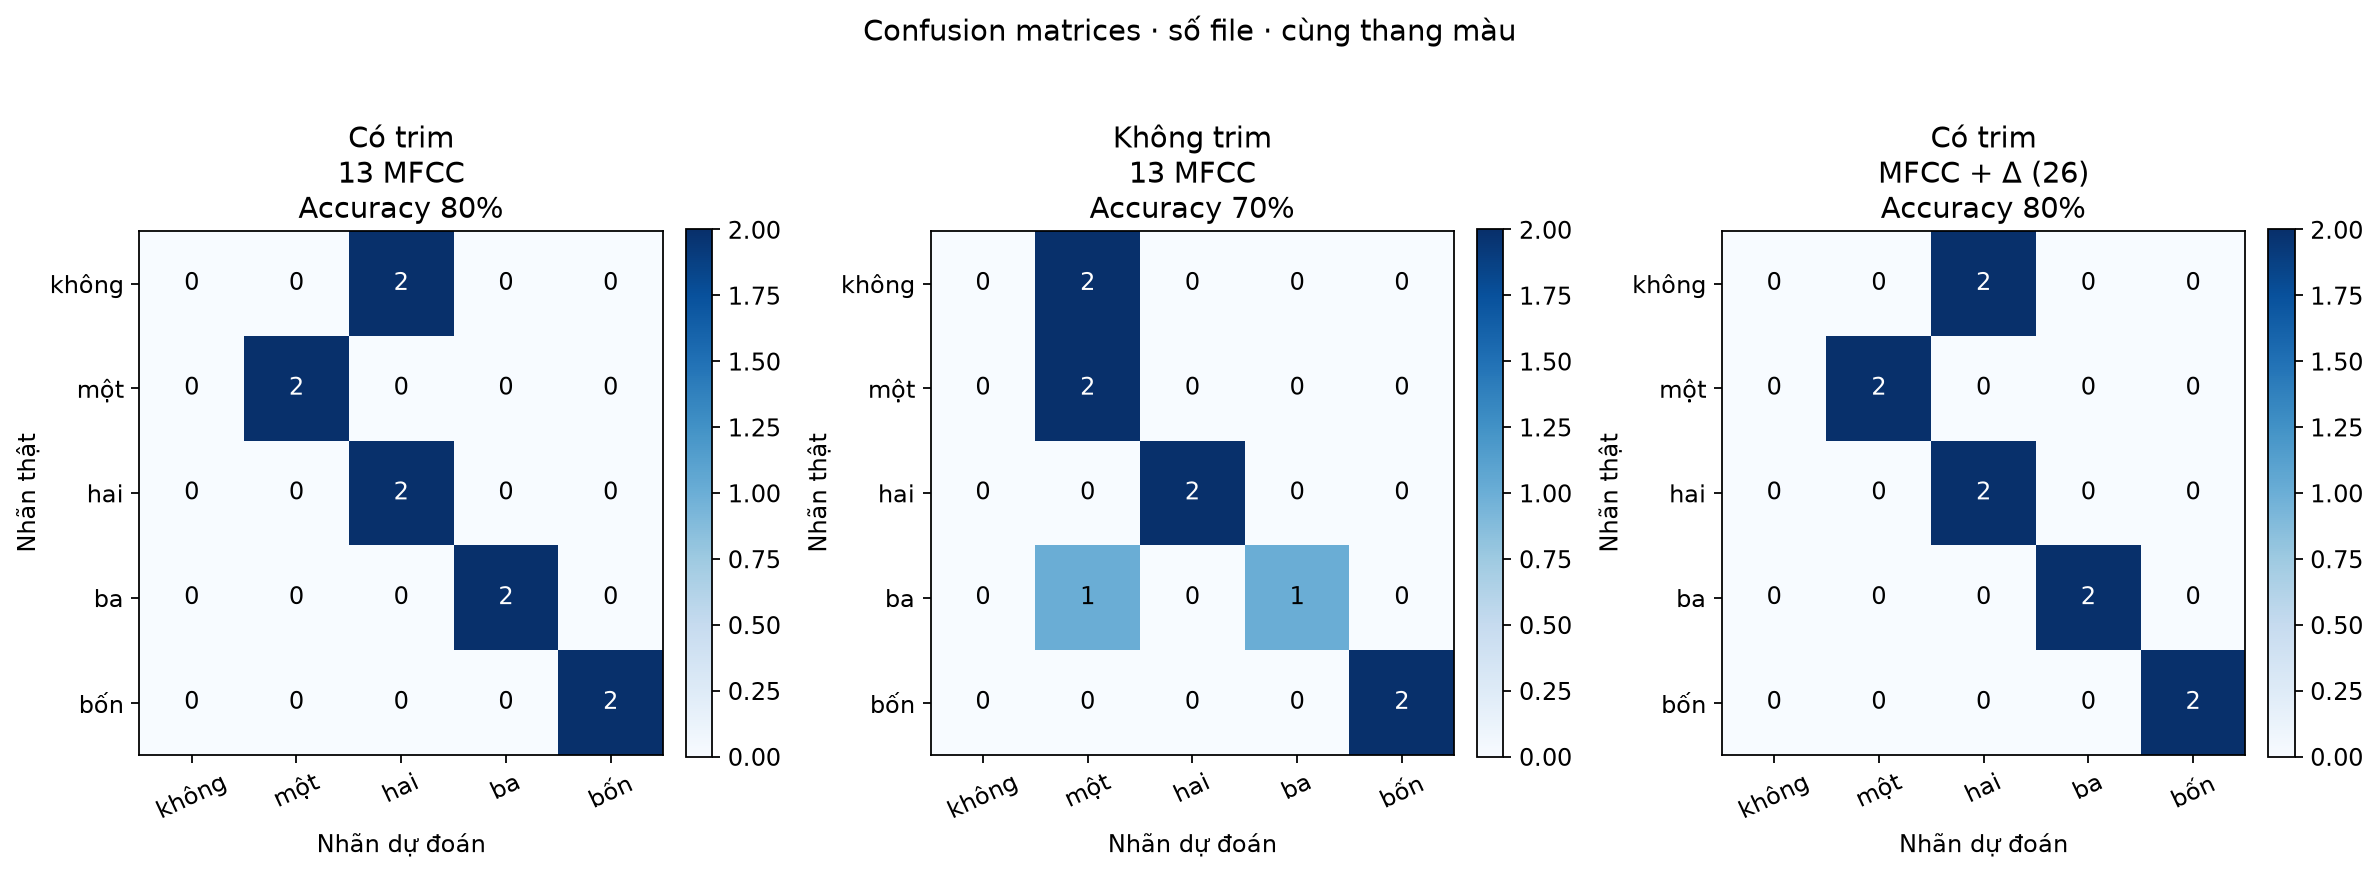

| file | true_label | trim_mfcc13_prediction | no_trim_mfcc13_prediction | trim_mfcc_delta26_prediction | trim_mfcc13_true_rank | no_trim_mfcc13_true_rank | trim_mfcc_delta26_true_rank |
| --- | --- | --- | --- | --- | --- | --- | --- |
| khong/khong_04.wav | khong | hai | mot | hai | 3 | 4 | 2 |
| khong/khong_05.wav | khong | hai | mot | hai | 2 | 4 | 2 |
| mot/mot_04.wav | mot | mot | mot | mot | 1 | 1 | 1 |
| mot/mot_05.wav | mot | mot | mot | mot | 1 | 1 | 1 |
| hai/hai_04.wav | hai | hai | hai | hai | 1 | 1 | 1 |
| hai/hai_05.wav | hai | hai | hai | hai | 1 | 1 | 1 |
| ba/ba_04.wav | ba | ba | ba | ba | 1 | 1 | 1 |
| ba/ba_05.wav | ba | ba | mot | ba | 1 | 5 | 1 |
| bon/bon_04.wav | bon | bon | bon | bon | 1 | 1 | 1 |
| bon/bon_05.wav | bon | bon | bon | bon | 1 | 1 | 1 |

| variant | file | true_label | baseline_prediction | variant_prediction | status | baseline_true_rank | variant_true_rank |
| --- | --- | --- | --- | --- | --- | --- | --- |
| no_trim_mfcc13 | khong/khong_04.wav | khong | hai | mot | still_wrong | 3 | 4 |
| no_trim_mfcc13 | khong/khong_05.wav | khong | hai | mot | still_wrong | 2 | 4 |
| no_trim_mfcc13 | ba/ba_05.wav | ba | ba | mot | new_error | 1 | 5 |
| trim_mfcc_delta26 | khong/khong_04.wav | khong | hai | hai | still_wrong | 3 | 2 |
| trim_mfcc_delta26 | khong/khong_05.wav | khong | hai | hai | still_wrong | 2 | 2 |

In [38]:
EXPERIMENT_NAMES = [variant["name"] for variant in VARIANTS]
EXPERIMENT_TITLES = {"trim_mfcc13": "Có trim\n13 MFCC", "no_trim_mfcc13": "Không trim\n13 MFCC",
                     "trim_mfcc_delta26": "Có trim\nMFCC + Δ (26)"}
fig, ax = plt.subplots(figsize=(10, 5), dpi=160)
positions = np.arange(3)
width = .24
for offset, key, title, color in [(-width, "accuracy", "Top-1 accuracy", "#287b8e"),
                                (0, "top2_accuracy", "Top-2", "#73b6a5"),
                                (width, "top3_accuracy", "Top-3", "#b6d7ca")]:
    values = [row[key] for row in EXPERIMENT_SUMMARY]
    ax.bar(positions + offset, values, width, color=color, label=title)
    for x, value in zip(positions + offset, values):
        ax.text(x, value + .015, f"{value:.0%}", ha="center", va="bottom", fontsize=10)
ax.set_xticks(positions, [EXPERIMENT_TITLES[name] for name in EXPERIMENT_NAMES])
ax.set(title="E1–E2: cùng 15 train / 10 test, 3 template mỗi nhãn", ylabel="Tỷ lệ nhận đúng",
       ylim=(0, 1.2))
ax.set_yticks(np.arange(0, 1.01, .2), [f"{x:.0%}" for x in np.arange(0, 1.01, .2)])
ax.legend(loc="upper left", ncol=3, fontsize=9)
ax.grid(axis="x", visible=False)
fig.canvas.draw()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase9_accuracy_comparison.png", dpi=160, bbox_inches="tight", pad_inches=.2)
plt.show()
plt.close(fig)

fig, axes = plt.subplots(1, 3, figsize=(15, 5.4), dpi=160)
maximum = max(np.max(EXPERIMENT_RUNS[name]["metrics"]["confusion_matrix"]) for name in EXPERIMENT_NAMES)
for ax, name in zip(axes, EXPERIMENT_NAMES):
    metrics = EXPERIMENT_RUNS[name]["metrics"]
    matrix = np.array(metrics["confusion_matrix"])
    im = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=maximum)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, str(matrix[i,j]), ha="center", va="center",
                    color="white" if matrix[i,j] > maximum/2 else "black", fontsize=11)
    ax.set_xticks(range(5), [LABEL_NAMES[label] for label in LABELS], rotation=25)
    ax.set_yticks(range(5), [LABEL_NAMES[label] for label in LABELS])
    ax.set(title=f"{EXPERIMENT_TITLES[name]}\nAccuracy {metrics['accuracy']:.0%}",
           xlabel="Nhãn dự đoán", ylabel="Nhãn thật")
    ax.grid(False)
    fig.colorbar(im, ax=ax, fraction=.046, pad=.04)
fig.suptitle("Confusion matrices · số file · cùng thang màu")
fig.canvas.draw()
fig.tight_layout(rect=(0, 0, 1, .93))
fig.savefig(FIGURES_DIR / "phase9_confusion_matrices.png", dpi=160, bbox_inches="tight", pad_inches=.2)
plt.show()
plt.close(fig)

CHANGE_ROWS = comparison_changes(EXPERIMENT_RUNS)
write_csv(PROJECT_ROOT / "outputs/phase9_prediction_changes.csv", CHANGE_ROWS, list(CHANGE_ROWS[0]))
WIDE_ROWS = []
for base in EXPERIMENT_RUNS["trim_mfcc13"]["rows"]:
    row = {"file": base["file"], "true_label": base["true_label"]}
    for name in EXPERIMENT_NAMES:
        result = next(r for r in EXPERIMENT_RUNS[name]["rows"] if r["file"] == base["file"])
        row.update({f"{name}_prediction": result["predicted_label"], f"{name}_correct": result["correct"],
                    f"{name}_true_rank": result["true_label_rank"]})
    WIDE_ROWS.append(row)
write_csv(PROJECT_ROOT / "outputs/phase9_query_comparison.csv", WIDE_ROWS, list(WIDE_ROWS[0]))
show_table(WIDE_ROWS, ["file", "true_label", *[f"{name}_prediction" for name in EXPERIMENT_NAMES],
                      *[f"{name}_true_rank" for name in EXPERIMENT_NAMES]])
show_table([r for r in CHANGE_ROWS if r["status"] != "still_correct"],
           ["variant", "file", "true_label", "baseline_prediction", "variant_prediction", "status",
            "baseline_true_rank", "variant_true_rank"])

### G7. Minh họa Δ và đường đi DTW trong E1/E2

Minh họa feature trên `khong_04.wav` (đã dùng trong Phase 8). Δ nhấn mạnh thay đổi qua frame; khi feature gần hằng, Δ gần 0. Hai heatmap MFCC/Δ có **thang màu riêng**, ghi rõ đơn vị.

Đối chiếu path trên cùng query/template để tách ảnh hưởng pipeline:

- E1: `khong_04` với `khong_02`/`hai_02`; thêm `ba_05` với `ba_02`/`mot_03` để phân tích file đổi đúng/sai. Trường hợp ba chọn sau khi quan sát thay đổi dự đoán, chỉ để giải thích, không chọn tham số.
- E2: `khong_04` với `khong_02`/`hai_02`, giữ endpoint và số frame.

Khung trắng trên local-distance matrix đánh dấu các frame nằm trong vùng giữ lại của endpoint baseline. Với full WAV, tỷ lệ path ngoài vùng này **không phải tỷ lệ silence đã gán nhãn**: có thể gồm nền, click hoặc phụ âm yếu. Đây là dấu hiệu path dành bước cho phần bị endpoint loại, không chứng minh endpoint đúng tuyệt đối.

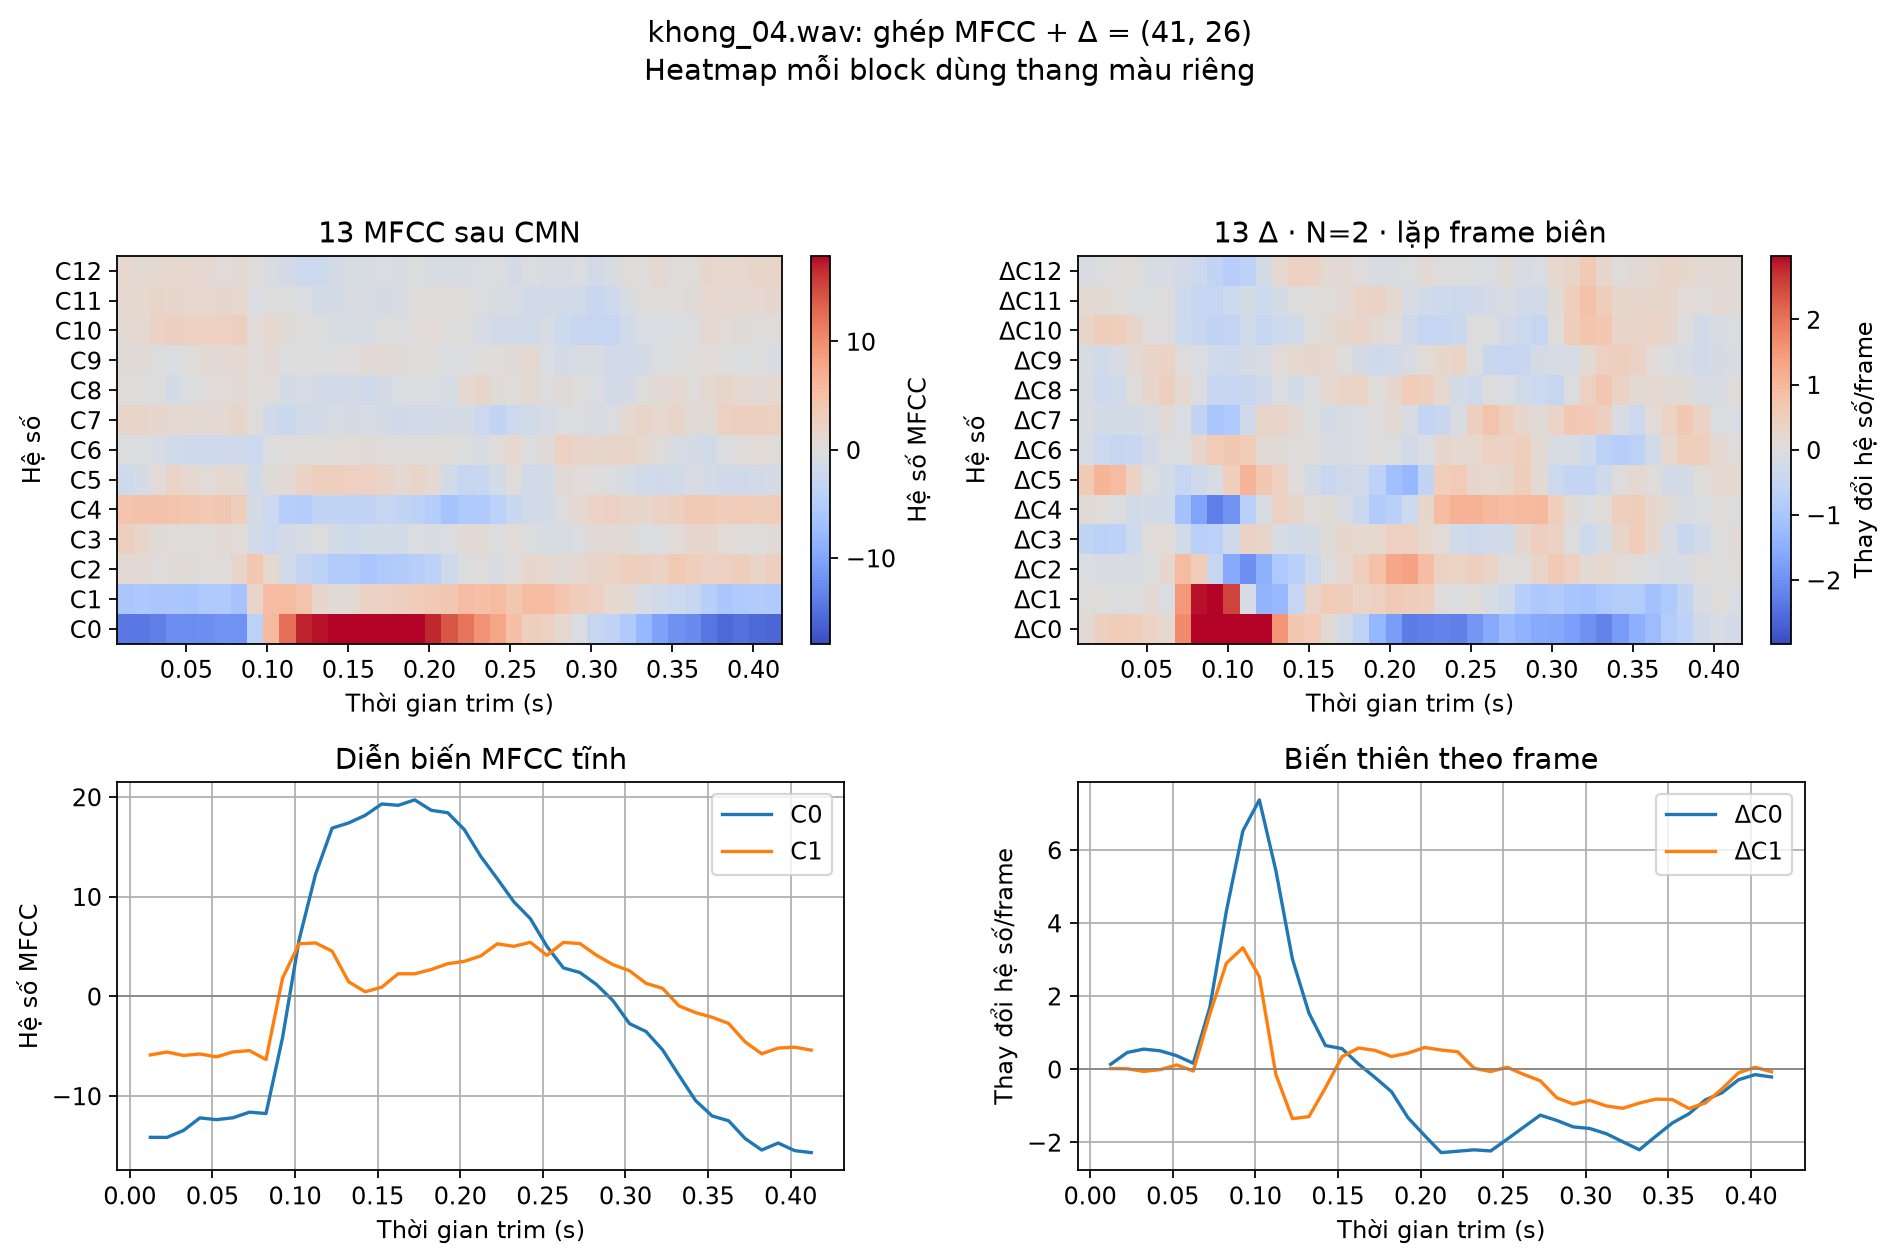

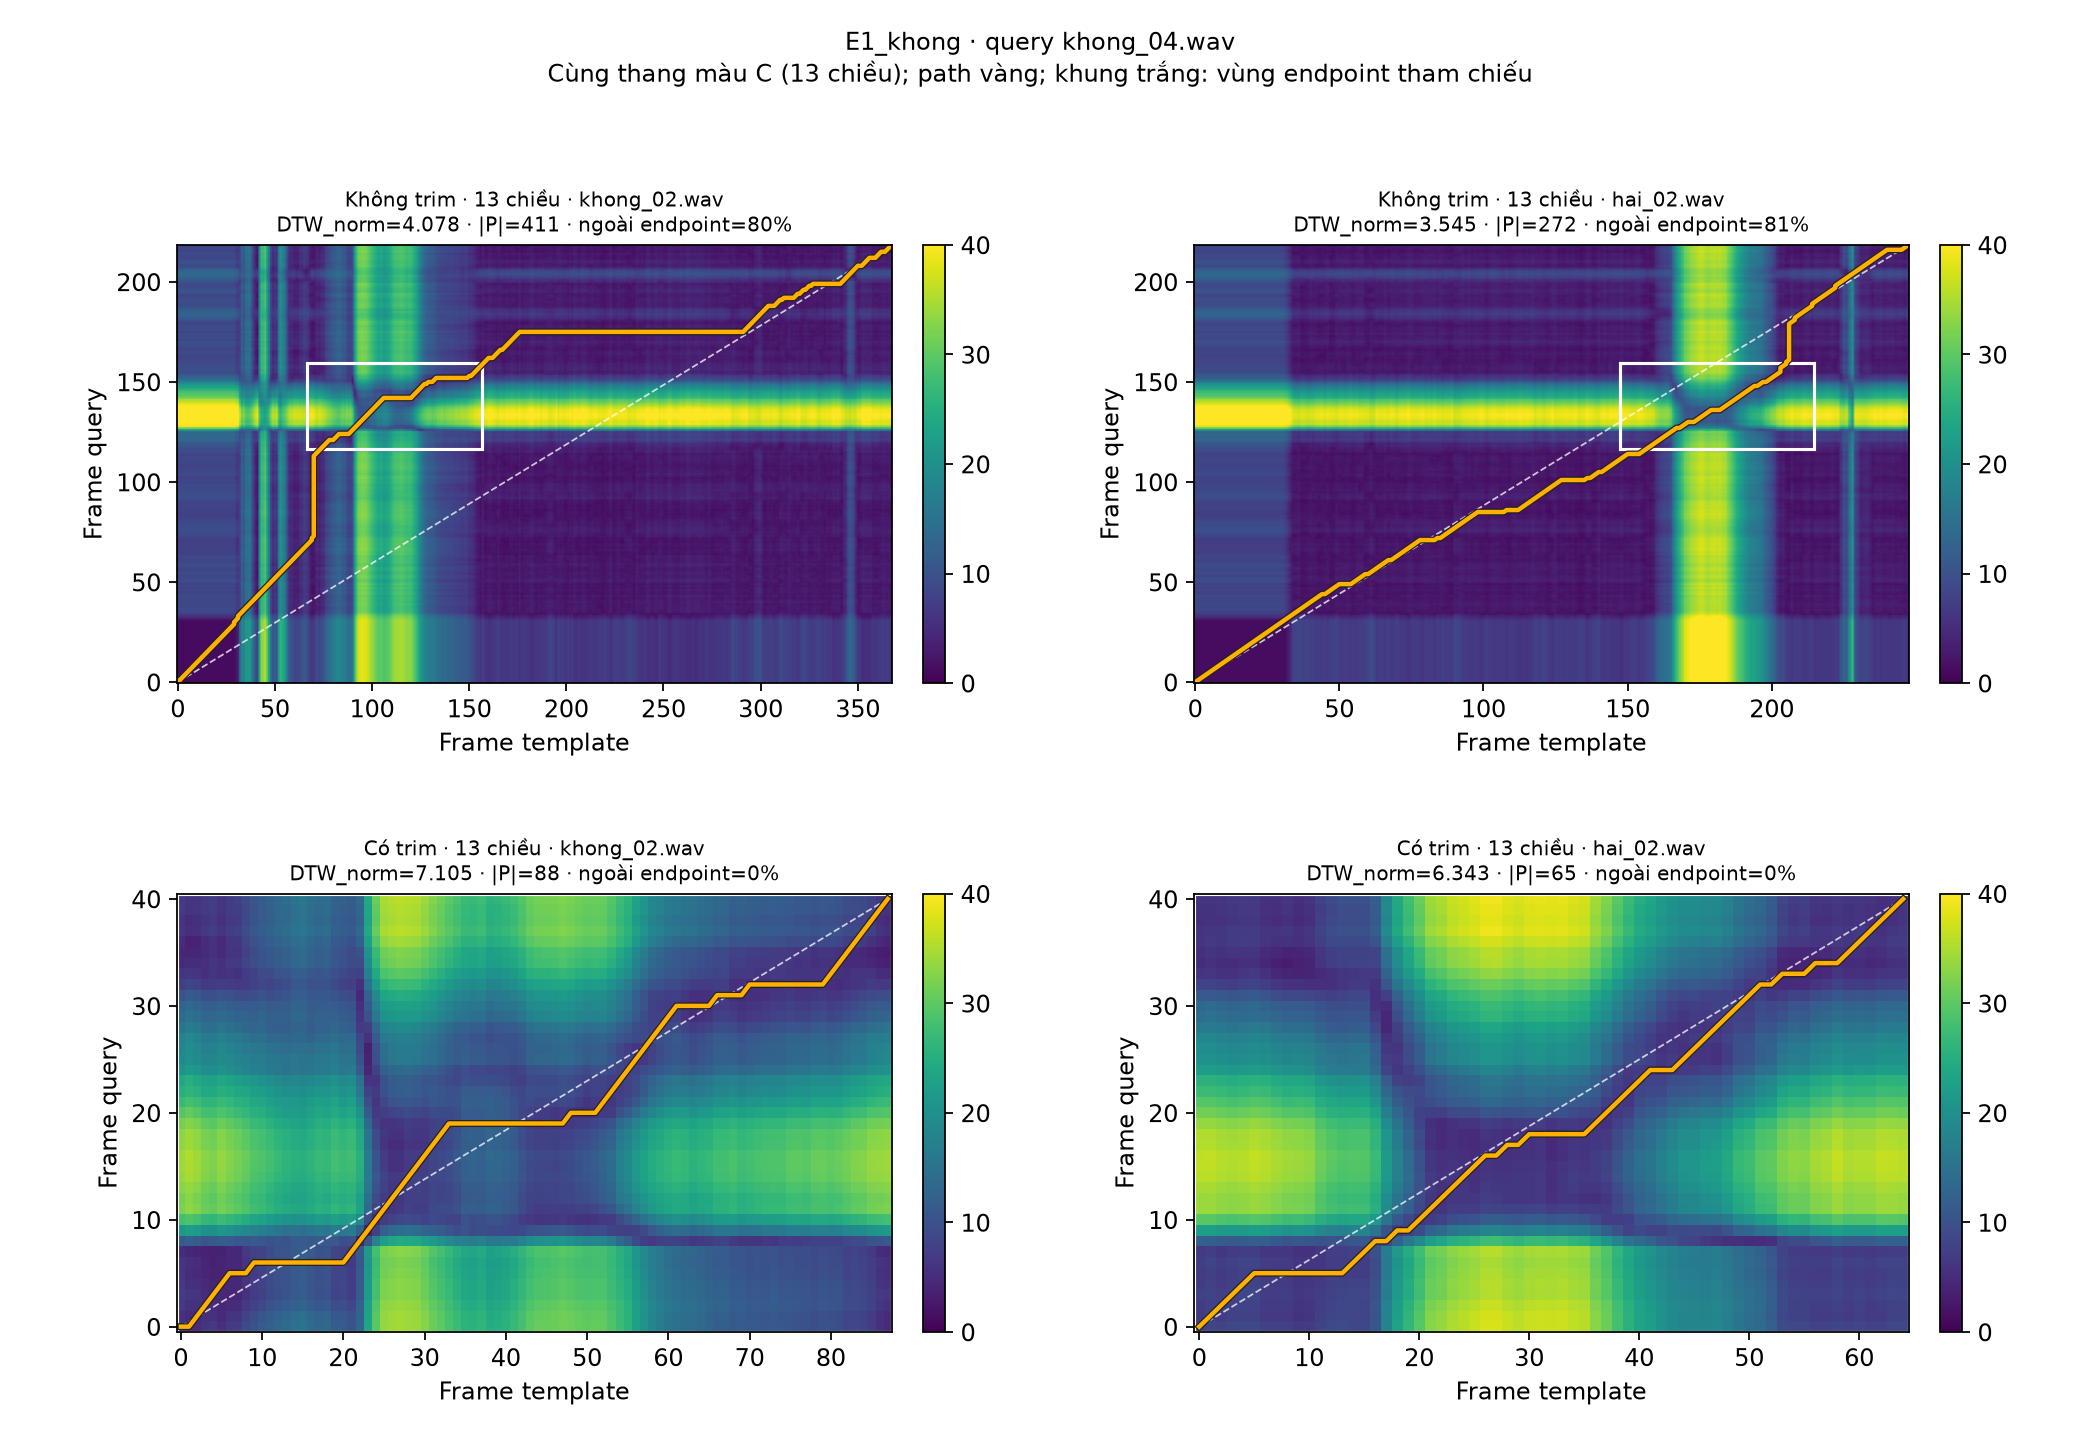

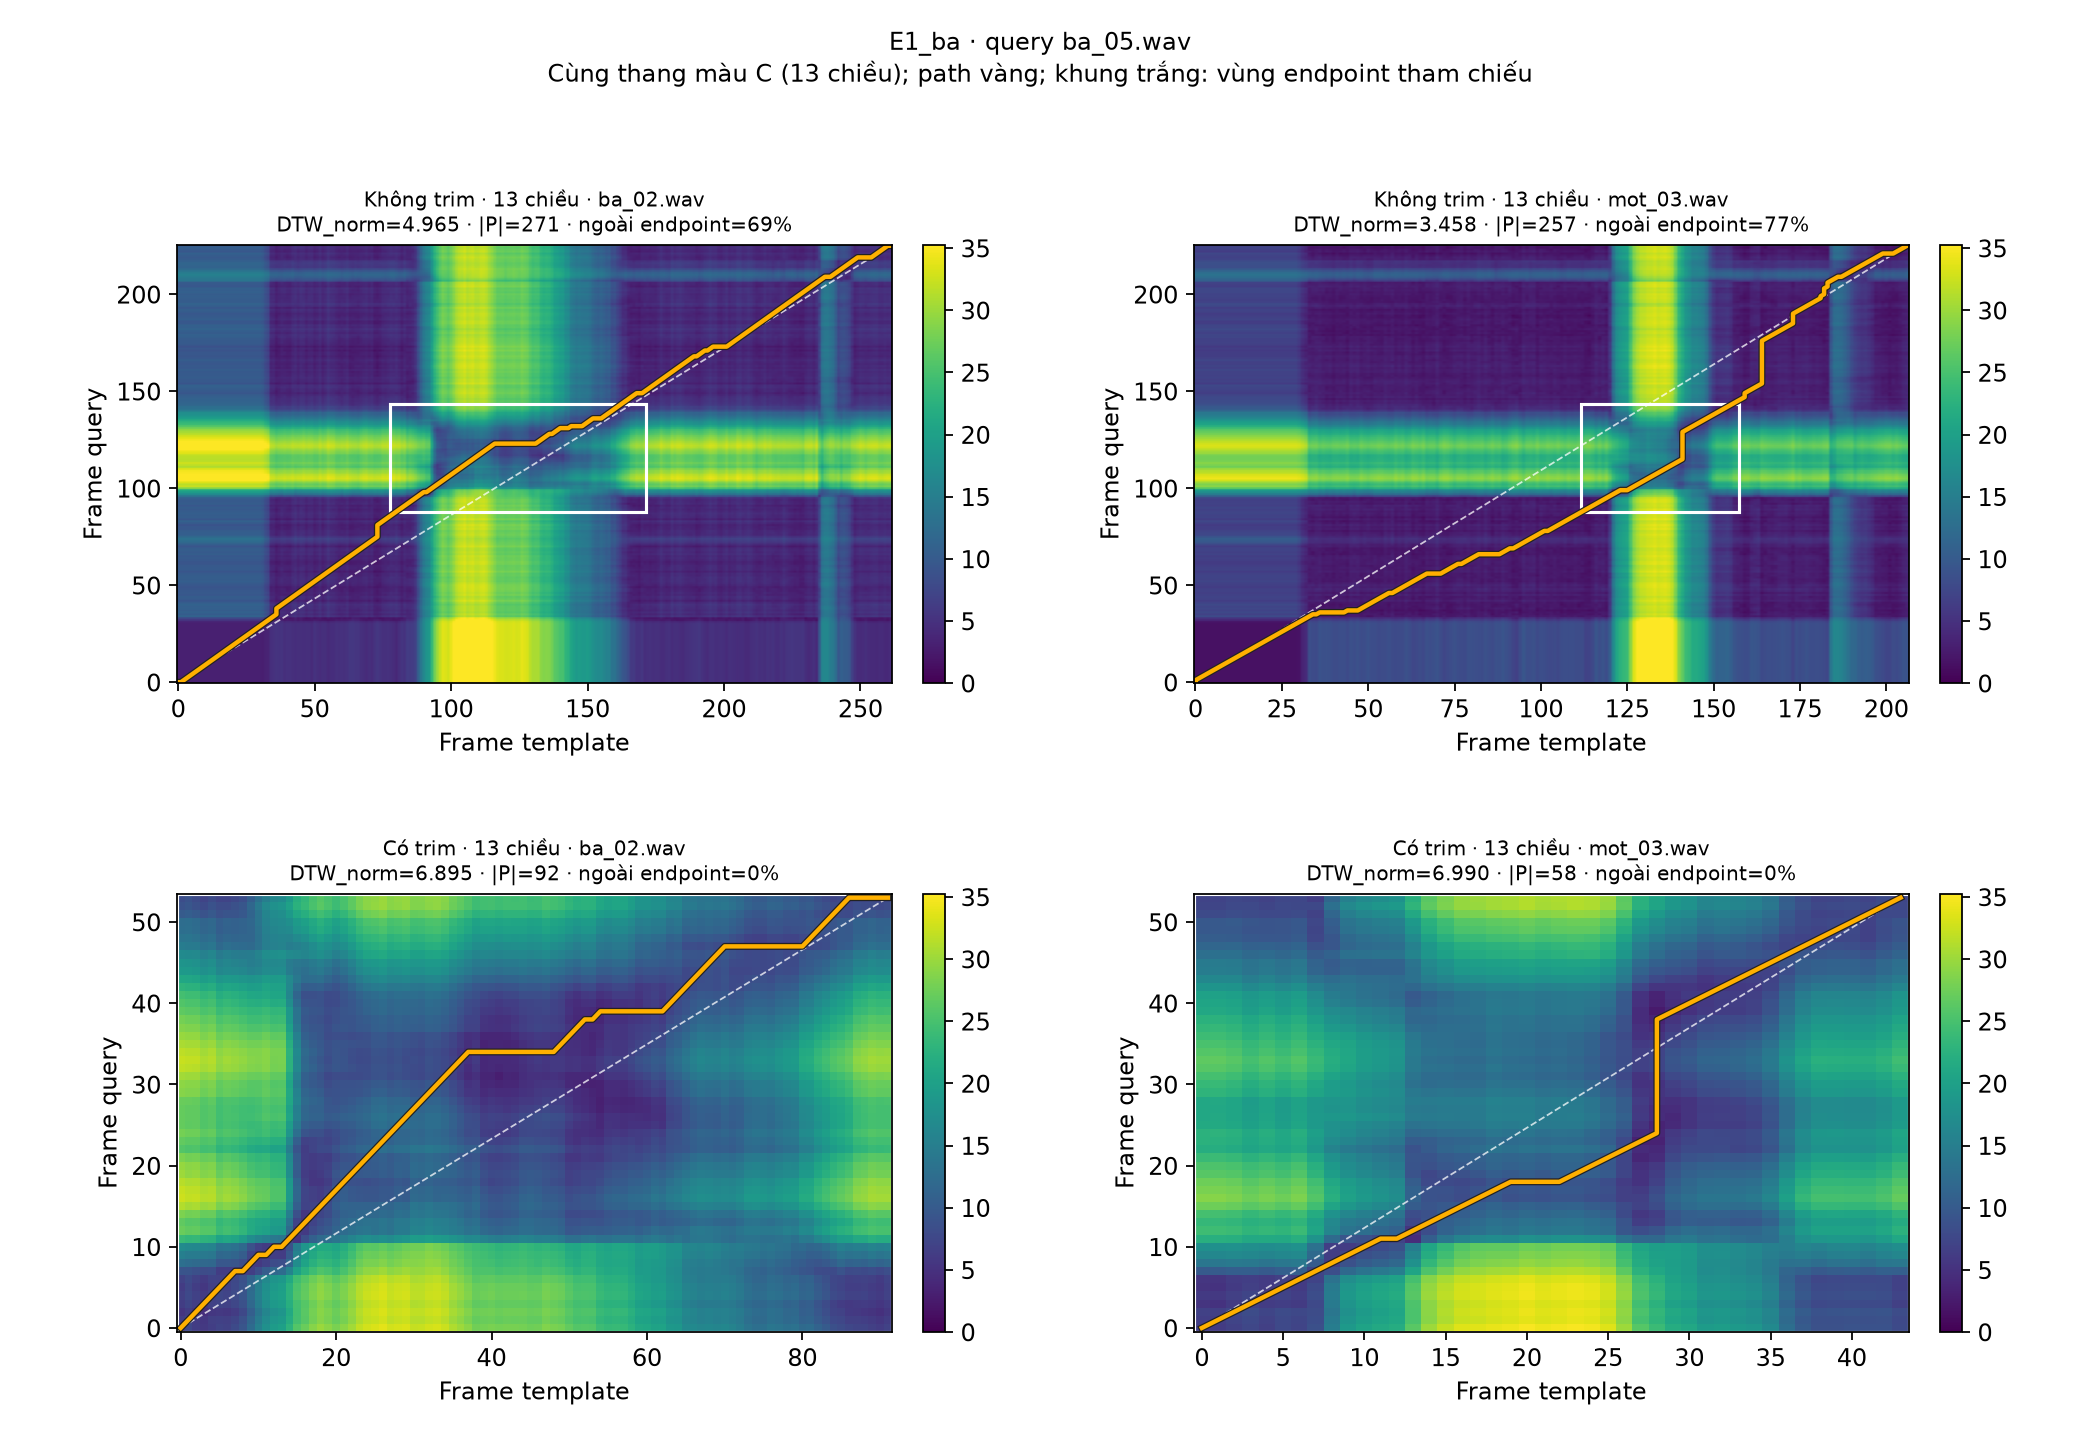

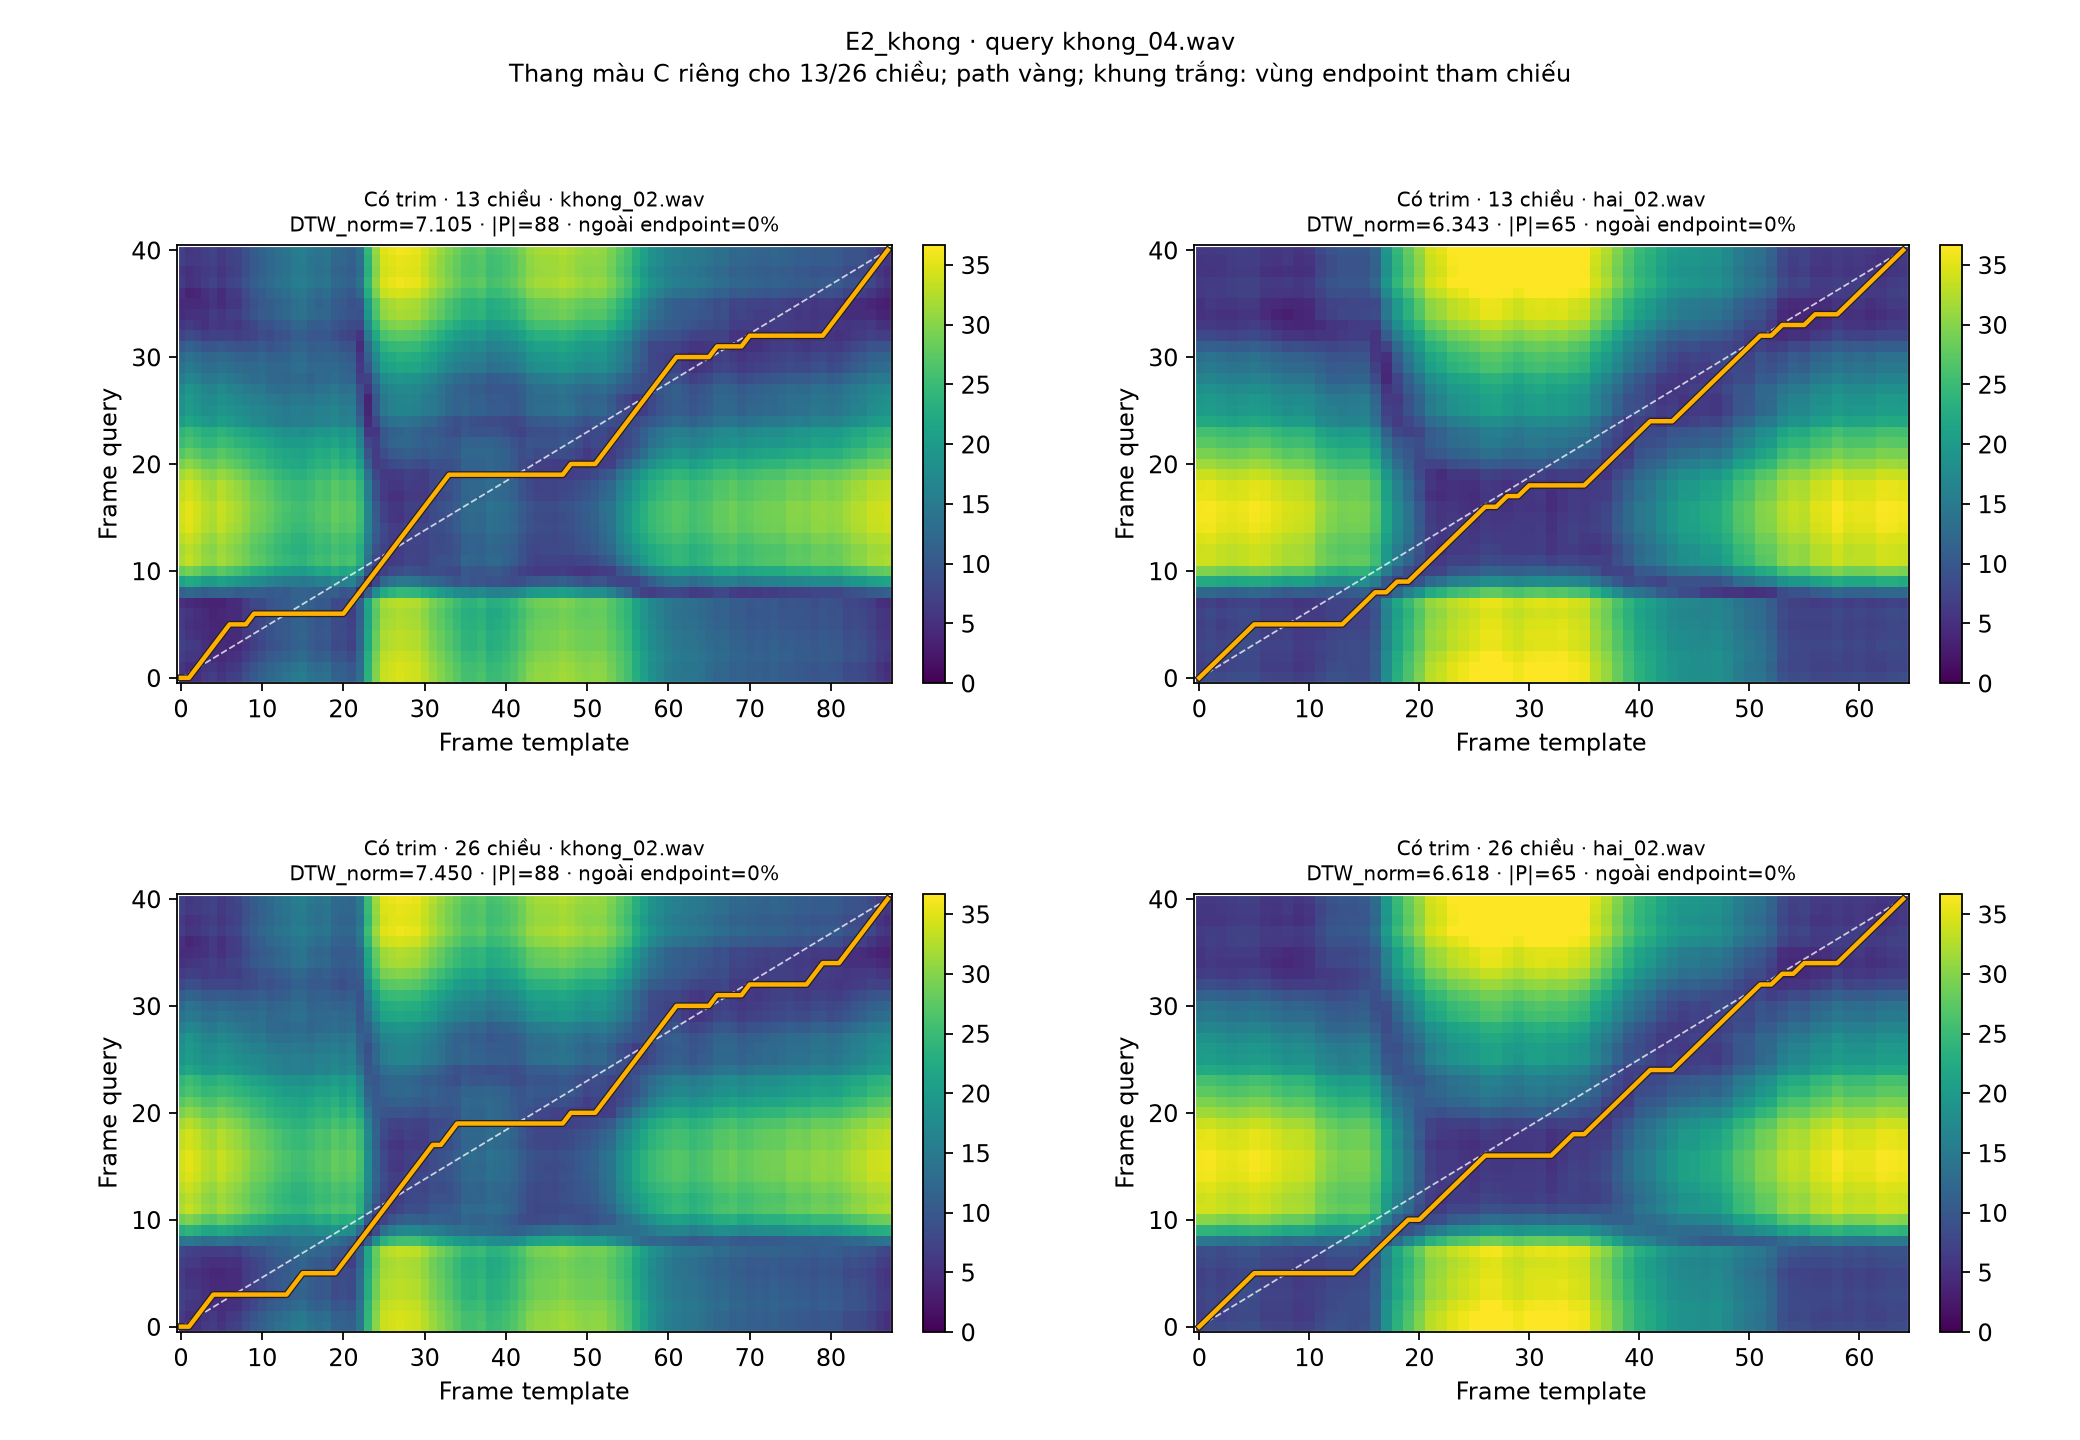

| case | variant | query_file | template_file | query_frames | template_frames | dimensions | dtw_norm | path_length | path_fraction_either_outside_endpoint |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| E1_khong | no_trim_mfcc13 | khong/khong_04.wav | khong/khong_02.wav | 219 | 368 | 13 | 4.078 | 411 | 79.8% |
| E1_khong | no_trim_mfcc13 | khong/khong_04.wav | hai/hai_02.wav | 219 | 248 | 13 | 3.545 | 272 | 81.2% |
| E1_khong | trim_mfcc13 | khong/khong_04.wav | khong/khong_02.wav | 41 | 88 | 13 | 7.105 | 88 | 0.0% |
| E1_khong | trim_mfcc13 | khong/khong_04.wav | hai/hai_02.wav | 41 | 65 | 13 | 6.343 | 65 | 0.0% |
| E1_ba | no_trim_mfcc13 | ba/ba_05.wav | ba/ba_02.wav | 226 | 262 | 13 | 4.965 | 271 | 69.4% |
| E1_ba | no_trim_mfcc13 | ba/ba_05.wav | mot/mot_03.wav | 226 | 207 | 13 | 3.458 | 257 | 77.4% |
| E1_ba | trim_mfcc13 | ba/ba_05.wav | ba/ba_02.wav | 54 | 92 | 13 | 6.895 | 92 | 0.0% |
| E1_ba | trim_mfcc13 | ba/ba_05.wav | mot/mot_03.wav | 54 | 44 | 13 | 6.990 | 58 | 0.0% |
| E2_khong | trim_mfcc13 | khong/khong_04.wav | khong/khong_02.wav | 41 | 88 | 13 | 7.105 | 88 | 0.0% |
| E2_khong | trim_mfcc13 | khong/khong_04.wav | hai/hai_02.wav | 41 | 65 | 13 | 6.343 | 65 | 0.0% |
| E2_khong | trim_mfcc_delta26 | khong/khong_04.wav | khong/khong_02.wav | 41 | 88 | 26 | 7.450 | 88 | 0.0% |
| E2_khong | trim_mfcc_delta26 | khong/khong_04.wav | hai/hai_02.wav | 41 | 65 | 26 | 6.618 | 65 | 0.0% |

In [39]:
DELTA_EXAMPLE = "khong/khong_04.wav"
example = EXPERIMENT_RUNS["trim_mfcc_delta26"]["features"][DELTA_EXAMPLE]
times = example["times"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=160)
for ax, matrix, title, prefix, unit in [
        (axes[0,0], example["static_mfcc"], "13 MFCC sau CMN", "C", "Hệ số MFCC"),
        (axes[0,1], example["delta"], "13 Δ · N=2 · lặp frame biên", "ΔC", "Thay đổi hệ số/frame")]:
    limit = max(1e-6, float(np.percentile(np.abs(matrix), 99)))
    im = ax.imshow(matrix.T, origin="lower", aspect="auto", cmap="coolwarm", vmin=-limit, vmax=limit,
                   extent=(times[0]-HOP/FS/2, times[-1]+HOP/FS/2, -.5, 12.5))
    ax.set(title=title, xlabel="Thời gian trim (s)", ylabel="Hệ số")
    ax.set_yticks(range(13), [f"{prefix}{i}" for i in range(13)])
    ax.grid(False)
    fig.colorbar(im, ax=ax, label=unit, fraction=.046, pad=.04)
for i in (0, 1):
    axes[1,0].plot(times, example["static_mfcc"][:,i], label=f"C{i}")
    axes[1,1].plot(times, example["delta"][:,i], label=f"ΔC{i}")
for ax, title, ylabel in [(axes[1,0], "Diễn biến MFCC tĩnh", "Hệ số MFCC"),
                          (axes[1,1], "Biến thiên theo frame", "Thay đổi hệ số/frame")]:
    ax.axhline(0, color="gray", linewidth=.7)
    ax.set(title=title, xlabel="Thời gian trim (s)", ylabel=ylabel)
    ax.legend()
fig.suptitle(f"{Path(DELTA_EXAMPLE).name}: ghép MFCC + Δ = {example['features'].shape}\nHeatmap mỗi block dùng thang màu riêng")
fig.canvas.draw()
fig.tight_layout(rect=(0, 0, 1, .92))
fig.savefig(FIGURES_DIR / "phase9_delta_example.png", dpi=160, bbox_inches="tight", pad_inches=.2)
plt.show()
plt.close(fig)

PATH_CASE_SPECS = [
    ("E1_khong", "khong/khong_04.wav", ["khong/khong_02.wav", "hai/hai_02.wav"],
     ["no_trim_mfcc13", "trim_mfcc13"]),
    ("E1_ba", "ba/ba_05.wav", ["ba/ba_02.wav", "mot/mot_03.wav"],
     ["no_trim_mfcc13", "trim_mfcc13"]),
    ("E2_khong", "khong/khong_04.wav", ["khong/khong_02.wav", "hai/hai_02.wav"],
     ["trim_mfcc13", "trim_mfcc_delta26"])]
PATH_COMPARISON_ROWS = []
EXPERIMENT_PATH_DIR = PROJECT_ROOT / "features" / "experiment_paths"
EXPERIMENT_PATH_DIR.mkdir(parents=True, exist_ok=True)
from matplotlib.patches import Rectangle
from matplotlib import patheffects
from matplotlib.backends.backend_agg import FigureCanvasAgg
from IPython.display import Image as NotebookImage

for case, query_file, template_files, variant_names in PATH_CASE_SPECS:
    panels = []
    for name in variant_names:
        for template_file in template_files:
            details, row = path_case(EXPERIMENT_RUNS, name, query_file, template_file)
            validate_dtw_path(details, row["query_frames"], row["template_frames"])
            row = {"case": case, **row}
            PATH_COMPARISON_ROWS.append(row)
            panels.append((name, template_file, details, row))
            stem = f"{case}_{name}_{Path(template_file).stem}"
            np.savez_compressed(EXPERIMENT_PATH_DIR / f"{stem}.npz", local_distance=details["local_distance"],
                                accumulated_cost=details["accumulated_cost"], path=np.array(details["path"]),
                                config_json=json.dumps(EXPERIMENT_RUNS[name]["config"], ensure_ascii=False),
                                query_file=query_file, template_file=template_file,
                                total_cost=details["total_cost"], normalized_cost=details["normalized_cost"])
            path_rows = [{"step": step, "query_frame": i, "template_frame": j,
                          "local_cost": details["local_distance"][i,j],
                          "accumulated_cost": details["accumulated_cost"][i,j]}
                         for step, (i, j) in enumerate(details["path"])]
            write_csv(PROJECT_ROOT / "experiments" / "phase9" / f"path_{stem}.csv", path_rows, list(path_rows[0]))
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), dpi=160)
    FigureCanvasAgg(fig)
    # E1 shares dimensions/color range; E2 uses separate ranges for 13 vs 26 dimensions.
    limits = {}
    for dimension in {row[3]["dimensions"] for row in panels}:
        values = np.concatenate([p[2]["local_distance"].ravel() for p in panels if p[3]["dimensions"] == dimension])
        limits[dimension] = max(1e-6, float(np.percentile(values, 99)))
    for ax, (name, template_file, details, row) in zip(axes.ravel(), panels):
        matrix = details["local_distance"]
        path_array = np.array(details["path"])
        N, M = matrix.shape
        im = ax.imshow(matrix, origin="lower", aspect="auto", cmap="viridis", vmin=0, vmax=limits[row["dimensions"]])
        ax.plot([0, M-1], [0, N-1], "--", color="white", linewidth=.8, alpha=.75)
        ax.plot(path_array[:,1], path_array[:,0], color="#ffb000", linewidth=2,
                path_effects=[patheffects.Stroke(linewidth=3.1, foreground="#222"), patheffects.Normal()])
        kept_ranges = []
        for file in [query_file, template_file]:
            current = EXPERIMENT_RUNS[name]["features"][file]
            reference = EXPERIMENT_RUNS["trim_mfcc13"]["features"][file]
            absolute_times = current["times"] + current["start_sample"]/FS
            kept = np.flatnonzero((absolute_times >= reference["start_sample"]/FS) &
                                  (absolute_times < reference["end_sample"]/FS))
            kept_ranges.append((kept[0], kept[-1]))
        (qa, qb), (ta, tb) = kept_ranges
        ax.add_patch(Rectangle((ta-.5, qa-.5), tb-ta+1, qb-qa+1, fill=False, edgecolor="white", linewidth=1.4))
        description = "Không trim" if not EXPERIMENT_RUNS[name]["config"]["variant"]["trim"] else "Có trim"
        ax.set(title=f"{description} · {row['dimensions']} chiều · {Path(template_file).name}\n"
                     f"DTW_norm={row['dtw_norm']:.3f} · |P|={row['path_length']} · ngoài endpoint={row['path_fraction_either_outside_endpoint']:.0%}",
               xlabel="Frame template", ylabel="Frame query")
        ax.title.set_fontsize(9)
        ax.grid(False)
        fig.colorbar(im, ax=ax, fraction=.046, pad=.04)
    note = "Cùng thang màu C (13 chiều)" if case.startswith("E1") else "Thang màu C riêng cho 13/26 chiều"
    fig.suptitle(f"{case} · query {Path(query_file).name}\n{note}; path vàng; khung trắng: vùng endpoint tham chiếu", fontsize=11)
    # Fixed margins avoid inconsistent tight bounding boxes after inline rendering.
    fig.subplots_adjust(left=.085, right=.95, bottom=.075, top=.83, wspace=.30, hspace=.48)
    fig.set_dpi(100)
    fig.set_dpi(160)
    fig.canvas.draw()
    saved_path = FIGURES_DIR / f"phase9_{case}_paths.png"
    fig.savefig(saved_path, dpi=160)
    plt.close(fig)
    display(NotebookImage(filename=str(saved_path)))

write_csv(PROJECT_ROOT / "outputs/phase9_path_comparison.csv", PATH_COMPARISON_ROWS, list(PATH_COMPARISON_ROWS[0]))
show_table([{**r, "dtw_norm": f"{r['dtw_norm']:.3f}",
                  "path_fraction_either_outside_endpoint": f"{r['path_fraction_either_outside_endpoint']:.1%}"}
            for r in PATH_COMPARISON_ROWS],
           ["case", "variant", "query_file", "template_file", "query_frames", "template_frames", "dimensions",
            "dtw_norm", "path_length", "path_fraction_either_outside_endpoint"])

### G8. Nhận xét E1–E2, giới hạn và tái lập

Các nhận xét bên dưới dùng bảng dự đoán và metric thực tế, không đặt kỳ vọng rằng mọi feature bổ sung phải tăng accuracy. Số file test chỉ 10; một thay đổi đúng/sai tương ứng 10 điểm phần trăm. Không dùng các kết quả để chọn lại split, cửa sổ Δ hoặc ngưỡng reject.

E3 (1 template vs 3) là tùy chọn, chưa thực hiện; E4 cần nhãn người nói và dữ liệu hai người, hiện chưa có metadata để đánh giá cross-speaker. Hai thí nghiệm bắt buộc E1/E2 đã có đủ đối chứng. Phase 10 sẽ tổng hợp báo cáo và trả lời câu hỏi.

CLI tái lập bảng/chỉ số và feature của ba cấu hình (notebook bổ sung hình, path và báo cáo):

```powershell
.\.venv-lab2\Scripts\python.exe -X utf8 lab2_experiments.py
```

4 unittest kiểm tra công thức Δ bằng ramp có đáp án biết trước, biên/constant/input lỗi, việc chỉ đổi một yếu tố và xếp hạng 13/26 chiều. Run All kiểm tra thêm cache/feature của cả 25 file và tái lập baseline Phase 8.

In [40]:
CONTROL_METRICS = EXPERIMENT_RUNS["trim_mfcc13"]["metrics"]
FULL_METRICS = EXPERIMENT_RUNS["no_trim_mfcc13"]["metrics"]
DELTA_METRICS = EXPERIMENT_RUNS["trim_mfcc_delta26"]["metrics"]
E1_GAIN_PP = 100*(CONTROL_METRICS["accuracy"] - FULL_METRICS["accuracy"])
E2_GAIN_PP = 100*(DELTA_METRICS["accuracy"] - CONTROL_METRICS["accuracy"])
full_vs_control = [r for r in CHANGE_ROWS if r["variant"] == "no_trim_mfcc13"]
delta_vs_control = [r for r in CHANGE_ROWS if r["variant"] == "trim_mfcc_delta26"]
trim_fixed = [r["file"] for r in full_vs_control if r["status"] == "new_error"]
delta_fixed = [r["file"] for r in delta_vs_control if r["status"] == "fixed"]
delta_new = [r["file"] for r in delta_vs_control if r["status"] == "new_error"]
grid_ratio = FULL_METRICS["dtw_grid_cells"]/CONTROL_METRICS["dtw_grid_cells"]

lines = ["# Phase 9 — Thí nghiệm đối chứng E1–E2", "",
         "Cùng split 15 train + 10 test, 3 template/nhãn. Mỗi cấu hình tính mới feature của cả 25 file. "
         "Đối chứng trim + 13 MFCC tái lập Phase 8; không thay kết quả baseline results.csv.",
         "", "## Thiết kế và Δ", "",
         "- E1: no_trim_mfcc13 vs trim_mfcc13; chỉ bật/tắt endpoint cho cả train/test.",
         "- E2: trim_mfcc13 vs trim_mfcc_delta26; giữ endpoint, chỉ ghép thêm 13 Δ.",
         "- MFCC tĩnh: frame400/hop160, Hamming, alpha0.97, FFT512, 24 Mel, 13 hệ số C0–C12, CMN từng utterance.",
         "- Δ bậc 1: sum[n*(c[t+n]-c[t-n])]/(2*sum[n²]), n=1..2; mẫu biên lặp; trọng số 1. "
         "Tính trên MFCC đã CMN, không CMN block Δ lần nữa, không ΔΔ; đơn vị thay đổi hệ số/frame.",
         "- Tất cả dùng Euclidean + DTW tự cài tối ưu tổng rồi chia path length; min theo nhãn. "
         "Không thay trọng số/cửa sổ Δ, band hoặc ngưỡng theo test.",
         "", "## Kết quả", "",
         "| Cấu hình | Chiều | Đúng/test | Accuracy | Top-2 | Top-3 | Macro F1 | Tổng frame | Ô DP |",
         "|---|---|---|---|---|---|---|---|---|"]
for row in EXPERIMENT_SUMMARY:
    lines.append(f"| {row['variant']} | {row['dimensions']} | {row['n_correct']}/{row['n_test']} | "
                 f"{row['accuracy']:.0%} | {row['top2_accuracy']:.0%} | {row['top3_accuracy']:.0%} | "
                 f"{row['macro_f1']:.3f} | {row['total_feature_frames']} | {row['dtw_grid_cells']} |")
lines += ["", "## E1 — Endpoint", "",
          f"Có trim đạt {CONTROL_METRICS['accuracy']:.0%}, không trim {FULL_METRICS['accuracy']:.0%}; "
          f"chênh {E1_GAIN_PP:+.0f} điểm phần trăm khi bật endpoint.",
          "",
          "- File được trim sửa lỗi so với no-trim: " + (", ".join(trim_fixed) if trim_fixed else "không có") + ".",
          "- Hai file không vẫn sai: không trim dự đoán một, có trim dự đoán hai. Trim cải thiện tổng thể nhưng chưa giải quyết nhãn không.",
          f"- Full WAV có {EXPERIMENT_SUMMARY[1]['total_feature_frames']} frame so với "
          f"{EXPERIMENT_SUMMARY[0]['total_feature_frames']} sau trim. Số ô DP toàn bộ 150 phép đối sánh tăng {grid_ratio:.2f} lần; "
          "đây là số ô lý thuyết, không phải đo thời gian CPU.",
          "- Với cùng query/template, full path có nhiều bước ngoài vùng endpoint tham chiếu; "
          "score full có thể thấp hơn do nhiều frame nền/độ dài path và CMN toàn utterance. Score nhỏ hơn không tự bảo đảm nhận dạng tốt hơn.",
          "- Ngoài vùng giữ lại không đồng nghĩa silence đã gán nhãn; có thể chứa nhiễu/click hoặc âm yếu. "
          "Chưa xác nhận bằng nghe rằng endpoint giữ mọi phụ âm.",
          "", "## E2 — MFCC + Δ", "",
          f"MFCC + Δ đạt {DELTA_METRICS['accuracy']:.0%}, thay đổi {E2_GAIN_PP:+.0f} điểm phần trăm top-1 so với 13 MFCC.",
          "",
          "- Lỗi được Δ sửa: " + (", ".join(delta_fixed) if delta_fixed else "không có") + "; lỗi mới: " +
          (", ".join(delta_new) if delta_new else "không có") + ".",
          f"- Top-2 tăng {CONTROL_METRICS['top_k_accuracy']['2']:.0%} → {DELTA_METRICS['top_k_accuracy']['2']:.0%}; "
          "khong_04 chuyển nhãn thật từ hạng 3 lên hạng 2. Top-1 của cả 10 query không đổi; hai file không vẫn nhận thành hai.",
          "- Block tĩnh 13 chiều và số frame giữ nguyên ở cả 25 file. Δ bổ sung biến thiên, không bảo đảm tăng accuracy; "
          "trong split này chỉ cải thiện thứ hạng bổ sung. Không so ngưỡng score 13/26 chiều trực tiếp.",
          "", "## Path đối chứng", "",
          "| Thí nghiệm | Cấu hình | Query / template | Shape | DTW_norm | Path | Ngoài vùng endpoint (ít nhất 1 phía) |",
          "|---|---|---|---|---|---|---|"]
for row in PATH_COMPARISON_ROWS:
    lines.append(f"| {row['case']} | {row['variant']} | {Path(row['query_file']).name} / {Path(row['template_file']).name} | "
                 f"{row['query_frames']}×{row['template_frames']}×{row['dimensions']} | {row['dtw_norm']:.3f} | "
                 f"{row['path_length']} | {row['path_fraction_either_outside_endpoint']:.1%} |")
lines += ["", "## Giới hạn và sản phẩm", "",
          "10 test (2/nhãn), một lỗi tương ứng 10 điểm phần trăm accuracy; chưa đánh giá người nói/micro mới. "
          "E4 chưa thực hiện vì chưa có metadata người nói cho hai nhóm; E3 là tùy chọn. "
          "Các cảnh báo endpoint Phase 4 vẫn cần nghe. Không dùng kết quả này để chọn lại split hoặc tối ưu trên test.",
          "", "- lab2_experiments.py; tests/test_lab2_experiments.py (4 kiểm thử đạt); phần G5–G8 notebook.",
          "- experiments/phase9/<variant>/: config, results, metrics, confusion matrices, per-label, full template/label scores, feature summary.",
          "- features/experiments/: 75 NPZ; features/experiment_paths/: 12 NPZ C/D/path; experiments/phase9/path_*.csv.",
          "- outputs/phase9_experiment_summary.csv; outputs/phase9_experiment_config.json; outputs/phase9_all_predictions.csv; outputs/phase9_feature_summary.csv.",
          "- outputs/phase9_prediction_changes.csv; outputs/phase9_query_comparison.csv; outputs/phase9_path_comparison.csv.",
          "- figures/phase9_*.png: accuracy, 3 confusion matrices, Δ, E1 khong/E1 ba/E2 khong paths (6 hình).",
          "", "Phase 10 sẽ tổng hợp báo cáo, trả lời 9 câu hỏi và kiểm tra sản phẩm nộp."]
PHASE9_REPORT = "\n".join(lines) + "\n"
(PROJECT_ROOT / "reports/Phase9_Experiments_Report.md").write_text(PHASE9_REPORT, encoding="utf-8")
display(Markdown(PHASE9_REPORT))
print("Phase 9: hoàn thành E1/E2, 75 feature mới, 3 cấu hình/30 dự đoán, 6 hình và báo cáo.")

# Phase 9 — Thí nghiệm đối chứng E1–E2

Cùng split 15 train + 10 test, 3 template/nhãn. Mỗi cấu hình tính mới feature của cả 25 file. Đối chứng trim + 13 MFCC tái lập Phase 8; không thay kết quả baseline results.csv.

## Thiết kế và Δ

- E1: no_trim_mfcc13 vs trim_mfcc13; chỉ bật/tắt endpoint cho cả train/test.
- E2: trim_mfcc13 vs trim_mfcc_delta26; giữ endpoint, chỉ ghép thêm 13 Δ.
- MFCC tĩnh: frame400/hop160, Hamming, alpha0.97, FFT512, 24 Mel, 13 hệ số C0–C12, CMN từng utterance.
- Δ bậc 1: sum[n*(c[t+n]-c[t-n])]/(2*sum[n²]), n=1..2; mẫu biên lặp; trọng số 1. Tính trên MFCC đã CMN, không CMN block Δ lần nữa, không ΔΔ; đơn vị thay đổi hệ số/frame.
- Tất cả dùng Euclidean + DTW tự cài tối ưu tổng rồi chia path length; min theo nhãn. Không thay trọng số/cửa sổ Δ, band hoặc ngưỡng theo test.

## Kết quả

| Cấu hình | Chiều | Đúng/test | Accuracy | Top-2 | Top-3 | Macro F1 | Tổng frame | Ô DP |
|---|---|---|---|---|---|---|---|---|
| trim_mfcc13 | 13 | 8/10 | 80% | 90% | 100% | 0.733 | 1815 | 777974 |
| no_trim_mfcc13 | 13 | 7/10 | 70% | 70% | 70% | 0.648 | 6324 | 9757163 |
| trim_mfcc_delta26 | 26 | 8/10 | 80% | 100% | 100% | 0.733 | 1815 | 777974 |

## E1 — Endpoint

Có trim đạt 80%, không trim 70%; chênh +10 điểm phần trăm khi bật endpoint.

- File được trim sửa lỗi so với no-trim: ba/ba_05.wav.
- Hai file không vẫn sai: không trim dự đoán một, có trim dự đoán hai. Trim cải thiện tổng thể nhưng chưa giải quyết nhãn không.
- Full WAV có 6324 frame so với 1815 sau trim. Số ô DP toàn bộ 150 phép đối sánh tăng 12.54 lần; đây là số ô lý thuyết, không phải đo thời gian CPU.
- Với cùng query/template, full path có nhiều bước ngoài vùng endpoint tham chiếu; score full có thể thấp hơn do nhiều frame nền/độ dài path và CMN toàn utterance. Score nhỏ hơn không tự bảo đảm nhận dạng tốt hơn.
- Ngoài vùng giữ lại không đồng nghĩa silence đã gán nhãn; có thể chứa nhiễu/click hoặc âm yếu. Chưa xác nhận bằng nghe rằng endpoint giữ mọi phụ âm.

## E2 — MFCC + Δ

MFCC + Δ đạt 80%, thay đổi +0 điểm phần trăm top-1 so với 13 MFCC.

- Lỗi được Δ sửa: không có; lỗi mới: không có.
- Top-2 tăng 90% → 100%; khong_04 chuyển nhãn thật từ hạng 3 lên hạng 2. Top-1 của cả 10 query không đổi; hai file không vẫn nhận thành hai.
- Block tĩnh 13 chiều và số frame giữ nguyên ở cả 25 file. Δ bổ sung biến thiên, không bảo đảm tăng accuracy; trong split này chỉ cải thiện thứ hạng bổ sung. Không so ngưỡng score 13/26 chiều trực tiếp.

## Path đối chứng

| Thí nghiệm | Cấu hình | Query / template | Shape | DTW_norm | Path | Ngoài vùng endpoint (ít nhất 1 phía) |
|---|---|---|---|---|---|---|
| E1_khong | no_trim_mfcc13 | khong_04.wav / khong_02.wav | 219×368×13 | 4.078 | 411 | 79.8% |
| E1_khong | no_trim_mfcc13 | khong_04.wav / hai_02.wav | 219×248×13 | 3.545 | 272 | 81.2% |
| E1_khong | trim_mfcc13 | khong_04.wav / khong_02.wav | 41×88×13 | 7.105 | 88 | 0.0% |
| E1_khong | trim_mfcc13 | khong_04.wav / hai_02.wav | 41×65×13 | 6.343 | 65 | 0.0% |
| E1_ba | no_trim_mfcc13 | ba_05.wav / ba_02.wav | 226×262×13 | 4.965 | 271 | 69.4% |
| E1_ba | no_trim_mfcc13 | ba_05.wav / mot_03.wav | 226×207×13 | 3.458 | 257 | 77.4% |
| E1_ba | trim_mfcc13 | ba_05.wav / ba_02.wav | 54×92×13 | 6.895 | 92 | 0.0% |
| E1_ba | trim_mfcc13 | ba_05.wav / mot_03.wav | 54×44×13 | 6.990 | 58 | 0.0% |
| E2_khong | trim_mfcc13 | khong_04.wav / khong_02.wav | 41×88×13 | 7.105 | 88 | 0.0% |
| E2_khong | trim_mfcc13 | khong_04.wav / hai_02.wav | 41×65×13 | 6.343 | 65 | 0.0% |
| E2_khong | trim_mfcc_delta26 | khong_04.wav / khong_02.wav | 41×88×26 | 7.450 | 88 | 0.0% |
| E2_khong | trim_mfcc_delta26 | khong_04.wav / hai_02.wav | 41×65×26 | 6.618 | 65 | 0.0% |

## Giới hạn và sản phẩm

10 test (2/nhãn), một lỗi tương ứng 10 điểm phần trăm accuracy; chưa đánh giá người nói/micro mới. E4 chưa thực hiện vì chưa có metadata người nói cho hai nhóm; E3 là tùy chọn. Các cảnh báo endpoint Phase 4 vẫn cần nghe. Không dùng kết quả này để chọn lại split hoặc tối ưu trên test.

- lab2_experiments.py; tests/test_lab2_experiments.py (4 kiểm thử đạt); phần G5–G8 notebook.
- experiments/phase9/<variant>/: config, results, metrics, confusion matrices, per-label, full template/label scores, feature summary.
- features/experiments/: 75 NPZ; features/experiment_paths/: 12 NPZ C/D/path; experiments/phase9/path_*.csv.
- outputs/phase9_experiment_summary.csv; outputs/phase9_experiment_config.json; outputs/phase9_all_predictions.csv; outputs/phase9_feature_summary.csv.
- outputs/phase9_prediction_changes.csv; outputs/phase9_query_comparison.csv; outputs/phase9_path_comparison.csv.
- figures/phase9_*.png: accuracy, 3 confusion matrices, Δ, E1 khong/E1 ba/E2 khong paths (6 hình).

Phase 10 sẽ tổng hợp báo cáo, trả lời 9 câu hỏi và kiểm tra sản phẩm nộp.


Phase 9: hoàn thành E1/E2, 75 feature mới, 3 cấu hình/30 dự đoán, 6 hình và báo cáo.


In [41]:
from lab2_report import write_report
FINAL_REPORT = write_report(PROJECT_ROOT)
print('Đã tổng hợp báo cáo từ kết quả hiện tại: Lab2_Report.md')

Đã tổng hợp báo cáo từ kết quả hiện tại: Lab2_Report.md


# Báo cáo cuối notebook — Phase 10

**LAB 2: Đặc trưng tiếng nói và nhận dạng bằng DTW**  
**Sinh viên:** Nguyễn Thị Nam Phương — **MSSV:** 2351260682 — **Lớp:** 65TTNT  
**Học phần:** CSE457, Trường Đại học Thủy lợi

## 1. Mục tiêu, dữ liệu và quy trình

Xây dựng hệ nhận dạng năm từ tách rời “không, một, hai, ba, bốn” bằng đặc trưng MFCC và DTW tự cài đặt. Pipeline: WAV → framing/energy/ZCR → endpoint → pre-emphasis → Hamming → phổ công suất → Mel → log → DCT → CMN → DTW → nhãn có template gần nhất. Hệ thống trả về ba nhãn khác nhau đứng đầu cùng điểm và template tương ứng.

Bộ dữ liệu có 25 lần thu, mỗi nhãn 5 file. Nguồn MP3 được giữ nguyên; các WAV sử dụng có định dạng PCM 16-bit, mono, 16 kHz. Chuyển đổi không khôi phục thông tin đã mất do nén MP3. Ba file `_01`–`_03` mỗi nhãn làm train/template (15 file); `_04`–`_05` làm test (10 file). `data_split.csv` lưu split và hash âm thanh giải mã để phát hiện file sao chép. Không dùng test làm template hoặc thay đổi tham số theo lỗi test.

Không có metadata phân nhóm người nói để thực hiện đánh giá người nói mới. Kết quả dưới đây chỉ áp dụng cho 10 utterance giữ lại của bộ dữ liệu này, chưa chứng minh khả năng tổng quát cho giọng nói và môi trường khác.

## 2. Bảng tham số thực tế

| Khối | Tham số và quy ước |
|---|---|
| Âm thanh | 16.000 Hz, mono, PCM 16-bit; không tăng gain khi trim |
| Framing | 25 ms = 400 mẫu; hop 10 ms = 160 mẫu; chỉ lấy frame đầy đủ |
| Cửa sổ | Hamming đối xứng; energy/RMS dùng frame có cửa sổ, ZCR dùng frame gốc |
| Energy/ZCR | Energy = tổng bình phương; RMS = căn trung bình bình phương; ZCR = số đổi dấu / 400, zero thuộc phía không âm |
| Log-energy endpoint | 10 log10(E + 1e-9), không phải SPL hoặc dBFS; làm mượt median 5 frame |
| Ước lượng nền | Median ở 200 ms đầu/cuối, bỏ digital zero |
| Ngưỡng endpoint | High = max(peak−18, noise+12); low = max(peak−30, noise+6) dB; nếu high quá sát peak thì dùng ngưỡng tương đối 18/30 dB |
| Điều kiện vùng nói | High liên tục ≥120 ms, nối gap ≤40 ms, mở rộng yếu tối đa 150 ms mỗi phía; chọn vùng high dài nhất, hòa thì theo energy |
| Bảo vệ biên | Margin 80 ms mỗi phía; hỗ trợ ZCR ≥0,1 với energy ≥max(low−5, noise+3) |
| Pre-emphasis | y[n] = x[n] − 0,97 x[n−1] |
| Phổ | rFFT 512 điểm, zero-pad frame 400; power = abs(FFT)² / 512 |
| Mel | 24 tam giác, từ 0 đến 8 kHz; mel(f) = 1125 ln(1+f/700); đỉnh 1, không chuẩn hóa diện tích |
| MFCC | ln(Mel energy + 1e-9), DCT-II trực chuẩn, giữ C0–C12, shape (T,13) |
| CMN | Trừ trung bình từng hệ số trong mỗi utterance, axis=0; giống nhau cho train/test |
| DTW | Euclidean giữa hai vector; bước (1,1), (1,0), (0,1); DP tối thiểu tổng cost; không giới hạn band |
| Hòa cost DTW | Ưu tiên path ít điểm hơn, tiếp đến chéo/lên/trái; truy vết từ cuối về đầu |
| Điểm DTW | Tổng cost trên path / số điểm path; đây là chuẩn hóa sau tìm path tổng cost tối ưu |
| Quyết định | Min score của 3 template mỗi nhãn; xếp hạng 5 nhãn, lấy top-3 nhãn khác nhau |
| Δ cho E2 | Hồi quy N=2 mỗi phía, lặp frame biên; tính trên MFCC đã CMN; ghép 13+13 chiều, trọng số 1, không ΔΔ |

## 3. Các phần A–G và sản phẩm

| Phần | Nội dung đã thực hiện | Bằng chứng |
|---|---|---|
| A | Đọc, chuyển đổi, kiểm tra 25 file và split cố định | outputs/dataset_audit.csv, outputs/audio_conversion.csv, data_split.csv, waveform |
| B | Framing, Hamming, energy, magnitude, RMS, ZCR và autocorrelation | outputs/phase3_*.csv, đồ thị 5 từ và autocorrelation |
| C | Endpoint và so sánh margin | outputs/phase4_trim_results.csv, trimmed/, đồ thị vùng giữ lại |
| D | MFCC từng bước, filterbank, CMN | mfcc_config.json, features/mfcc/, heatmap và filterbank |
| E | Euclidean, ma trận C/D, DP, backtrack và identity | outputs/phase6_*.csv, features/dtw/, hình path cùng/khác từ |
| F | 15 template, top-3 và demo WAV giữ lại | outputs/phase7_predictions.csv, template/label scores, demo trong notebook |
| G | Đánh giá đủ 10 test, confusion matrix, phân tích 2 lỗi, E1–E2 | results.csv, outputs/phase8_*.csv/json, experiments/phase9/, hình so sánh |

Endpoint giảm tổng thời lượng từ 63.720 s xuống 18.525 s, tương đương bỏ 70.93% thời lượng. Không diễn giải toàn bộ phần bỏ đi là silence đã gán nhãn. MFCC trim có 1.815 frame, shape mỗi file (T,13). Các kiểm tra identity của DTW trên 25 file đều có score 0. Các khoảng cách cùng/khác từ trên train có phân bố chồng lấn, vì vậy không thể dùng một ngưỡng đơn giản để bảo đảm phân biệt từ.

## 4. Kết quả nhận dạng cơ sở

Baseline endpoint 80 ms + MFCC13/CMN đạt **8/10 = 80% accuracy**, top-2 **90%**, top-3 **100%**, macro precision **0,7000**, macro recall **0,8000**, macro F1 **0,7333**. Precision của `khong` được đặt 0 theo `zero_division=0` vì không có dự đoán nhãn này. Mỗi nhãn chỉ có hai mẫu test; một mẫu đúng/sai làm accuracy tổng thay đổi 10 điểm phần trăm.

Ma trận nhầm lẫn: hàng = nhãn thật, cột = nhãn dự đoán; thứ tự không/một/hai/ba/bốn.

| Thật / dự đoán | khong | mot | hai | ba | bon |
|---|---|---|---|---|---|
| khong | 0 | 0 | 2 | 0 | 0 |
| mot | 0 | 2 | 0 | 0 | 0 |
| hai | 0 | 0 | 2 | 0 | 0 |
| ba | 0 | 0 | 0 | 2 | 0 |
| bon | 0 | 0 | 0 | 0 | 2 |

![Ma trận nhầm lẫn cơ sở](figures/phase8_confusion_matrix.png)

| File test | Nhãn thật | Dự đoán | Top-1 / score | Top-2 / score | Top-3 / score |
|---|---|---|---|---|---|
| khong/khong_04.wav | khong | hai | hai: 6.3429 | bon: 7.0980 | khong: 7.1047 |
| khong/khong_05.wav | khong | hai | hai: 6.7345 | khong: 6.8197 | bon: 7.7766 |
| mot/mot_04.wav | mot | mot | mot: 4.7421 | bon: 6.4876 | ba: 7.9443 |
| mot/mot_05.wav | mot | mot | mot: 4.9732 | bon: 6.3262 | ba: 6.9269 |
| hai/hai_04.wav | hai | hai | hai: 5.8840 | ba: 8.5668 | khong: 8.6573 |
| hai/hai_05.wav | hai | hai | hai: 6.1464 | ba: 8.2244 | khong: 8.3786 |
| ba/ba_04.wav | ba | ba | ba: 5.6513 | khong: 6.7914 | hai: 7.3926 |
| ba/ba_05.wav | ba | ba | ba: 6.8948 | mot: 6.9904 | khong: 7.8158 |
| bon/bon_04.wav | bon | bon | bon: 4.1539 | mot: 7.0499 | khong: 9.0834 |
| bon/bon_05.wav | bon | bon | bon: 8.8181 | khong: 10.6321 | mot: 11.1021 |

Điểm thấp hơn nghĩa là gần template hơn; score và chênh lệch score không phải xác suất tin cậy. Hệ closed-set luôn chọn một trong năm nhãn, chưa có cơ chế từ chối từ ngoài từ vựng. Demo dùng `khong_04.wav` đã giữ lại, không được mô tả là lần thu mới.

## 5. Thí nghiệm E1–E2

Cùng split, 15 template, 10 test, metric và cách tổng hợp min theo nhãn. Mỗi cấu hình tính lại đặc trưng cho cả 25 WAV gốc. Đối chứng tính lại khớp Phase 8; không chỉnh split hay tham số sau khi xem test.

| Cấu hình | Chiều | Đúng / test | Accuracy | Top-2 | Top-3 | Macro F1 |
|---|---|---|---|---|---|---|
| trim_mfcc13 | 13 | 8/10 | 80% | 90% | 100% | 0.7333 |
| no_trim_mfcc13 | 13 | 7/10 | 70% | 70% | 70% | 0.6476 |
| trim_mfcc_delta26 | 26 | 8/10 | 80% | 100% | 100% | 0.7333 |

![So sánh accuracy các cấu hình](figures/phase9_accuracy_comparison.png)

**E1 — trim so với không trim:** chỉ đổi endpoint ở cả train/test. Trim tăng từ 70% lên 80%, sửa `ba_05.wav` từ “một” thành “ba”. Hai file “không” vẫn sai, nhưng nhãn sai đổi từ “một” sang “hai”. Full WAV có 6.324 frame, trim có 1.815 frame. Tổng số ô DP của 150 phép đối sánh là 9.757.163 và 777.974, chênh khoảng 12,54 lần; đây là khối lượng ô tính, không phải thời gian CPU đo được. Các path full được phân tích có 69,4–81,2% điểm nằm ngoài endpoint tham chiếu. Vùng ngoài endpoint có thể chứa nhiễu, tiếng click hoặc âm yếu; tỷ lệ này không phải tỷ lệ silence có ground truth.

**E2 — MFCC so với MFCC+Δ:** chỉ ghép đặc trưng động học. Công thức Δc[t] = Σ(n=1..2) n(c[t+n]−c[t−n]) / (2Σ(n=1..2)n²), mẫu ngoài biên được lặp từ frame đầu/cuối. Số frame và 13 cột tĩnh giữ nguyên. Accuracy vẫn 80%; top-2 tăng 90% lên 100%, nhãn thật của `khong_04.wav` từ hạng 3 lên hạng 2. Δ chưa sửa lỗi top-1 nào trong tập này. Score 13 và 26 chiều không được so với cùng ngưỡng tuyệt đối vì không gian đặc trưng thay đổi.

E3 là tùy chọn, không thực hiện trong báo cáo này. E4 về người nói chưa thực hiện vì thiếu metadata phân nhóm người nói. Không suy luận kết quả E4 từ split utterance hiện tại.

## 6. Trả lời 9 câu hỏi báo cáo

### Câu 1. Vì sao không dùng toàn bộ waveform làm template chính khi thời lượng khác nhau?

Hai lần đọc cùng từ có tốc độ và thời điểm bắt đầu khác nhau, làm vector mẫu khác chiều và không đồng bộ. So sánh từng mẫu chịu ảnh hưởng mạnh của pha, mức âm lượng, nền và khoảng im lặng. MFCC theo frame mô tả bao phổ, còn DTW cho phép căn chỉnh thời gian không tuyến tính. E1 cho thấy full WAV vẫn có thể đưa qua MFCC/DTW nhưng giảm accuracy và tăng khối lượng DP trong dữ liệu này; điều đó không đồng nghĩa waveform không có ích để kiểm tra chất lượng và biên.

### Câu 2. Vai trò của short-time energy và ZCR trong endpoint?

Energy phản ánh độ mạnh tín hiệu theo frame, hữu ích để tìm vùng nói nổi hơn nền; âm đầu/cuối yếu có thể bị bỏ nếu chỉ dùng ngưỡng energy cao. ZCR đo tốc độ đổi dấu, hỗ trợ nhận diện vùng giống âm vô thanh hoặc tiếng xát. Nhiễu cũng có thể có ZCR cao, nên ZCR không đủ để quyết định speech. Cài đặt phối hợp ngưỡng energy cao/thấp, nền, ZCR và margin 80 ms; việc giữ được phụ âm cần nghe lại, không chỉ nhìn đồ thị.

### Câu 3. Vì sao khoảng cách Mel filterbank theo Hz rộng dần ở tần số cao?

Thang Mel phi tuyến mel(f)=1125 ln(1+f/700). Với bước Mel bằng nhau, hàm nghịch đảo f=700(exp(mel/1125)−1) tạo bước Hz tăng dần. Filterbank có độ phân giải Hz dày ở vùng thấp và thưa ở vùng cao, mô phỏng gần đúng cách cảm nhận tần số; không có nghĩa hệ số cao hoàn toàn không quan trọng.

### Câu 4. Log và DCT trong MFCC có tác dụng gì?

Log nén dynamic range năng lượng các băng Mel, giảm sự lấn át của băng mạnh và biến nhân hệ số mức năng lượng thành cộng trong miền log. Epsilon ngăn log(0). DCT-II biến 24 log-energy tương quan thành các hệ số cepstral, thuận tiện giữ thành phần biến thiên trơn của bao phổ. Giữ C0–C12 tạo vector 13 chiều; C0 liên quan mức log-energy trung bình trên các băng, không đồng nhất trực tiếp với energy miền thời gian. CMN trừ trung bình mỗi hệ số để giảm lệch ổn định theo utterance, không loại bỏ mọi ảnh hưởng người nói hoặc nhiễu.

### Câu 5. Ý nghĩa bước ngang, dọc và chéo trong DTW?

Với hàng i là frame query, cột j là frame template: bước chéo tăng cả i,j để ghép một frame mỗi phía; bước dọc tăng i giữ j để nhiều query frame ghép một template frame; bước ngang giữ i tăng j để một query frame ghép nhiều template frame. Các bước mô tả co/giãn thời gian cục bộ, không phải bỏ âm tùy ý. Path đi đơn điệu, nối điểm đầu và cuối; không suy ra ranh giới âm vị chỉ từ các bước này.

### Câu 6. Vì sao chuẩn hóa DTW cost theo path length?

Tổng cost tích lũy thường lớn hơn khi path dài, ngay cả khi độ khác biệt trung bình tương tự. Chia tổng cho số điểm path tạo cost trung bình mỗi cặp frame, giảm thiên lệch do thời lượng và hỗ trợ xếp hạng template khác độ dài. Đây không phải bảo đảm bất biến hoàn toàn với thời lượng. Cài đặt tìm path tối thiểu tổng trước rồi chuẩn hóa, không giải bài toán path có trung bình nhỏ nhất.

### Câu 7. Vì sao MFCC khác nhau giữa hai lần nói cùng từ?

Các nguyên nhân gồm tốc độ đọc và độ dài âm; biến đổi phát âm, cao độ và cấu hình đường thanh quản; cường độ/ khoảng cách/ góc micro; đáp ứng micro và môi trường; nhiễu hoặc tiếng click; biên endpoint và vị trí frame. Pre-emphasis, CMN và DTW giảm một số biến thiên nhưng không loại hết chúng. Nếu cấu hình train/test khác nhau thì MFCC còn sai khác do pipeline, vì vậy cấu hình được lưu và kiểm tra nhất quán.

### Câu 8. Cặp từ dễ nhầm nhất và phân tích waveform/MFCC/path?

Trong baseline, cả hai mẫu “không” bị nhận thành “hai”; hai mẫu “hai” đều đúng. Nhầm lẫn quan sát là có hướng `khong → hai`, không chứng minh hai chiều tương đương. `khong_04.wav` dài sau trim 0,425 s (41 frame), score template đúng `khong_02.wav` là 7,104658 nhưng template `hai_02.wav` đạt 6,342908. `khong_05.wav` có 68 frame, hai score tương ứng 6,819653 và 6,734468, chênh chỉ 0,085185.

Waveform query có một vùng mạnh nổi bật, còn `khong_02.wav` có hai vùng mạnh; template “hai” có 65 frame so với 88 frame của template “không”. Heatmap MFCC cho thấy C0/C1 có cấu trúc biến thiên nổi bật. Path DTW của query ngắn phải ghép nhiều frame template, và cost trung bình của template “hai” thấp hơn dù nhãn sai. Số frame gần nhau chỉ là một yếu tố hỗ trợ phân tích, không quyết định trực tiếp kết quả vì DTW cho phép co giãn.

Giả thuyết là khác biệt cách phát âm/tốc độ, chất lượng thu hoặc endpoint ảnh hưởng âm yếu làm bao phổ gần template khác. Chưa nghe xác nhận nên không kết luận đã mất phụ âm. E2 nâng nhãn thật của `khong_04` lên top-2 nhưng chưa vượt nhãn sai. Hướng cải thiện cần kiểm chứng trên train/validation mới: nghe và gán biên, bổ sung template đa dạng cách đọc, giảm nhiễu khi thu; giữ test hiện tại để báo cáo trung thực.

![Waveform lỗi không 04](figures/phase8_error_khong_04_waveforms.png)

![MFCC lỗi không 04](figures/phase8_error_khong_04_mfcc.png)

![DTW path lỗi không 04](figures/phase8_error_khong_04_dtw.png)

### Câu 9. Hạn chế DTW với người nói mới và liên hệ Chương 3?

DTW căn chỉnh tốc độ nhưng vẫn so với ít template cụ thể. Người nói mới có thanh quản, phát âm, giọng và đặc tính thu khác, nên cùng từ có thể xa template hơn một từ khác. DTW không tự học phân bố biến thiên giữa nhiều người nói; CMN cũng không tạo đặc trưng hoàn toàn độc lập người nói.

Trang 15 của đề Lab 2 nêu rõ HMM, mô hình âm học, mô hình ngôn ngữ và từ điển phát âm thuộc Lab/Chương 3. HMM và mô hình âm học huấn luyện trên nhiều người nói là hướng phù hợp hơn để mô hình hóa trạng thái âm học và biến thiên thời gian/phát âm thay vì dựa vào một số bản ghi mẫu. Từ điển phát âm và mô hình ngôn ngữ hỗ trợ khi mở rộng từ vựng hoặc chuỗi từ; chúng không tự khắc phục toàn bộ khác biệt âm học của người nói mới. Đây là liên hệ lý thuyết, chưa triển khai hoặc đo độ chính xác HMM trong Lab này.

## 7. Kết luận và giới hạn

Hệ thống hoàn thành trích MFCC theo từng bước, tự cài DP/backtracking DTW, nhận dạng theo nhiều template và đánh giá toàn bộ test. Baseline đạt 8/10, có hai lỗi “không” → “hai”. E1 cho thấy trim giúp accuracy và giảm số ô DP; E2 cải thiện top-2 nhưng không thay đổi top-1. Kết quả chỉ là thực nghiệm trên tập nhỏ với 5 nhãn, chưa đủ kết luận về khả năng nhận dạng người nói mới hoặc dữ liệu ngoài từ vựng.

**Cần kiểm tra thủ công trước nộp:** nghe đối chiếu WAV gốc/trim, ưu tiên hai file lỗi và bảy file có cảnh báo endpoint: `hai/hai_04.wav`, `hai/hai_05.wav`, `ba/ba_01.wav`, `ba/ba_02.wav`, `bon/bon_01.wav`, `bon/bon_04.wav`, `bon/bon_05.wav`. Chưa đánh dấu xác nhận “không mất phụ âm” hoặc “mọi file đúng từ” khi chưa nghe. Notebook có helper `listen_endpoint_comparison` để hỗ trợ đối chiếu.

## 8. Tái lập và tệp nộp

Chọn kernel **Lab 2 (Python 3.11)** (`lab2-2351260682`), Restart Kernel rồi Run All từ đầu. Không cần chạy cell thủ công theo thứ tự khác. Kiểm thử:

```powershell
.\.venv\Scripts\python.exe -X utf8 -m unittest discover -s tests -p 'test_lab2_*.py' -v
```

Tệp chính: `Lab2_2351260682.ipynb`, `dataset/`, `figures/`, `results.csv`. Nộp kèm các module `lab2_*.py`, cấu hình JSON, `data_split.csv`, `requirements.txt` và `README.md` để notebook tái lập được. `trimmed/`, `features/`, `experiments/` và CSV/báo cáo từng phase lưu bằng chứng chi tiết. Không cần mang `.venv-lab2/`, `__pycache__/` hoặc `tmp/` sang máy khác; tạo môi trường theo README.

Báo cáo này nằm trong phần Markdown cuối notebook và có bản riêng `Lab2_Report.md`, đáp ứng lựa chọn báo cáo Markdown ở mục 7 của đề. Chưa xuất PDF. Kiểm tra tự động sau Run All được lưu ở `reports/Phase10_Submission_Check.md` và `outputs/phase10_submission_manifest.csv`; kiểm tra tự động không thay thế bước nghe thủ công.

**Nguồn:** `Lab 2.pdf`, đặc biệt yêu cầu báo cáo/sản phẩm ở trang 13–15; dữ liệu và bảng kết quả do pipeline trong notebook tạo. Không sử dụng dịch vụ ASR trực tuyến.
